In [64]:
import pynbody as pn
import matplotlib
matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/Users/olgahinke/Downloads/MOND-master/Pympor')
import Pympor
import numpy as np
import pynbody.filt as filt
from pynbody.analysis import profile
import os
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from scipy import optimize
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter
from scipy.special import gamma, factorial
from scipy.integrate import nquad
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize_scalar
import scipy.special as sc
from scipy.spatial import cKDTree
from scipy.special import gamma, factorial
import scipy.integrate as integrate
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
G = 4.302e-3 #pc/M_sol/km/s**2
a0 = 1.2e-10 # m/s**2
a0_kms_pc = 1.2e-10 * (1e-3)**2 * 3.086e16

def v_inf(M):
    # returns km/s
    return (G * M * a0_kms_pc) ** (1/4)

def g_ext(R_kpc, M):
    R_pc = R_kpc * 1e3
    gN   = G * M / R_pc**2
    return nu_mond(gN / a0_kms_pc) * gN

def nu_mond(y):
    return 1/2 + np.sqrt(1/4 + 1/y)

def sersic_a(r_e, n):
    return r_e * np.exp(0.1789 - 0.6950*n - n * np.log(n))

def sersic_p(n):
    return 1 - 0.6097/n + 0.05563/n**2

def sersic_mass(r, M, n, r_e):
    p = sersic_p(n)
    a = sersic_a(r_e, n)
    s = 3*n - n*p
    ra = (r/a)**(1/n)
    return M * sc.gammainc(s, ra) 

def sersic_rho_0(M, n, r_e): 
    gam = gamma(3 * n - n * sersic_p(n))
    return M/(4 * np.pi * n * sersic_a(r_e, n)**3 * gam)
    
def sersic_density(r, M, n, r_e):
    ra = r/sersic_a(r_e, n)
    return sersic_rho_0(M, n, r_e) * (ra)**(-sersic_p(n)) * np.exp(-(ra)**(1/n))
    
def g_newton(r_pc, M_enc):
    """Newtonian g = G M / r²  [(km/s)² pc⁻¹].  r in pc, M in Msun."""
    return G * np.asarray(M_enc, float) / np.asarray(r_pc, float)**2

def g_mond(r_pc, R_kpc, M_enc, M_host, efe=True):
    """
    MOND internal acceleration |g(r)| [(km/s)² pc⁻¹].

    r_pc  : internal radii array  [pc]
    R_kpc : galactocentric distance of satellite COM  [kpc]  (scalar)
    M_enc : enclosed satellite mass at each r_pc  [Msun]
    M_host: host mass enclosed within R_kpc  [Msun]  (scalar)
    efe   : toggle External Field Effect on/off
    """
    r_pc  = np.asarray(r_pc,  float)
    M_enc = np.asarray(M_enc, float)
    gN    = g_newton(r_pc, M_enc)

    if not efe:
        # isolated MOND — no external field
        return nu_mond(gN / a0_kms_pc) * gN

    # ── EFE branch (QUMOND approximation) ──────────────────────────────────────
    R_pc = R_kpc * 1e3
    gNe  = g_newton(R_pc, M_host)   # scalar external Newtonian field

    strong = gN > gNe                      # (N,) boolean — internal > external
    nu_arr = np.empty_like(gN)

    if strong.any():
        # internal-dominated: g close to isolated MOND, external is a correction
        y = gN[strong] / a0_kms_pc + gNe**2 / (3.0 * gN[strong] * a0_kms_pc)
        nu_arr[strong]  = nu_mond(y)

    if (~strong).any():
        # external-dominated (deep EFE): Newtonian-like internally
        y = gNe / a0_kms_pc + gN[~strong]**2 / (3.0 * gNe * a0_kms_pc)
        nu_arr[~strong] = nu_mond(y)

    return nu_arr * gN

# ── Host field helper (used only for the tidal-radius log-slope) ───────────────
def g_host(R_kpc, M_host):
    """
    MOND acceleration of the host *alone* at galactocentric radius R.
    This is what sets the tidal field — it does not depend on efe.
    """
    R_pc = R_kpc * 1e3
    gNe  = g_newton(R_pc, M_host)
    return nu_mond(gNe / a0_kms_pc) * gNe

def host_phi(pos_sat_part, M_host, n=2000, r_min=1e-3, r_max=1e6):
    """
    MOND potential of a point-mass host, evaluated at given positions
    """
    r_kpc = np.linalg.norm(pos_sat_part, axis=1)
    
    r_grid_kpc = np.geomspace(r_min, r_max, n)
    r_grid_pc  = r_grid_kpc * 1e3
    g_grid    = g_host(r_grid_kpc, M_host)
    phi_cumul = cumulative_trapezoid(g_grid, r_grid_pc, initial=0)
    phi_grid  = phi_cumul - phi_cumul[-1]

    phi_host = np.interp(r_kpc, r_grid_kpc, phi_grid, left=phi_grid[0], right=0.0) #interpolate for all particles
    return phi_host

def mond_potential_bound(r_array, mass_enc_array):
    """
    Potential for bound mass calculation.
    phi(r_max) = 0 boundary condition — only differences matter for KE+PE < 0.
    """
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    
    g_arr = g_mond(r_array, mass_enc_array)
    phi   = cumulative_trapezoid(g_arr[::-1], r_array[::-1], initial=0)[::-1]
    
    return phi

def sigma_integrand_newton(r_prime, M, n, r_e):
    r_arr = np.atleast_1d(float(r_prime))
    m_arr = np.atleast_1d(float(sersic_mass(r_prime, M, n, r_e)))
    return float(sersic_density(r_prime, M, n, r_e) * g_newton(r_arr, m_arr)[0])

def sigma_integrand_mond(r_prime, M, n, r_e, R, M_host):
    r_arr = np.atleast_1d(float(r_prime))
    m_arr = np.atleast_1d(float(sersic_mass(r_prime, M, n, r_e)))
    g     = g_mond(r_arr, R_kpc=float(R), M_enc = m_arr, M_host=float(M_host), efe = False)[0]
    return float(sersic_density(r_prime, M, n, r_e) * g)

def sigma_integrand_efe(r_prime, M, n, r_e, R, M_host):
    r_arr = np.atleast_1d(float(r_prime))
    m_arr = np.atleast_1d(float(sersic_mass(r_prime, M, n, r_e)))
    g     = g_mond(r_arr, R_kpc=float(R), M_enc = m_arr, M_host=float(M_host), efe = True)[0]
    return float(sersic_density(r_prime, M, n, r_e) * g)

def get_sigma(r, M, a_p, n, r_e, profile, R, M_host, r_cut = None, mond=True, n_table=10000, efe = False):
    if profile == "sersic":
        # FIX 1: Check for None correctly
        if r_cut is None:
            # Default to a large value if not specified, but ideally match generation
            r_max_int = 50 * r_e 
        else:
            r_max_int = r_cut
        
        # FIX 2: Ensure r_grid covers the integration range
        # The grid must go at least up to r_max_int to avoid extrapolation errors
        r_grid_end = max(20 * r_e, r_max_int) 
        r_grid = np.geomspace(1e-3 * r_e, r_grid_end, n_table)
        
        def sigma_sq_at_r(r0):
            # Corrected Logic Chain
            if mond and efe:
                # MOND with External Field
                integral, _ = integrate.quad(
                    sigma_integrand_efe, r0, r_max_int, 
                    args=(M, n, r_e, R, M_host), limit=200
                )
            elif mond:
                # Pure MOND (Isolated)
                integral, _ = integrate.quad(
                    sigma_integrand_mond, r0, r_max_int, 
                    args=(M, n, r_e, R, M_host), limit=200
                )
            else:
                # Newtonian
                integral, _ = integrate.quad(
                    sigma_integrand_newton, r0, r_max_int, 
                    args=(M, n, r_e), limit=200)
                
            return integral / sersic_density(r0, M, n, r_e)
        
        sigma_grid = np.sqrt([sigma_sq_at_r(r0) for r0 in r_grid])
        sigma_interp = interpolate.interp1d(r_grid, sigma_grid, bounds_error=False, fill_value=(sigma_grid[0], sigma_grid[-1]))
        return sigma_interp(r)
    
def get_beta(v, r, R, M):
    # Brada 2000
    v   = float(v)
    r   = float(r)*1e3
    R   = float(R)*1e3
    M   = float(M)
    return (v**2 * R) / (v_inf(M)**2 * r)

def get_alpha(v, r, R, M):
    # Brada 2000
    v   = float(v)
    r   = float(r)  
    R   = float(R)  
    M   = float(M)
    return (v * R / (r * v_inf(M))) ** (2/3)
    
def mask_bound(snapshot, center, r_cut):
    pos = np.array(snapshot["pos"], dtype=float)
    center = np.asarray(center, dtype=float).flatten()
    r = np.sqrt(((pos - center)**2).sum(axis=1))
    mask = r < r_cut
    return mask

def lagrangian_radius(snapshot, center, fraction=0.99):
    pos  = snapshot["pos"]
    mass = snapshot["mass"]
    center = np.asarray(center, dtype=float).flatten()
    r = np.linalg.norm(pos - center, axis=1)
    sort_idx = np.argsort(r)
    m_cumul  = np.cumsum(mass[sort_idx])
    return np.interp(fraction * m_cumul[-1], m_cumul, r[sort_idx])

def get_density_profile(snapshot, center, r_cut, nbins=300):
    center = np.asarray(center, dtype=float).flatten()
    snapshot['pos'] -= center
    p = pn.analysis.profile.Profile(snapshot, min=0.1, max=r_cut, ndim=3, nbins=nbins)
    return np.array(p['rbins']), np.array(p['density'])

def sigma_1d(v):
    return np.std(v)

def get_bound_center(snapshot, M_host, seed_pos, mask_ids, host_pos, r_J_init, efe = False, r_edge_kpc=20,
                     min_particles=50, max_iter=20, tol=0.01):
    """
    Iteratively find bound satellite particles.
    """
    pos_all  = np.array(snapshot["pos"],                     dtype=float)   # kpc
    mass_all = np.array(snapshot["mass"],                    dtype=float)   # Msun
    vel_all  = np.array(snapshot["vel"].in_units("km s^-1"), dtype=float)   # km/s

    pos_sat  = pos_all [mask_ids]
    mass_sat = mass_all[mask_ids]
    vel_sat  = vel_all [mask_ids]
    sat_global_idx = np.where(mask_ids)[0]

    if seed_pos is not None:
        com_pos = np.array(seed_pos, dtype=float)
    else:
        com_pos = np.average(pos_sat, weights=mass_sat, axis=0)

    com_vel = np.average(vel_sat, weights=mass_sat, axis=0)

    r_from_com = np.linalg.norm(pos_sat - com_pos, axis=1)   # kpc
    mask_bound = r_from_com < r_J_init #take inital tidal radius as search region 

    if mask_bound.sum() < min_particles:
        print(f"  Too few seed particles ({mask_bound.sum()}) "
              f"within r_J = {r_J_init:.2f} kpc")
        return None, None, None, None, None, None, False
    
    converged    = False
    r_b_pc       = None
    phi_parts    = None

    for i in range(max_iter):
        if mask_bound.sum() < min_particles:
            break

        pos_b  = pos_sat [mask_bound]
        vel_b  = vel_sat [mask_bound]
        mass_b = mass_sat[mask_bound]

        R_sat_cur = float(np.linalg.norm(com_pos - host_pos))   # kpc
        m_bound   = float(np.sum(mass_b))

        # relative coords
        rel_pos = pos_b - com_pos          # kpc
        rel_vel = vel_b - com_vel          # km/s
        r_b_pc  = np.linalg.norm(rel_pos, axis=1) * 1e3   # pc, for potential grid

        # sort by radius, build cumulative mass profile
        sort_idx = np.argsort(r_b_pc)
        r_sorted = r_b_pc[sort_idx]
        m_cumul  = np.cumsum(mass_b[sort_idx])

        # potential grid in pc
        r_min_pc = max(r_sorted[0], 1.0)
        r_max_pc = r_edge_kpc * 1e3
        r_grid   = np.geomspace(r_min_pc, r_max_pc, 500)           # [pc]
        m_grid   = np.interp(r_grid, r_sorted, m_cumul)

        g_arr    = g_mond(r_grid, R_sat_cur, m_grid, M_host, efe)  # (km/s)²/pc

        phi_cumul = cumulative_trapezoid(g_arr, r_grid, initial=0.0)
        phi_grid  = phi_cumul - phi_cumul[-1]   # set phi = 0 at outer boundary

        phi_parts = np.interp(r_b_pc, r_grid, phi_grid,
                              left=phi_grid[0], right=0.0)

        KE        = 0.5 * np.sum(rel_vel**2, axis=1)   # (km/s)²
        new_bound = (KE + phi_parts) < 0.0

        m_new = float(np.sum(mass_b[ new_bound]))
        m_old = float(np.sum(mass_b))

        bound_indices      = np.where(mask_bound)[0]
        mask_bound[:]      = False
        mask_bound[bound_indices[new_bound]] = True

        if mask_bound.sum() > 0:
            com_pos = np.average(pos_sat[mask_bound],
                                 weights=mass_sat[mask_bound], axis=0)
            com_vel = np.average(vel_sat[mask_bound],
                                 weights=mass_sat[mask_bound], axis=0)

        delta = abs(m_new - m_old) / (m_old + 1e-10)
        print(f"  [efe={efe}] iter {i+1:2d}: "
              f"N={mask_bound.sum():5d}  M={m_new:.3e} Msun")

        if delta < tol:
            converged = True
            break

    if mask_bound.sum() >= min_particles:
        full_mask = np.zeros(len(pos_all), dtype=bool)
        full_mask[sat_global_idx[mask_bound]] = True
        return (com_pos, com_vel, full_mask,
                float(np.sum(mass_all[full_mask])),
                r_b_pc, phi_parts, converged)
    else:
        return None, None, None, None, None, None, False

    
def find_remnants(snapshot, seed_pos, mask_ids, M_host, host_pos, r_J_init, search_radius=10.0, min_particles=50, n_peaks=5, efe = False):
    """
    Find all locally bound structures in the tidal debris.
    """
    pos_all  = np.array(snapshot["pos"],                      dtype=float)
    mass_all = np.array(snapshot["mass"],                     dtype=float)

    sat_global_idx = np.where(mask_ids)[0]   # indices into full array
    pos_sat        = pos_all[mask_ids]
    mass_sat       = mass_all[mask_ids]

    # Density peak search on satellite particles only
    tree   = cKDTree(pos_sat)
    counts = tree.query_ball_point(pos_sat, r=search_radius, return_length=True)

    remnants  = []
    used_mask = np.zeros(len(pos_sat), dtype=bool)   # satellite-local (N_sat,)

    for _ in range(n_peaks):
        counts_masked            = counts.copy().astype(float)
        counts_masked[used_mask] = 0

        if counts_masked.max() < min_particles:
            break

        peak_idx = np.argmax(counts_masked * mass_sat)
        seed     = pos_sat[peak_idx]

        r_to_seed    = np.linalg.norm(pos_sat - seed, axis=1) 
        near_peak_local = r_to_seed < search_radius              # (N_sat,) bool

        candidate_local = near_peak_local & ~used_mask
        if candidate_local.sum() < min_particles:
            used_mask[peak_idx] = True
            continue

        # Build full-array mask for candidates only
        candidate_global             = np.zeros(len(pos_all), dtype=bool)
        candidate_global[sat_global_idx[candidate_local]] = True

        com_pos, com_vel, full_mask, mass_bound, r_b, phi_parts, converged = get_bound_center(
                snapshot, 
                M_host        = M_host,
                seed_pos = seed_pos,
                mask_ids      = candidate_global,   # satellite near this peak only
                host_pos      = host_pos,
                r_J_init = r_J_init,
                min_particles = min_particles, 
                efe = efe)

        if com_pos is None:
            used_mask[peak_idx] = True   # skip this peak, try next
            continue

        # Map full_mask back
        local_bound  = full_mask[sat_global_idx]   # (N_sat,) bool
        used_mask   |= local_bound

        remnants.append({
            "com_pos":   com_pos,
            "com_vel":   com_vel,
            "mask":      full_mask,       
            "mass":      mass_bound,
            "converged": converged,
            "N_bound":   full_mask.sum()
        })
        print(f"  Remnant {len(remnants)}: M={mass_bound:.3e}, "
              f"N={full_mask.sum()}, pos={com_pos[:2]}")

    return remnants, used_mask 

def velocity_dispersion_profile(pos, vel, com_pos, com_vel, rbins, min_particles=20, los_dir=None):
    if los_dir is None:
        los_dir = np.array([0.0, 0.0, 1.0])
    else:
        los_dir = los_dir / np.linalg.norm(los_dir)

    rel_pos = pos - com_pos
    rel_vel = vel - com_vel
    r       = np.linalg.norm(rel_pos, axis=1)

    # Orbital angular momentum
    L_orb = np.cross(com_pos, com_vel)
    L_hat = L_orb / np.linalg.norm(L_orb)

    results = {'r_centers': [], 'sigma_los': [], 'sigma_r': [],
               'sigma_t1': [], 'sigma_t2': [], 'beta': [], 'n_particles': []}

    for j in range(len(rbins) - 1):
        r_in  = rbins[j]
        r_out = rbins[j + 1]
        shell = (r >= r_in) & (r < r_out)
        count = shell.sum()

        if count < min_particles:
            results['r_centers'].append(np.sqrt(r_in * r_out))
            for k in ['sigma_los', 'sigma_r', 'sigma_t1', 'sigma_t2', 'beta']:
                results[k].append(np.nan)
            results['n_particles'].append(count)
            continue

        r_shell       = r[shell]
        rel_pos_shell = rel_pos[shell]
        rel_vel_shell = rel_vel[shell]

        r_hat = rel_pos_shell / np.maximum(r_shell, 1e-10)[:, None]
        v_r   = np.sum(rel_vel_shell * r_hat, axis=1)  
        sigma_r = np.std(v_r)

        L_along_r  = np.sum(L_hat * r_hat, axis=1)[:, None] * r_hat # L_hat component along r_hat for every particle
        t2_hat     = L_hat - L_along_r                                 # perp to r_hat remains
        t2_norm    = np.linalg.norm(t2_hat, axis=1, keepdims=True)
        t2_hat     = t2_hat / np.maximum(t2_norm, 1e-10)            

        v_t2       = np.sum(rel_vel_shell * t2_hat, axis=1)           # out-of-plane (z)
        sigma_t2   = np.std(v_t2)

        t1_hat     = np.cross(t2_hat, r_hat)                         #perp to L_hat and r_hat
        t1_norm    = np.linalg.norm(t1_hat, axis=1, keepdims=True)
        t1_hat     = t1_hat / np.maximum(t1_norm, 1e-10)

        v_t1       = np.sum(rel_vel_shell * t1_hat, axis=1)           # in-plane azimuthal 
        sigma_t1   = np.std(v_t1)
        beta_vel = 1.0 - (sigma_t1**2 + sigma_t2**2) / (2 * sigma_r**2 + 1e-10) #velocity anisotropy

        # LOS dispersion
        sigma_los = np.std(rel_vel_shell @ los_dir)

        results['r_centers'].append(np.sqrt(r_in * r_out))
        results['sigma_los'].append(sigma_los)
        results['sigma_r'].append(sigma_r)
        results['sigma_t1'].append(sigma_t1)   # in-plane azimuthal
        results['sigma_t2'].append(sigma_t2)   # out-of-plane / vertical
        results['beta'].append(beta_vel)
        results['n_particles'].append(count)

    return (np.array(results['r_centers']),
            np.array(results['sigma_los']),
            np.array(results['sigma_r']),
            np.array(results['sigma_t1']),
            np.array(results['sigma_t2']),
            np.array(results['beta']),
            np.array(results['n_particles']))

def tidal_radius_mond(R_kpc, m_sat, M_host, efe=True):
    """
    Zhao 2006 Roche/tidal radius:
        r1 / D0 = (m / ζ₁ M)^(1/3),   ζ₁ = 1 + ζ
    """
    drel = 1e-3
    R_lo, R_hi = R_kpc * (1 - drel), R_kpc * (1 + drel)

    g_lo = g_host(R_lo, M_host)
    g_hi = g_host(R_hi, M_host)
    dlng_dlnr = (np.log(g_hi) - np.log(g_lo)) / (np.log(R_hi) - np.log(R_lo))

    zeta   = -dlng_dlnr
    zeta1  = 1.0 + zeta
    r_J    = R_kpc * (m_sat / (zeta1 * M_host))**(1.0 / 3.0)
    return float(r_J)

def tidal_force(M_host, m_sat, r_sat_size, D_orbit):
    """
    Bellazzini et al. 1996 dimensionless tidal force
    M_host     : host mass enclosed within D [M_sol]
    m_sat      : satellite mass [M_sol]
    r_sat_size : satellite size (e.g. half-mass radius) [kpc]
    D_orbit    : orbital radius [kpc]
    All distances in same units — result is dimensionless
    """
    return (M_host / m_sat) * (r_sat_size / D_orbit)**3

def get_angular_momentum(pos_part, vel_part, mass_part, phi_MW):
    """
    Compute specific angular momentum of each particle
    in the host COM frame.
    """
    com_pos = np.average(pos_part, weights=mass_part, axis=0)
    com_vel = np.average(vel_part, weights=mass_part, axis=0)
    
    rel_pos = pos_part    # kpc
    rel_vel = vel_part    # km/s
    
    L = np.cross(rel_pos, rel_vel)  # (N, 3) kpc km/s
    L_mag = np.linalg.norm(L, axis=1)  # (N,) scalar
    Lz = L[:, 2]  # z-component
    
    L_total = np.sum(mass_part[:, np.newaxis] * L, axis=0)
    L_total_mag = np.linalg.norm(L_total)

    E_orb = 0.5*np.linalg.norm(rel_vel, axis=1)**2 + phi_MW
    
    return L, L_mag, Lz, E_orb

def find_streams(Lz_sat, E_sat, bandwidth=0.15, smooth_sigma=3, min_height=0.1, min_distance=20):
    """
    Find peaks in 2D (Lz, E) space for MOND simulations.
    Returns: peak_Lz, peak_E, densities, particle_masks
    """ 
    n_grid  = 100
    Lz_min, Lz_max = Lz_sat.min(), Lz_sat.max()
    E_min, E_max = E_sat.min(), E_sat.max()

    Lz_pad = 0.1 * (Lz_max - Lz_min)
    E_pad = 0.1 * (E_max - E_min)

    Lz_grid = np.linspace(Lz_min - Lz_pad, Lz_max + Lz_pad, n_grid)
    E_grid = np.linspace(E_min - E_pad, E_max + E_pad, n_grid)
    Lz_mesh, E_mesh = np.meshgrid(Lz_grid, E_grid)

    # Evaluate KDE on grid — this gives 2D density
    points = np.vstack([Lz_sat, E_sat])
    kde    = gaussian_kde(points, bw_method=0.3)

    density_2d = kde(np.vstack([Lz_mesh.ravel(), E_mesh.ravel()])).reshape(n_grid, n_grid)
    density_smooth = gaussian_filter(density_2d, sigma=smooth_sigma)
    
    # Find peaks in 2D density
    local_max_mask = (density_smooth == maximum_filter(density_smooth, size=5)) & (density_smooth > min_height * density_smooth.max())
    peak_idx = np.argwhere(local_max_mask)

    bw_L = kde.factor * np.std(Lz_sat) 
    bw_E = kde.factor * np.std(E_sat)

    if len(peak_idx) > 0:
        peak_e_values  = E_grid[peak_idx[:, 0]]   # row = E axis
        peak_lz_values = Lz_grid[peak_idx[:, 1]]  # col = Lz axis
        peak_densities = density_smooth[peak_idx[:, 0], peak_idx[:, 1]]

        # Distance of each particle to each peak (in 2D!)
        dist_Lz = np.abs(Lz_sat[:, np.newaxis] - peak_lz_values[np.newaxis, :])
        dist_E = np.abs(E_sat[:, np.newaxis] - peak_e_values[np.newaxis, :])
    
        dist_to_peaks = np.sqrt((dist_Lz / bw_L)**2 + (dist_E / bw_E)**2)
        
        nearest_peak = np.argmin(dist_to_peaks, axis=1)
        min_dist = dist_to_peaks[np.arange(len(Lz_sat)), nearest_peak]
        
        # Only assign if within 5*bw of peak
        assigned = min_dist < 5.0
        
        # Create masks for each peak
        masks = []
        for i in range(len(peak_idx)):
            mask = (nearest_peak == i) & assigned
            masks.append(mask)
            
    else:
        peak_lz_values = np.array([])
        peak_e_values = np.array([])
        peak_densities = np.array([])
        masks = []
    
    
    return peak_lz_values, peak_e_values, peak_densities, masks, Lz_grid, E_grid, density_smooth

In [2]:
def find_main_clump_kde(pos, mass, bandwidth=0.3, grid_res=100):
    """Find the most massive density peak via KDE in 3D position space."""
    if len(pos) < 10:
        return None, None
    
    xy = pos[:, :2].T
    
    kde = gaussian_kde(xy, weights=mass, bw_method=bandwidth)
    
    # Evaluate on a grid
    x_min, x_max = pos[:,0].min(), pos[:,0].max()
    y_min, y_max = pos[:,1].min(), pos[:,1].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_res),
        np.linspace(y_min, y_max, grid_res)
    )
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(grid_coords).reshape(xx.shape)
    
    # Find peak
    peak_idx = np.unravel_index(np.argmax(density), density.shape)
    peak_pos_xy = np.array([xx[peak_idx], yy[peak_idx]])
    
    return peak_pos_xy, density


def assign_to_peak(pos, peak_pos_xy, mass, radius=2.0):
    """Select particles within `radius` (kpc) of the KDE peak in xy."""
    d = np.linalg.norm(pos[:,:2] - peak_pos_xy, axis=1)
    return d < radius

In [3]:
G         = 4.30091e-3   
a0        = 3.703      
G_kpc     = G * 1e-3   
a0_kpc    = a0 * 1e3   

#MILKY WAY SETUP

def nu_mond_ana(M_tot, r, rd):
    y = alpha_ana(M_tot, r) * f(r, rd)
    return 0.5 + np.sqrt(0.25 + 1.0/y)

def f(r, rd):
    return 1 - np.exp(-r/rd)*(1 + r/rd)

def df_dr(r, rd):
    return r/(rd**2)* np.exp(-r/rd)

def alpha_ana(M_tot, r):
    return G_kpc*M_tot/(a0_kpc * r**2)

def dnu_dy(M_tot, r, rd):
    y = alpha_ana(M_tot, r) * f(r,rd)
    return -1/(2*y**2*np.sqrt(1/4 + 1/y))

def dnu_dr(M_tot, r, rd):
    dndy = dnu_dy(M_tot, r, rd)
    a = alpha_ana(M_tot, r)
    dfdr = df_dr(r, rd)
    return dndy * a * (dfdr - 2*f(r, rd)/r)

def dMc_dr(M_tot, r, rd):
    dfdr = df_dr(r, rd)
    return M_tot*(f(r, rd) * dnu_dr(M_tot, r, rd) + nu_mond_ana(M_tot, r, rd) * dfdr)

def rho_ana_MW(M_tot, r, rd):
    dM_dr = dMc_dr(M_tot, r, rd)
    return 1/(4*np.pi*r**2)* dM_dr

def nu(y):
    return 0.5 + np.sqrt(0.25 + 1.0 / np.maximum(y, 1e-30))

def mw_bary_mass_encl(r, M_MW = 9.15e10 , f_inner= 0.8236, f_outer = 0.1764, Rd_inner= 1.29/0.6, Rd_outer= 4.20/0.6):
    """Baryonic enclosed MW mass (Banik et al. 2022) of host at radius r [kpc]."""
    M_inner    = f_inner * M_MW      # 7.54e10 Msun
    M_outer    = f_outer * M_MW      # 1.61e10 Msun

    M_b_inner = M_inner * f(r, Rd_inner)
    M_b_outer = M_outer * f(r, Rd_outer)
    return M_b_inner + M_b_outer

def g_mond_host(R_kpc, M_host_enc, a0=a0_kpc):
    """MOND acceleration of host at orbital radius R [kpc]."""
    gN = G_kpc * M_host_enc / R_kpc**2
    return gN * nu(gN / a0_kpc)   # (km/s)^2/kpc

def G_eff(g_c, a0=a0_kpc):
    """Effective G in EFE-dominated regime [same units as G_kpc]"""
    mu_gc = g_c / (g_c + a0)
    return G_kpc / mu_gc   # = G*(g_c+a0)/g_c

def sqrt_dlng_dlngN(g_c, a0=a0_kpc):
    """Simplified: sqrt((g_c+a0)/(g_c+2*a0))."""
    return np.sqrt((g_c + a0) / (g_c + 2*a0))

def alpha_slope(R_kpc, M_host_func, dR=None):
    """
    Logarithmic slope alpha = -d ln g_c / d ln R.
    Computed with finite differences from the host acceleration profile.
    M_host_func: callable, returns enclosed host mass at R [kpc]
    """
    if dR is None:
        dR = R_kpc * 0.01
    R1, R2 = R_kpc - dR, R_kpc + dR
    g1 = g_mond_host(R1, M_host_func(R1))
    g2 = g_mond_host(R2, M_host_func(R2))
    dlng  = np.log(g2) - np.log(g1)
    dlnR  = np.log(R2) - np.log(R1)
    return -dlng / dlnR   # positive for declining acceleration

def dg_dR(R_kpc, M_host_func, dR=None):
    """Tidal field Delta g_c / Delta R [(km/s)^2/kpc^2]."""
    if dR is None:
        dR = R_kpc * 0.01
    g1 = g_mond_host(R_kpc - dR, M_host_func(R_kpc - dR))
    g2 = g_mond_host(R_kpc + dR, M_host_func(R_kpc + dR))
    return (g2 - g1) / (2 * dR)   # negative (acceleration decreases outward)

def tidal_radius_asencio(R_kpc, M_dwarf, M_host_func, host = True, a0=a0_kpc):
    """
    MOND tidal radius from Asencio et al. 2022 / Zhao & Tian 2006.

    Parameters
    ----------
    R_kpc      : orbital radius of dwarf [kpc]
    M_dwarf    : dwarf total mass [Msun]
    M_host_func: callable, M_host_enc(R) in Msun
    a0         : MOND acceleration scale [(km/s)^2/kpc]

    Returns
    -------
    r_tid [kpc]
    """
    # Host acceleration at dwarf position
    g_c = g_mond_host(R_kpc, M_host_func(R_kpc), a0)

    # sqrt(d ln g / d ln gN) evaluated at g = g_c
    sqrt_factor = sqrt_dlng_dlngN(g_c, a0)

    # Effective G in EFE regime
    Geff = G_eff(g_c, a0)

    # Logarithmic slope of host acceleration
    alpha = alpha_slope(R_kpc, M_host_func)

    # Tidal field (magnitude — dg/dR is negative so take abs)
    tidal_field = abs(dg_dR(R_kpc, M_host_func))   # (km/s)^2/kpc^2

    # Assemble
    bracket = (2 - alpha) / (3 - alpha) * Geff * M_dwarf / tidal_field
    r_tid   = (2/3) * sqrt_factor * bracket**(1/3)
    if host == True:
        return r_tid
    else:
        return 50.0

def host_potential(M_host_func, boxsize, a0=a0_kpc):
    """
    MOND potential of the Milky Way at radius r [kpc].
    M_host_func: callable, returns enclosed host mass at r [kpc]
    """
    # Integrate on a wide grid — must go far enough that phi→0
    r_grid = np.geomspace(1e-3, boxsize/2, 5000)   # kpc
    g_arr  = g_mond_host(r_grid, M_host_func(r_grid))

    # phi(r) = -integral_r^inf g dr' = -(integral_0^inf g dr' - integral_0^r g dr')
    # Use cumulative integral from left, then flip
    phi_cumul = cumulative_trapezoid(g_arr, r_grid, initial=0)  # integral from r_min to r

    # Total integral to r_max (proxy for infinity)
    phi_total = phi_cumul[-1]

    # phi(r) = -(phi_total - phi_cumul(r)) = phi_cumul(r) - phi_total
    # Anchored so phi(r_max) = 0 (potential zero at "infinity")
    phi_arr = phi_cumul - phi_total   # negative everywhere, 0 at r_max

    # Build a fast interpolator
    phi_interp = UnivariateSpline(r_grid, phi_arr, s=0, k=3, ext=3)

    return phi_interp


In [4]:
def plotting_dwarf(filename, dt, t_end, r_e, x0, y0, vx, vy, boxlength, grid_length, host = True, movie=True, cutoff_sat = 20):
    coms_sat = []
    
    all_pos = []
    all_mass = []
    all_vel = []
    pos_bound = []
    times = []
    t = 0
    bins_sat = []
    rhos_sat = []
    masses_sat = []
    tot_sigmas_bin = []
    lag_sat = []
    hmr_sat = []
    alphas = []
    betas = []
    tidals = []
    jacobs = []
    fs = []
    rs = []
    r_efe = []
    sigmas = []
    rb_array = []
    v0 = vy
    sep = x0
    all_remnants = []
    anisotropy = []
    orbital_energies = []
    ekin = []
    epot = []
    galacto_centre = []
    #calculate host potential ONCE for whole simulaion dependend on the boxsize
    phi_host = host_potential(mw_bary_mass_encl, boxlength) #interpolation function, use phi_host(R) to get potential at radius R

    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)

        # ── galactocentric distance BEFORE centering ───────────────────────────────
        pos_raw  = np.array(s.dm['pos'],  dtype=float)
        vel_raw = np.array(s.dm['vel'].in_units('km s^-1'), dtype=float)
        mass_raw = np.array(s.dm['mass'], dtype=float)
        box_centre  = np.array([boxlength/2, boxlength/2, boxlength/2])
        com_box     = np.average(pos_raw, weights=mass_raw, axis=0)
        com_vel    = np.average(vel_raw, weights=mass_raw, axis=0)   # (3,)

        r_galacto   = float(np.linalg.norm(com_box - box_centre))
        galacto_centre.append(np.array(com_box - box_centre))
        v_galacto  = float(np.linalg.norm(com_vel))
        
        print(f"  snap {i}: r_galacto = {r_galacto:.2f} kpc")
        print(f"           v_galacto = {v_galacto:.2f} km/s")

        encl_mass_host = mw_bary_mass_encl(r_galacto)
        r_J = tidal_radius_asencio(r_galacto, np.sum(mass_raw), mw_bary_mass_encl, host=host)

        # ── centre on dwarf COM ───────────────────────────────────────────────────
        pn.analysis.halo.center(s.dm, mode="com")
        pos_current  = np.array(s.dm['pos'],  dtype=float)
        mass_current = np.array(s.dm['mass'], dtype=float)
        vel_kms      = np.array(s.dm['vel'].in_units('km s^-1'))

        all_pos.append(pos_current.copy())
        all_mass.append(mass_current.copy())
        all_vel.append(vel_kms.copy())

        # COM is at origin after centering
        com_vel_guess = np.average(vel_kms, weights=mass_current, axis=0)

        # anisotropy profile on all particles
        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        _, _, _, _, _, beta, _ = velocity_dispersion_profile(pos_current, vel_kms, np.zeros(3), com_vel_guess, rbins_prof)
        anisotropy.append(beta)

        # ── bound particle mask ───────────────────────────────────────────────────
        r_all        = np.linalg.norm(pos_current, axis=1)
        sat_mask_local = r_all < r_J
        print(f": {sat_mask_local.sum()} particles within r_J = {r_J:.2f} kpc")

        pos_sat  = pos_current[sat_mask_local].copy()
        vel_sat  = vel_kms[sat_mask_local].copy()
        mass_sat = mass_current[sat_mask_local].copy()
        mass_bound = float(np.sum(mass_sat))

        jacobs.append(r_J)
        rs.append(r_galacto)

        # ── empty branch ──────────────────────────────────────────────────────────
        if len(pos_sat) == 0:
            print(f"  i={i}: No bound particles")
            pos_bound.append(pos_sat)
            coms_sat.append(np.zeros(3))
            masses_sat.append(0.0)                          # Bug 2
            r_efe.append(np.nan)
            lag_sat.append(np.nan)
            hmr_sat.append(np.nan)
            fs.append(np.nan)
            sigmas.append(np.nan)
            bins_sat.append(np.array([]))
            rhos_sat.append(np.array([]))
            tot_sigmas_bin.append({"los": np.nan, "r": np.nan,
                               "t1": np.nan,  "t2": np.nan})
            alphas.append(np.nan)
            betas.append(np.nan)
            times.append(t)
            t += dt
            continue

        # ── bound particle quantities ─────────────────────────────────────────────
        com_sat     = np.average(pos_sat, weights=mass_sat, axis=0)
        com_vel_sat = np.average(vel_sat, weights=mass_sat, axis=0)
        coms_sat.append(com_sat)
        masses_sat.append(mass_bound)                     

        # Bug 3 — use bound particle radii only
        r_bound  = np.linalg.norm(pos_sat, axis=1)
        sort_idx = np.argsort(r_bound)
        m_cumul  = np.cumsum(mass_sat[sort_idx])
        m_total  = m_cumul[-1]
        r50 = np.interp(0.50 * m_total, m_cumul, r_bound[sort_idx])
        r90 = np.interp(0.90 * m_total, m_cumul, r_bound[sort_idx])
        r99 = np.interp(0.99 * m_total, m_cumul, r_bound[sort_idx])

        lag_sat.append(r99)
        hmr_sat.append(r50)
        pos_bound.append(pos_sat)

        r_efe.append(r_galacto * np.sqrt(mass_bound / encl_mass_host))

        bin_h2, dens_h2 = get_density_profile(s.dm[sat_mask_local], center=com_sat, r_cut=cutoff_sat)
        bins_sat.append(bin_h2)
        rhos_sat.append(dens_h2)

        vx_sat, vy_sat, vz_sat = vel_sat[:,0], vel_sat[:,1], vel_sat[:,2]
        sig_tot = float(np.sqrt(sigma_1d(vx_sat)**2 +
                            sigma_1d(vy_sat)**2 +
                            sigma_1d(vz_sat)**2))
        sigmas.append(sig_tot)

        f_tid = tidal_force(encl_mass_host, mass_bound, r99, r_galacto)  # Bug 4
        fs.append(f_tid)

        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        r_centers, sigma_los, sig_r, sig_t1, sig_t2, beta, n_prof = velocity_dispersion_profile(pos_sat, vel_sat, com_sat,
                                    com_vel_sat, rbins_prof)
        tot_sigmas_bin.append({"los": sigma_los, "r": sig_r,
                           "t1": sig_t1,     "t2": sig_t2, "beta": beta})

        alpha = get_alpha(sig_tot, r99, r_galacto, encl_mass_host)
        beta  = get_beta( sig_tot, r99, r_galacto, encl_mass_host)
        alphas.append(float(alpha))
        betas.append(float(beta))
        #orbital energy
        
        KE_orb = 0.5 * v_galacto**2  # kinetic energy per unit mass (km/s)^2
        phi_orb = phi_host(r_galacto)
        ekin.append(KE_orb)
        epot.append(phi_orb)
        orbital_energy = KE_orb + phi_orb
        orbital_energies.append(orbital_energy)

        times.append(t)
        t += dt

    if movie:
        print("Setting up movie...")
        fig, ax = plt.subplots(figsize=(10, 10))
        scat_s_particles = ax.scatter([], [], s=1, alpha=0.2, c='blue',
                                      label='Dwarf particles')
        scat_particles   = ax.scatter([], [], s=1, alpha=0.2, c='gray',
                                      label='All particles')
        scat_com_sat     = ax.scatter([], [], s=30, marker='x', c='blue',
                                      label='COM Satellite', zorder=10)

        ax.set_xlim(-grid_length/2, grid_length/2)
        ax.set_ylim(-grid_length/2, grid_length/2)
        ax.set_xlabel('X [kpc]')
        ax.set_ylabel('Y [kpc]')
        ax.grid(True, axis='x', alpha=0.3)

        time_text = ax.text(
            0.05, 0.95, '', transform=ax.transAxes, fontsize=12,
            color='black', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.4))

        snapshot_indices = [int(round(t_val / dt)) for t_val in times]

        def update(frame):
            snap_idx = snapshot_indices[frame]   # correct index into all_pos/coms_host

            pos_xy   = all_pos[snap_idx][:, :2]
            com_s    = coms_sat[frame]

            scat_particles.set_offsets(pos_xy)
       
            if frame < len(pos_bound) and len(pos_bound[frame]) > 0:
                pos_xy_s = np.array(pos_bound[frame])[:, :2]
                scat_s_particles.set_offsets(pos_xy_s)
            else:
                scat_s_particles.set_offsets(np.empty((0, 2)))

            if com_s is not None:
                com_s_xy = np.array(com_s, dtype=float)[:2].reshape(1, -1)
                scat_com_sat.set_offsets(com_s_xy)
            else:
                scat_com_sat.set_offsets(np.empty((0, 2)))

            mass_label = masses_sat[frame] if frame < len(masses_sat) else 0.0
            time_text.set_text(f't = {times[frame]:.0f} Myr')
            ax.set_title(f'Dwarf mass: {mass_label:.2e} M_sol, '
                         f'$v_y$={v0} $v_c$, sep={sep} kpc')

            return (scat_s_particles, scat_particles, scat_com_sat)

        ax.legend(loc='upper right')
        anim = FuncAnimation(fig, update, frames=len(times), interval=500, blit=True)
        anim.save(f"{filename}com_check.mp4", fps=2, dpi=150,
                  extra_args=['-vcodec', 'libx264'])
        print(f"Movie saved as {filename}com_check.mp4")
        plt.close(fig)
        print("Finished!!")

    return (
        np.array(times), all_pos, all_vel, all_mass, np.array(galacto_centre),
        np.array(rs), np.array(sigmas), masses_sat, rhos_sat, bins_sat, hmr_sat, lag_sat, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, tidals, jacobs, anisotropy, orbital_energies, ekin, epot
    )

In [5]:
def plotting_simple(filename, dt, t_end, r_e, x0, y0, vx, vy, N_host, grid_length, movie=True, cutoff_host = 60, cutoff_sat = 20):
    coms_sat = []
    coms_host = []
    
    all_pos = []
    all_mass = []
    all_vel = []
    
    pos_h = []
    pos_s = []
    
    times = []
    t = 0
    bins_sat = []
    bins_host = []
    rhos_sat = []
    rhos_host = []
    masses_host = []
    masses_sat = []
    tot_sigmas_bin = []
    lag_sat = []
    hmr_sat = []
    alphas = []
    betas = []
    tidals = []
    jacobs = []
    fs = []
    rs = []
    r_efe = []
    sigmas = []
    rb_array = []
    v0 = vy
    sep = x0
    all_remnants = []
    anisotropy = []
    
    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)
        
        pn.analysis.halo.center(s.dm)
        all_pos.append(np.array(s.dm["pos"]))
        all_mass.append(np.array(s.dm["mass"]))
        pos_current  = np.array(s.dm['pos'],  dtype=float)
        mass_current = np.array(s.dm['mass'], dtype=float)
        vel_kms = np.array(s.dm['vel'].in_units('km s^-1'))
        all_vel.append(vel_kms)

        # Host center and profile
        com_host = np.array(pn.analysis.halo.shrink_sphere_center(s.dm, r=cutoff_host, shrink_factor=0.7, min_particles=100), dtype=float).flatten()[:3]
        coms_host.append(com_host)
        
        close_host = mask_bound(s.dm, com_host, r_cut=cutoff_host)
        mass_host = np.array(s.dm['mass'][close_host], dtype=float)
        masses_host.append(np.sum(mass_host))
        pos_h.append(s.dm["pos"][close_host])
        
        bin_h1, dens_h1 = get_density_profile(s.dm[close_host], center=com_host, r_cut=cutoff_host)
        rhos_host.append(dens_h1)
        bins_host.append(bin_h1)

        if i == 1:
            ids_sat = np.array(s.dm['iord'][N_host:])
            mask_ids = np.isin(s.dm['iord'], ids_sat)

        pos_sat_all  = pos_current[mask_ids]
        vel_sat_all  = vel_kms[mask_ids]
        mass_sat_all = mass_current[mask_ids]

        com_sat_guess = np.average(pos_sat_all, weights=mass_sat_all, axis=0)
        com_vel_guess = np.average(vel_sat_all, weights=mass_sat_all, axis=0)
        r_sat = float(np.linalg.norm(com_sat_guess))
        r_J = tidal_radius_mond(r_sat, np.sum(mass_sat_all), masses_host[-1])
        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        _, _,_, _, _, beta, _ = velocity_dispersion_profile(pos_sat_all, vel_sat_all, com_sat_guess, com_vel_guess, rbins_prof)
        anisotropy.append(beta)

        r_from_com = np.linalg.norm(pos_sat_all - com_sat_guess, axis=1)
        sat_mask_local = r_from_com < r_J #all particles inside r_J are bound
        mass_bound = np.sum(mass_sat_all[sat_mask_local])

        # tidal radius gives too little mass
        min_mass_fraction = 0.05  # if bound mass < 5% of original
        if i == 1:
            initial_mass = np.sum(mass_sat_all)

        if mass_bound < min_mass_fraction * initial_mass:
            print(f"i={i}: Tidal radius failed (bound frac={mass_bound/initial_mass:.3f}). "
                  f"Searching for bound remnants.")

            # Restrict to satellite particles ONLY (by ID) so host particles
            # can never be picked up as part of a "remnant"
            s_sat = s.dm[mask_ids]

            remnants, used_mask_remnants = find_remnants(
                s_sat, ids_sat, masses_host[-1],
                search_radius=cutoff_sat, min_particles=50, n_peaks=5)
            all_remnants.append(remnants)

            if len(remnants) > 0:
                primary = max(remnants, key=lambda r: r["mass"])
                com_sat     = primary["com_pos"]
                com_vel_sat = primary["com_vel"]

                sat_mask_local = primary["mask"]

                # Recompute mass strictly from the known satellite particle masses
                mass_bound = float(mass_sat_all[sat_mask_local].sum())

                print(f"  Using bound remnant: M={mass_bound:.3e}, "
                      f"N={primary['N_bound']}, converged={primary['converged']}")
            else:
                print(f"  No bound remnants found ({len(pos_sat_all)} particles).")
                sat_mask_local = np.zeros(len(pos_sat_all), dtype=bool)
                mass_bound  = 0.0
                com_sat     = com_sat_guess
                com_vel_sat = np.average(vel_sat_all, weights=mass_sat_all, axis=0)
                r_t = np.nan
        else:
            all_remnants.append([]) 
            com_sat = com_sat_guess
            com_vel_sat = np.average(vel_sat_all, weights=mass_sat_all, axis=0)


        coms_sat.append(com_sat)
        masses_sat.append(mass_bound)
        jacobs.append(r_J)

        # Satellite arrays
        pos_sat  = np.array(pos_sat_all[sat_mask_local],dtype=float)
        if len(pos_sat) == 0:
            print(f"  i={i}: No bound satellite particles — recording NaNs for this snapshot.")
            pos_s.append(pos_sat)
            bins_sat.append(np.array([]))
            rhos_sat.append(np.array([]))

            r_sat = float(np.sqrt(com_sat[0]**2 + com_sat[1]**2 + com_sat[2]**2))
            rs.append(r_sat)
            r_efe.append(np.nan)
            lag_sat.append(np.nan)
            hmr_sat.append(np.nan)
            fs.append(np.nan)
            sigmas.append(np.nan)
            tot_sigmas_bin.append({"los": np.nan, "r": np.nan, "t1": np.nan, "t2": np.nan})
            alphas.append(np.nan)
            betas.append(np.nan)

            times.append(t)
            t += dt
            continue   # skip the rest of this loop iteration

        pos_s.append(pos_sat)
        vel_sat  = np.array(vel_sat_all[sat_mask_local], dtype=float)
        mass_sat  = np.array(mass_sat_all[sat_mask_local], dtype=float)
        
        r = np.linalg.norm(pos_sat - com_sat, axis=1)
        sort_idx = np.argsort(r)
        m_cumul  = np.cumsum(mass_sat[sort_idx])
        m_total  = m_cumul[-1]

        r50  = np.interp(0.50 * m_total, m_cumul, r[sort_idx])
        r90  = np.interp(0.90 * m_total, m_cumul, r[sort_idx])
        r99  = np.interp(0.99 * m_total, m_cumul, r[sort_idx])

        bin_h2, dens_h2 = get_density_profile(s.dm[mask_ids][sat_mask_local], center=com_sat, r_cut=cutoff_sat)
        rhos_sat.append(dens_h2)
        bins_sat.append(bin_h2)
        
        r_sat = float(np.sqrt(com_sat[0]**2 + com_sat[1]**2 + com_sat[2]**2))
        rs.append(r_sat)
        r_efe.append(r_sat * np.sqrt(np.sum(mass_sat) / np.sum(mass_host)))

        lag_sat.append(r99)
        hmr_sat.append(r50)
        
        f = tidal_force(masses_host[-1], float(sat_mask_local.sum()), r99, r_sat)
        fs.append(f)
        
        vx_sat, vy_sat, vz_sat = vel_sat[:, 0], vel_sat[:, 1], vel_sat[:, 2]
        sigmas.append(float(np.sqrt(sigma_1d(vx_sat)**2 + sigma_1d(vy_sat)**2 + sigma_1d(vz_sat)**2)))
        
        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        r_centers, sigma_los,sig_r, sig_t1, sig_t2, beta, n_prof = velocity_dispersion_profile(pos_sat, vel_sat, com_sat, com_vel_sat, rbins_prof)
        tot_sigmas_bin.append({
                    "los":    sigma_los,
                    "r":    sig_r,
                    "t1":       sig_t1,
                    "t2":       sig_t2,
                    "beta":     beta})
        
        v_sat  = float(np.linalg.norm(com_vel_sat))
        alpha  = get_alpha(sigmas[-1], r99, r_sat, np.sum(mass_host)) #take dispersion?!?!?
        beta   = get_beta(sigmas[-1],  r99, r_sat, np.sum(mass_host))
        alphas.append(float(alpha))
        betas.append(float(beta))

        times.append(t)
        t += dt

    if movie:
        print("Setting up movie...")
        fig, ax = plt.subplots(figsize=(10, 10))
        scat_s_particles = ax.scatter([], [], s=1, alpha=0.2, c='blue',
                                      label='Dwarf particles')
        scat_particles   = ax.scatter([], [], s=1, alpha=0.2, c='gray',
                                      label='All particles')
        scat_com_host    = ax.scatter([], [], s=30, marker='x', c='black',
                                      label='COM Host', zorder=10)
        scat_com_sat     = ax.scatter([], [], s=30, marker='x', c='blue',
                                      label='COM Satellite', zorder=10)

        ax.set_xlim(-grid_length/2, grid_length/2)
        ax.set_ylim(-grid_length/2, grid_length/2)
        ax.set_xlabel('X [kpc]')
        ax.set_ylabel('Y [kpc]')
        ax.grid(True, axis='x', alpha=0.3)

        time_text = ax.text(
            0.05, 0.95, '', transform=ax.transAxes, fontsize=12,
            color='black', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.4))

        snapshot_indices = [int(round(t_val / dt)) for t_val in times]

        def update(frame):
            snap_idx = snapshot_indices[frame]   # correct index into all_pos/coms_host

            pos_xy   = all_pos[snap_idx][:, :2]
            com_h    = coms_host[snap_idx] if snap_idx < len(coms_host) else None
            com_s    = coms_sat[frame]

            scat_particles.set_offsets(pos_xy)

            if com_h is not None:
                com_h_xy = np.array(com_h, dtype=float)[:2].reshape(1, -1)
                scat_com_host.set_offsets(com_h_xy)
            else:
                scat_com_host.set_offsets(np.empty((0, 2)))

            if frame < len(pos_s) and len(pos_s[frame]) > 0:
                pos_xy_s = np.array(pos_s[frame])[:, :2]
                scat_s_particles.set_offsets(pos_xy_s)
            else:
                scat_s_particles.set_offsets(np.empty((0, 2)))

            if com_s is not None:
                com_s_xy = np.array(com_s, dtype=float)[:2].reshape(1, -1)
                scat_com_sat.set_offsets(com_s_xy)
            else:
                scat_com_sat.set_offsets(np.empty((0, 2)))

            mass_label = masses_sat[frame] if frame < len(masses_sat) else 0.0
            time_text.set_text(f't = {times[frame]:.0f} Myr')
            ax.set_title(f'Dwarf mass: {mass_label:.2e} M_sol, '
                         f'$v_y$={v0} $v_c$, sep={sep} kpc')

            return (scat_s_particles, scat_particles, scat_com_host, scat_com_sat)

        ax.legend(loc='upper right')
        anim = FuncAnimation(fig, update, frames=len(times), interval=500, blit=True)
        anim.save(f"{filename}com_check.mp4", fps=2, dpi=150,
                  extra_args=['-vcodec', 'libx264'])
        print(f"Movie saved as {filename}com_check.mp4")
        plt.close(fig)
        print("Finished!!")

    return (
        np.array(times), all_pos, all_vel, all_mass,
        np.array(rs), np.array(sigmas), masses_host, masses_sat,
        rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, tidals, jacobs, anisotropy
    )

In [6]:
def plotting(filename, dt, t_end, r_e, x0, y0, vx, vy, N_host, grid_length, efe, movie=True, cutoff_host = 60, cutoff_sat = 20):
    coms_sat = []
    coms_host = []
    
    all_pos = []
    all_mass = []
    all_vel = []
    
    pos_h = []
    pos_s = []
    
    times = []
    t = 0
    bins_sat = []
    bins_host = []
    rhos_sat = []
    rhos_host = []
    masses_host = []
    masses_sat = []
    tot_sigmas_bin = []
    lag_sat = []
    hmr_sat = []
    alphas = []
    betas = []
    tidals = []
    jacobs = []
    fs = []
    rs = []
    r_efe = []
    sigmas = []
    phi_parts_array = []
    rb_array = []
    all_clusters = []
    all_remnants = []
    anisotropy = []
    e_orb = []
    l_orb = []
    v0 = vy
    sep = x0
    disrupt = []
    com_sat_prev = None

    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)

        pn.analysis.halo.center(s.dm[:N_host]) #center host
        all_pos.append(np.array(s.dm["pos"]))
        all_mass.append(np.array(s.dm["mass"]))
        pos_current  = np.array(s.dm['pos'],  dtype=float)
        mass_current = np.array(s.dm['mass'], dtype=float)
        vel_kms = np.array(s.dm['vel'].in_units('km s^-1'))
        all_vel.append(vel_kms)

        # Host center and profile
        #get new centeres COM
        com_host = np.array(pn.analysis.halo.shrink_sphere_center(s.dm[:N_host], r=cutoff_host, shrink_factor=0.7, min_particles=100), dtype=float).flatten()[:3]
        coms_host.append(com_host)
        close_host = mask_bound(s.dm, com_host, r_cut=cutoff_host)
        mass_host = np.array(s.dm['mass'][close_host], dtype=float)
        masses_host.append(np.sum(mass_host))
        pos_h.append(s.dm["pos"][close_host])
        
        bin_h1, dens_h1 = get_density_profile(s.dm[close_host], center=com_host, r_cut=cutoff_host)
        rhos_host.append(dens_h1)
        bins_host.append(bin_h1)

        if i == 1:
            ids_sat = np.array(s.dm['iord'][N_host:])
            mask_ids = np.isin(s.dm['iord'], ids_sat)
            N_init = int(np.sum(mask_ids))
            first_mass = np.sum(s.dm['mass'][mask_ids])
            com = np.mean(np.array(s.dm["pos"][mask_ids], dtype=float), axis=0)
            r_J_init = tidal_radius_mond(np.linalg.norm(com), first_mass, np.sum(mass_host), efe = False)

        com_from_ids = np.mean(np.array(s.dm["pos"][mask_ids], dtype=float), axis=0)
        com_vel_from_ids = np.mean(np.array(s.dm["vel"][mask_ids], dtype=float), axis=0) 

        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        r_centers_anis, _, _, _, _, beta_vel_profile_all, _ = velocity_dispersion_profile(
                np.array(s.dm["pos"][mask_ids], dtype=float),
                vel_kms[mask_ids],
                com_from_ids, com_vel_from_ids, rbins_prof)

        valid = np.isfinite(beta_vel_profile_all)
        beta_vel_global = float(np.nanmean(beta_vel_profile_all[valid])) \
                          if valid.any() else np.nan

        anisotropy_this_snap = {
            "profile":   beta_vel_profile_all,
            "global":    beta_vel_global,
            "r_centers": r_centers_anis
        }

        seed = com_sat_prev if com_sat_prev is not None else None
        com_sat, com_vel_sat, sat_mask, mass_bound, r_b, phi_parts, converged = get_bound_center(s.dm, M_host=float(masses_host[-1]), seed_pos = seed, mask_ids = mask_ids, efe = efe, host_pos=com_host, r_J_init = r_J_init,r_edge_kpc=20)
        
        if mass_bound is None:
            mass_bound = 0.0
        
        mass_ratio = mass_bound/first_mass
        print("Mass ratio:", mass_ratio)

        if com_sat is None or mass_ratio < 0.001 :
            disrupt.append(True)
            print(f"i={i}: Satellite disrupted. Tracking remnants...")
            pos_sat = pos_current[mask_ids]
            vel_sat = vel_kms[mask_ids]
            mass_sat = mass_current[mask_ids]
            sat_indices = np.where(mask_ids)[0]

            rem_snap = []
            remnants, all_rems_mask = find_remnants(s.dm, seed_pos = seed, mask_ids = mask_ids, M_host=float(masses_host[-1]), host_pos = com_host, r_J_init =r_J_init)

            for j, rem in enumerate(remnants):
                rem_snap.append(rem)
            all_remnants.append(rem_snap)

            not_rems = ~all_rems_mask
            not_rems_global = sat_indices[not_rems]

            L, L_mag, Lz, E_orb = get_angular_momentum(pos_sat[not_rems],vel_sat[not_rems],mass_sat[not_rems],phi_MW = host_potential(pos_sat[not_rems], masses_host[-1], n=500)) #exclude particles that are not bound!!
            peak_lz_values, peak_e_values, peak_densities, masks, Lz_grid, E_grid, density_smooth = find_streams(Lz, E_orb, bandwidth=0.4, smooth_sigma=2, min_height=0.08, min_distance=20)

            cluster_this_snap = []

            for j, mask in enumerate(masks):
                global_idx   = not_rems_global[mask]
                if len(global_idx) == 0:
                    continue
                pos_cluster  = pos_current[global_idx]
                vel_cluster  = vel_kms[global_idx]
                mass_cluster = mass_current[global_idx]
                if mass_cluster.sum() == 0:
                    print(f"  Peak {j+1}: zero mass, skipping")
                    continue
                com_cluster = (np.average(pos_cluster, weights=mass_cluster, axis=0))
                cluster_this_snap.append({
                    "pos":    pos_cluster,
                    "vel":    vel_cluster,
                    "mask":       mask,
                    "mass":       mass_cluster,
                    "mask":      mask})

            print(f"  Found {len(peak_lz_values)} peaks in Lz-E space.")
            all_clusters.append(cluster_this_snap) 

            if remnants:
                # Use the most massive remnant as the "satellite"
                primary = max(remnants, key=lambda r: r["mass"])
                com_sat     = primary["com_pos"]
                com_vel_sat = primary["com_vel"]
                sat_mask    = primary["mask"]
                mass_bound  = primary["mass"]
                print(f"  Found {len(remnants)} clusters in real space, taking primary M={mass_bound:.3e} as new COM")
            else:
                #all satellite particles used to determine stream
                com_sat = None
                mass_bound = max([c["mass"].sum() for c in cluster_this_snap], default=0.0) #use most massive cluster mass
                print(f"  No remnants found. Using most massive stream M = {mass_bound}")
                all_clusters.append(None)
                all_remnants.append(None)

                if rhos_sat:
                    placeholder_shape = rhos_sat[-1].shape
                    dens_h2 = np.full(placeholder_shape, np.nan)
                else:
                    # Fallback if no previous data exists
                    dens_h2 = np.array([np.nan])
                anisotropy.append({
                    "profile":   np.full_like(beta_vel_profile_all, np.nan),
                    "global":    np.nan,
                    "r_centers": r_centers_anis
                })
                continue 
        else:
            print(f"i={i}, com_sat: {com_sat}, bound mass: {mass_bound:.3e}")
            disrupt.append(False)
            all_clusters.append(None) 
            all_remnants.append(None)
            
        phi_parts_array.append(phi_parts)
        rb_array.append(r_b)   

        coms_sat.append(com_sat)
        masses_sat.append(mass_bound)

        # Satellite arrays
        pos_sat  = np.array(s.dm["pos"][sat_mask],                   dtype=float)
        pos_s.append(pos_sat)
        vel_sat  = np.array(s.dm["vel"][sat_mask].in_units('km s^-1'), dtype=float)
        mass_sat = np.array(s.dm["mass"][sat_mask],                   dtype=float)

        v_sat = np.linalg.norm(com_vel_sat)
        phi_com = host_potential(com_sat.reshape(1, 3), masses_host[-1], n=500)
        E_orb   = 0.5 * v_sat**2 + phi_com[0]
        L_orb = np.linalg.norm(np.cross(com_sat - com_host, com_vel_sat))
        e_orb.append(E_orb)
        l_orb.append(L_orb)

        r = np.linalg.norm(pos_sat - com_sat, axis=1)
        sort_idx = np.argsort(r)
        m_cumul  = np.cumsum(mass_sat[sort_idx])
        m_total  = m_cumul[-1]

        r50  = np.interp(0.50 * m_total, m_cumul, r[sort_idx])
        r90  = np.interp(0.90 * m_total, m_cumul, r[sort_idx])
        r99  = np.interp(0.99 * m_total, m_cumul, r[sort_idx])

        bin_h2, dens_h2 = get_density_profile(s.dm[sat_mask], center=com_sat, r_cut=cutoff_sat)
        rhos_sat.append(dens_h2)
        bins_sat.append(bin_h2)
        
        r_sat = float(np.sqrt(com_sat[0]**2 + com_sat[1]**2 + com_sat[2]**2))
        rs.append(r_sat)
        r_efe.append(r_sat * np.sqrt(np.sum(mass_sat) / np.sum(mass_host)))

        lag_sat.append(r99)
        hmr_sat.append(r50)
        
        r_J = tidal_radius_mond(r_sat, mass_bound, masses_host[-1])
        f = tidal_force(masses_host[-1], float(mass_sat.sum()), r99, r_sat)
        fs.append(f)
        jacobs.append(r_J)
        
        vx_sat, vy_sat, vz_sat = vel_sat[:, 0], vel_sat[:, 1], vel_sat[:, 2]
        sigmas.append(float(np.sqrt(sigma_1d(vx_sat)**2 + sigma_1d(vy_sat)**2 + sigma_1d(vz_sat)**2)))
        
        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        r_centers, sigma_los,sig_r, sig_t1, sig_t2, anis_bound, n_prof = velocity_dispersion_profile(pos_sat, vel_sat, com_sat, com_vel_sat, rbins_prof)
        tot_sigmas_bin.append({
                    "los":    sigma_los,
                    "r":    sig_r,
                    "t1":       sig_t1,
                    "t2":       sig_t2, 
                    "beta": anis_bound})
        
        v_sat  = float(np.linalg.norm(com_vel_sat))
        alpha  = get_alpha(sigmas[-1], r99, r_sat, np.sum(mass_host)) #take dispersion?!?!?
        beta   = get_beta(sigmas[-1],  r99, r_sat, np.sum(mass_host))
        alphas.append(float(alpha))
        betas.append(float(beta))

        anisotropy.append(anisotropy_this_snap)
        times.append(t)
        t += dt

    if movie:
        print("Setting up movie...")
        fig, ax = plt.subplots(figsize=(10, 10))
        scat_s_particles = ax.scatter([], [], s=1, alpha=0.2, c='blue',
                                   label='Dwarf particles')
        scat_particles   = ax.scatter([], [], s=1, alpha=0.2, c='gray',
                                   label='All particles')
        scat_com_host    = ax.scatter([], [], s=30, marker='x', c='gray',
                                   label='COM Host', zorder=10)
        scat_com_sat     = ax.scatter([], [], s=30, marker='x', c='blue',
                                   label='COM Satellite', zorder=10)

        ax.set_xlim(-grid_length/2, grid_length/2)
        ax.set_ylim(-grid_length/2, grid_length/2)
        ax.set_xlabel('X [kpc]')
        ax.set_ylabel('Y [kpc]')
        ax.grid(True, axis='x', alpha=0.3)

        time_text = ax.text(
        0.05, 0.95, '', transform=ax.transAxes, fontsize=12,
        color='black', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.4))


        def update(frame):
            pos_xy   = all_pos[frame][:, :2]
            com_s    = coms_sat[frame] if frame < len(coms_sat) else None
            com_h    = coms_host[frame] if frame < len(coms_host) else None
            com_h_xy = np.array(com_h)[:2].reshape(1, -1)

            scat_particles.set_offsets(pos_xy)
            scat_com_host.set_offsets(com_h_xy)

            pos_xy_s = pos_s[frame][:, :2]
            com_s_xy = np.array(com_s)[:2].reshape(1, -1)
            scat_s_particles.set_offsets(pos_xy_s)
            scat_com_sat.set_offsets(com_s_xy)
            mass_label = masses_sat[frame] if frame < len(masses_sat) else 0.0
            time_text.set_text(f't = {times[frame]:.0f} Myr')
            ax.set_title(f'Dwarf mass: {mass_label:.2e} M_sol, '
                    f'$v_y$={v0} km/s, sep={sep} kpc')

            return (scat_s_particles, scat_particles, scat_com_host, 
            scat_com_sat)
        
        ax.legend(loc='upper right')
        anim = FuncAnimation(fig, update, frames=len(times),
                         interval=500, blit=True)
        anim.save(f"{filename}com_check.mp4", fps=2, dpi=150,
              extra_args=['-vcodec', 'libx264'])
        print(f"Movie saved as {filename}com_check.mp4")
        plt.close(fig)
        print("Finished!!")
        
    return (
        np.array(times), all_pos, all_vel, all_mass, pos_s, coms_sat, coms_host,
        np.array(rs), np.array(sigmas), masses_host, masses_sat,
        rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, jacobs, disrupt 
    )

In [7]:
def get_perigalacticon(times, rs, factor = 200):
    spline = UnivariateSpline(times, rs, s=len(times) * factor, k=4)
    t = spline.derivative().roots()
    # Evaluate spline at turning points
    r_at_t = spline(t)
    second_deriv = spline.derivative(n=2)(t)
    minima_mask = second_deriv > 0
    maxima_mask = second_deriv < 0
    if sum(minima_mask) > 0:
        t_minima = t[minima_mask]
        r_min = r_at_t[minima_mask]
        t_max = t[maxima_mask]
        r_max = r_at_t[maxima_mask]
        print("Found minima at times: %s" % t_minima)
        print("Values at minima: %s" % r_min)
        print("Found maxima at times: %s" % t_max)
        print("Values at maxima: %s" % r_max)
        e = (r_max[0] - r_min[0]) / (r_max[0] + r_min[0])
        return t_minima, r_min, t_max ,r_max, e
    else:
        print("No extrema found")
        return None, None, None, None, None

In [8]:
def phase_space_density(pos_cluster, vel_cluster):
    """
    Phase space density — streams have lower PSD than bound remnant.
    Low PSD = tidally heated = stream
    High PSD = cold = bound remnant
    """
    # 6D phase space
    phase = np.hstack([pos_cluster, vel_cluster])
    kde   = gaussian_kde(phase.T)
    psd   = kde(phase.T)
    
    return psd

def analyze_stream(pos, vel, mass, n_bins=12, smooth=1):

    com     = np.average(pos,  weights=mass, axis=0)
    com_vel = np.average(vel,  weights=mass, axis=0)

    # Step 1 — Initial PCA to get approximate s coordinate
    pca  = PCA(n_components=3)
    pca.fit(pos - com)
    proj = pca.transform(pos - com)
    s_pca = proj[:, 0]

    # Step 2 — Bin by PCA s to get spine points
    bins_init    = np.linspace(s_pca.min(),s_pca.max(), n_bins)
    centers_init = 0.5 * (bins_init[:-1] + bins_init[1:])

    spine_s    = []
    spine_pos  = []
    mean_cross = []

    for j in range(len(bins_init)-1):
        in_bin = (s_pca >= bins_init[j]) & (s_pca < bins_init[j+1])
        if in_bin.sum() > 5:
            spine_s.append(centers_init[j])
            spine_pos.append((pos - com)[in_bin].mean(axis=0))
            mean_cross.append(proj[in_bin, 1].mean())
        else:
            mean_cross.append(np.nan)

    mean_cross = np.array(mean_cross)  
    spine_s   = np.array(spine_s)
    spine_pos = np.array(spine_pos)  # (n_knots, 3)

    # Step 3 — Fit spline through 3D spine points
    spl_x = UnivariateSpline(spine_s, spine_pos[:, 0], s=smooth, k=3)
    spl_y = UnivariateSpline(spine_s, spine_pos[:, 1], s=smooth, k=3)
    spl_z = UnivariateSpline(spine_s, spine_pos[:, 2], s=smooth, k=3)

    def spline_point(t):
        return np.array([spl_x(t), spl_y(t), spl_z(t)])

    def dist_to_spline(t, pt):
        return np.sum((pt - spline_point(t))**2)

    # Step 4 — Project each particle onto spline
    # Find arc-length parameter t that minimizes distance to spline
    t_min = spine_s[0]
    t_max = spine_s[-1]

    s_spline = np.zeros(len(pos))
    residual_cross = np.zeros(len(pos))
    residual_vert = np.zeros(len(pos))

    print("Projecting particles onto spline...")
    for i, pt in enumerate(pos - com):
        result = minimize_scalar(dist_to_spline, bounds = (t_min, t_max),method='bounded',args=(pt,))
        s_spline[i] = result.x
        
        # Residual = distance from spline in cross/vert directions
        spine_pt = spline_point(result.x)
        residual = pt - spine_pt
        
        # Project residual onto local frame
        # Local tangent
        tangent = np.array([spl_x(result.x, 1),spl_y(result.x, 1),spl_z(result.x, 1)])
        tangent = tangent / np.linalg.norm(tangent)
        
        # Remove tangent component
        residual_perp = residual - np.dot(residual, tangent) * tangent
        residual_cross[i] = np.linalg.norm(residual_perp)  # width

    bins    = np.linspace(s_spline.min(),s_spline.max(), n_bins)
    centers = 0.5 * (bins[:-1] + bins[1:])

    std_cross   = []
    sig_along   = []
    sig_cross   = []
    sig_vert    = []
    n_particles = []

    for j in range(len(bins)-1):
        in_bin = (s_spline >= bins[j]) & (s_spline < bins[j+1])
        count  = int(in_bin.sum())
        n_particles.append(count)

        if count > 5:
            # Width from spline residuals
            std_cross.append(residual_cross[in_bin].std())
            t_bin = centers[j]
            tangent = np.array([spl_x(t_bin, 1), spl_y(t_bin, 1), spl_z(t_bin, 1)])
            tangent = tangent / np.linalg.norm(tangent)
            
            d2 = np.array([spl_x(t_bin, 2), spl_y(t_bin, 2), spl_z(t_bin, 2)]) #scond derivative

            normal = d2 - np.dot(d2, tangent) * tangent #subtract tangent component
            norm_len = np.linalg.norm(normal)

            if norm_len > 1e-10:
                normal = normal / norm_len
            else:
                # Stream is locally straight — use host direction as normal
                r_to_host = (com + spline_point(t_bin))
                normal    = r_to_host - np.dot(r_to_host, tangent) * tangent
                normal    = normal / np.linalg.norm(normal)

            binormal = np.cross(tangent, normal)
            binormal = binormal / np.linalg.norm(binormal)
    
            # Now project velocities onto this local frame
            v_local = vel[in_bin] - vel[in_bin].mean(axis=0)
            v_along = v_local @ tangent #along stream
            v_cross = v_local @ normal #perpendicular to stream
            v_z = v_local @ binormal #out of orbital plane
            
            sig_along.append((v_along).std())
            sig_cross.append((v_cross).std())
            sig_vert.append((v_z).std())

        else:
            std_cross.append(np.nan)
            sig_along.append(np.nan)
            sig_cross.append(np.nan)
            sig_vert.append(np.nan)

    std_cross   = np.array(std_cross)
    sig_along   = np.array(sig_along)
    sig_cross   = np.array(sig_cross)
    sig_vert    = np.array(sig_vert)
    n_particles = np.array(n_particles)

    length       = s_spline.max() - s_spline.min()
    variance = pca.explained_variance_ratio_
    l = np.sqrt(variance[0])  
    w = np.sqrt(variance[1])
    aspect = l/w

    print(f"Stream length : {length:.1f} kpc")
    print(f"Mean width    : {np.nanmean(stdn_cross):.2f} kpc")
    print(f"Aspect ratio    : {aspect:.2f}")
    
    psd = phase_space_density(pos, vel)

    return (com, com_vel, s_spline, centers, mea_cross,
            std_cross, sig_along, sig_cross, sig_vert,
            n_particles, psd, aspect,
            spl_x, spl_y, spl_z, pca.components_[0],
        s_pca)

In [9]:
import os
import glob
import re

def get_max_file_number(directory):
    """
    Scans `directory` for entries named like 'output_00001' and returns
    the highest number found (as an int, so output_00101 -> 101).
    """
    entries = glob.glob(os.path.join(directory, "output_*"))
    numbers = []
    for e in entries:
        match = re.search(r"output_(\d+)", os.path.basename(e))
        if match:
            numbers.append(int(match.group(1)))
    if not numbers:
        raise FileNotFoundError(f"No 'output_#####' files found in {directory}")
    return max(numbers)

In [137]:
d = f"/Users/olgahinke/Desktop/simus/test_analytic_mw/100kpc/new_v/"
n_iter = get_max_file_number(d)
x0, vx, y0 = 100, 0, 0
vy = "vc"
t, all_pos, all_vel, all_mass, galacto_centre, r, sigmas, masses_sat, rhos_sat, bins_sat, hmr_sat, lag_sat, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, tidals, jacobs, anisotropy, orbital_energies, ekin, epot = plotting_dwarf(d, 100, n_iter, 300, x0, y0, vx, vy, boxlength = 6000, grid_length=100, host = True, movie=True)

/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:846: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1055: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  snap 1: r_galacto = 100.00 kpc
           v_galacto = 138.56 km/s


/var/folders/w3/j46bj_hn2wsbrfr2354jsn780000gv/T/ipykernel_17105/2000190604.py:435: RuntimeWarning: invalid value encountered in divide
  L_hat = L_orb / np.linalg.norm(L_orb)


: 995129 particles within r_J = 1.79 kpc
  snap 2: r_galacto = 100.77 kpc
           v_galacto = 137.95 km/s
: 994671 particles within r_J = 1.80 kpc
  snap 3: r_galacto = 103.00 kpc
           v_galacto = 136.20 km/s
: 995516 particles within r_J = 1.84 kpc
  snap 4: r_galacto = 104.65 kpc
           v_galacto = 134.91 km/s
: 995690 particles within r_J = 1.87 kpc
  snap 5: r_galacto = 108.85 kpc
           v_galacto = 131.09 km/s
: 996428 particles within r_J = 1.95 kpc
  snap 6: r_galacto = 111.25 kpc
           v_galacto = 128.81 km/s
: 996681 particles within r_J = 1.99 kpc
  snap 7: r_galacto = 113.84 kpc
           v_galacto = 126.35 km/s
: 996976 particles within r_J = 2.04 kpc
  snap 8: r_galacto = 119.53 kpc
           v_galacto = 121.04 km/s
: 997657 particles within r_J = 2.14 kpc
Setting up movie...
Movie saved as /Users/olgahinke/Desktop/simus/test_analytic_mw/100kpc/new_v/com_check.mp4
Finished!!


(np.float64(-109.7842662387853),
 np.float64(109.98972696375168),
 np.float64(-109.94348378207567),
 np.float64(109.94348378207567))

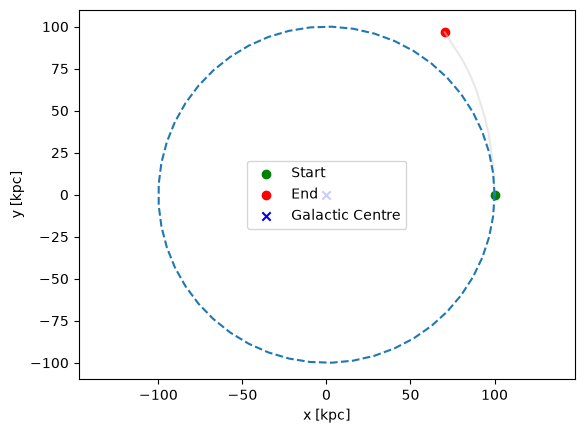

In [138]:
r = galacto_centre
x = r[:, 0]
y = r[:, 1]
r0 = 200
phi = np.linspace(0, 2* np.pi)
xc = 100 * np.cos(phi)
yc = 100 * np.sin(phi)

plt.plot(x, y, c = "lightgrey", alpha = 0.5)
plt.plot(xc, yc, ls = "dashed")
plt.scatter(x[0], y[0], marker = "o", c = "green", label = "Start")
plt.scatter(x[-1], y[-1], marker = "o", c = "red", label = "End")
plt.scatter(0,0, marker = "x", c = "blue", label = "Galactic Centre")
plt.legend()
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.axis("equal")

In [129]:
g_theory = g_mond_host(100, 9.15e10) #(km/s)^2/kpc
print(g_theory) 
conv = 3.24078e-14 #km/s^2
print(g_theory * conv)
vc = np.sqrt(g_theory * 100)
print(vc)

401.9769118679998
1.3027187364435765e-11
200.49361881815585


In [134]:
file = "/Users/olgahinke/Desktop/simus/test_analytic_mw/50kpc/e=0.1/"
os.chdir(file)
output = Pympor.chargement_grav(2, 1)
x, y, z = output[:,0], output[:,1], output[:,2]
accx, accy, accz = output[:,5], output[:,6], output[:,7]
grid_pos = np.column_stack([x, y, z])
r0 = np.array([-100.0, 0.0, 0.0])
dist = np.linalg.norm(grid_pos - r0, axis=1)
i = np.argmin(dist)

g_sim = np.array([accx[i], accy[i], accz[i]])

print("Requested position:", r0)
print("Nearest cell:", grid_pos[i])
print("Distance:", dist[i])
print("g_sim:", g_sim)
print("|g_sim|:", np.linalg.norm(g_sim), "m/s^2")

g_kms_kpc = np.linalg.norm(g_sim) /1e6 * 3.08e19 
print(g_kms_kpc)
print(np.sqrt(g_kms_kpc * 100))

Requested position: [-100.    0.    0.]
Nearest cell: [-105.46875   11.71875   11.71875]
Distance: 17.45180304975678
g_sim: [ 6.12036247e-12 -7.60842809e-13 -7.61017468e-13]
|g_sim|: 6.21424702699143e-12 m/s^2
191.39880843133602
138.34695819978697


In [14]:
d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/new_res_0.8/"
n_iter = get_max_file_number(d)
x0, vx, y0 = 200, 0, 0
vy = "0.8vc"
t, all_pos, all_vel, all_mass, pos_sat_movie, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = False, movie=True)


/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:846: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1055: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [1.99955573e+02 5.20526552e-02 2.48703761e-02], bound mass: 1.001e+07


TypeError: host_potential() got an unexpected keyword argument 'n'

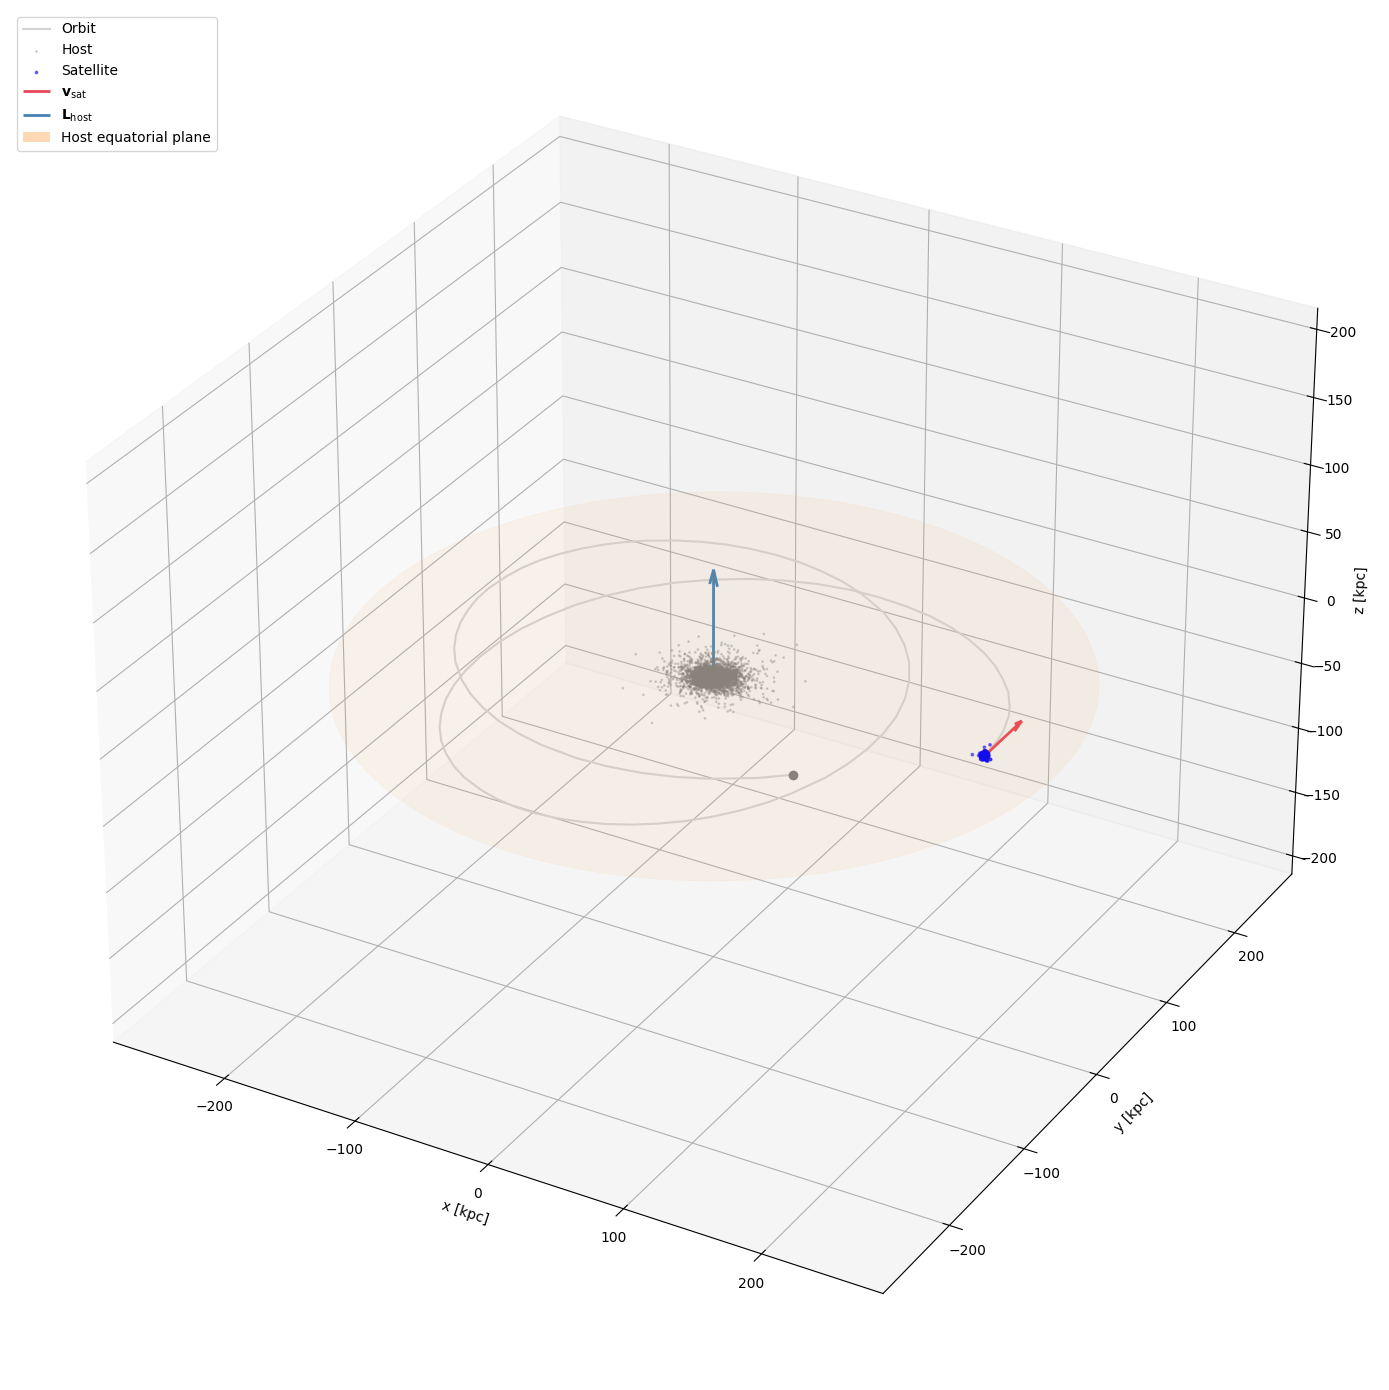

In [ ]:
f = "/Users/olgahinke/Desktop/simus/dice_mw/d_200/new_res_0.8/output_00001"  # use snapshot 1 for ICs
s = pn.load(f)
pn.analysis.halo.center(s.dm)
r = np.array(coms_sat)

pos  = np.array(s.dm["pos"],              dtype=float)
vel  = np.array(s.dm["vel"].in_units('km s^-1'), dtype=float)
mass = np.array(s.dm["mass"],             dtype=float)

pos_host = pos[:15000];   vel_host = vel[:15000];   mass_host = mass[:15000]
pos_sat  = pos[15000:];   vel_sat  = vel[15000:];   mass_sat  = mass[15000:]

com_host     = np.average(pos_host, weights=mass_host, axis=0)
com_vel_host = np.average(vel_host, weights=mass_host, axis=0)
com_sat      = np.average(pos_sat,  weights=mass_sat,  axis=0)
com_vel_sat  = np.average(vel_sat,  weights=mass_sat,  axis=0)

# Angular momentum of host (indicates rotation axis)
r_host  = pos_host - com_host
L_host  = np.sum(mass_host[:, None] * np.cross(r_host, vel_host), axis=0)
L_hat   = L_host / np.linalg.norm(L_host)   # unit vector along rotation axis

L_orb     = np.cross(com_sat, com_vel_sat)
L_orb_hat = L_orb / np.linalg.norm(L_orb)  # normal to orbital plane
perp_orb1 = np.cross(L_orb_hat, [0, 0, 1])
if np.linalg.norm(perp_orb1) < 1e-6:
    perp_orb1 = np.cross(L_orb_hat, [0, 1, 0])
perp_orb1 /= np.linalg.norm(perp_orb1)
perp_orb2  = np.cross(L_orb_hat, perp_orb1)

fig = plt.figure(figsize=(18,14))
ax  = fig.add_subplot(projection='3d')

# orbit
ax.plot(r[:,0], r[:,1], r[:,2], c = "lightgrey", label="Orbit")

ax.scatter(pos_host[:, 0], pos_host[:, 1], pos_host[:, 2],
           c='grey', s=1, alpha=0.3, label='Host')

# Satellite particles
ax.scatter(pos_sat[:, 0], pos_sat[:, 1], pos_sat[:, 2],
           c='blue', s=3, alpha=0.5, label='Satellite')
ax.plot(r[-1,0], r[-1,1], r[-1,2], marker="o", c = "grey")

# Satellite COM velocity arrow (shows initial orbit direction)
scale_v = 50  # kpc per (km/s), adjust for visibility
ax.quiver(*com_sat,
          *(com_vel_sat / np.linalg.norm(com_vel_sat) * scale_v),
          color='#E84855', linewidth=2, arrow_length_ratio=0.2,
          label=r'$\mathbf{v_\mathrm{sat}}$')

# Host rotation axis (angular momentum direction)
scale_L = 80  # kpc, adjust for visibility
ax.quiver(*com_host,
          *(L_hat * scale_L),
          color='steelblue', linewidth=2, arrow_length_ratio=0.15,
          label=r'$\mathbf{{L}_\mathrm{host}}$')

theta   = np.linspace(0, 2 * np.pi, 100)
# build two vectors perpendicular to L_hat
perp1   = np.cross(L_hat, [0, 0, 1])
if np.linalg.norm(perp1) < 1e-6:
    perp1 = np.cross(L_hat, [0, 1, 0])
perp1  /= np.linalg.norm(perp1)
perp2   = np.cross(L_hat, perp1)
R_ring  = 200  # kpc, radius of the ring — set to ~host extent
ring    = (com_host[:, None]
           + R_ring * (np.outer(perp1, np.cos(theta))
                     + np.outer(perp2, np.sin(theta))))
#ax.plot(ring[0], ring[1], ring[2],
        #color='steelblue', alpha=0.4, lw=1, ls='--', label='Orbital Plane')


from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches
# Filled circular orbital plane
R_plane = 250  # kpc, adjust to your simulation extent
theta   = np.linspace(0, 2 * np.pi, 200)
circle  = (com_host[:, None]
           + R_plane * (np.outer(perp_orb1, np.cos(theta))
                      + np.outer(perp_orb2, np.sin(theta))))

# Stack into (N, 3) array of vertices for the polygon
verts = [list(zip(circle[0], circle[1], circle[2]))]
poly  = Poly3DCollection(verts, alpha=0.08, facecolor='#F9A03F', edgecolor='#F9A03F', linewidth=0.5)
ax.add_collection3d(poly)
orbital_patch = mpatches.Patch(facecolor='#F9A03F', alpha=0.4, 
                                label='Host equatorial plane')

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')

handles, labels = ax.get_legend_handles_labels()
handles.append(orbital_patch)
ax.legend(handles=handles, loc='upper left')
ax.axis("equal")
plt.tight_layout()
plt.savefig("initial_conditions.pdf", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

In [ ]:
d = f"//Users/olgahinke/Desktop/simus/dice_mw/d_200/new_0.3/"
n_iter = get_max_file_number(d)
x0, vx, y0 = 200, 0, 0
vy = "0.3vc"
t, all_pos, all_vel, all_mass, pos_sat_movie, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = False, movie=False)


/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=40997  M=8.204e+06 Msun
Mass ratio: 0.9999268292682927
i=1, com_sat: [2.00034925e+02 4.38839487e-02 1.40160835e-02], bound mass: 8.204e+06
  [efe=False] iter  1: N=40997  M=8.204e+06 Msun
Mass ratio: 0.9999268292682927
i=2, com_sat: [ 1.97203499e+02  8.48589133e+00 -1.79034355e-01], bound mass: 8.204e+06
  [efe=False] iter  1: N=40997  M=8.204e+06 Msun
Mass ratio: 0.9999268292682927
i=3, com_sat: [195.14904474  13.75627965  -0.38418947], bound mass: 8.204e+06
  [efe=False] iter  1: N=40994  M=8.204e+06 Msun
Mass ratio: 0.9998536585365855
i=4, com_sat: [188.60960101  21.96981065  -0.71786545], bound mass: 8.204e+06
  [efe=False] iter  1: N=40993  M=8.204e+06 Msun
Mass ratio: 0.999829268292683
i=5, com_sat: [182.35903385  27.95764836  -0.91974462], bound mass: 8.204e+06
  [efe=False] iter  1: N=40992  M=8.203e+06 Msun
Mass ratio: 0.9998048780487805
i=6, com_sat: [170.80183912  34.48606315  -1.29519177], bound mass: 8.203e+06
  [efe=False] iter  1: N=40990  M=8.20

Found minima at times: [1273.2882301  4210.10865835 7072.44260287]
Values at minima: [74.79577152 72.96896338 76.95031281]
Found maxima at times: [ 161.37892196 2814.24173701 5622.79422694 8590.10171617]
Values at maxima: [207.81135194 206.19509479 220.4764018  213.71986725]
[array([[-0.0844615 , -0.01654473, -0.36436556],
       [ 0.2091785 , -0.04613073,  0.13452344],
       [ 0.2408525 ,  0.15458927, -0.48987956],
       ...,
       [-0.0745145 ,  0.04356527,  0.13096444],
       [ 0.0811585 ,  0.22677127,  0.06641644],
       [-0.1218865 , -0.26345373, -0.47271056]], shape=(40997, 3)), array([[-0.25828462, -0.39272358,  0.46173975],
       [ 0.15791058,  0.2257456 ,  0.088987  ],
       [ 0.09489278, -0.17062119, -0.19918381],
       ...,
       [ 0.00576352, -0.10795146, -0.00888936],
       [ 0.13968293, -0.02327663,  0.21482215],
       [-0.09808104, -0.12019411, -0.26444409]], shape=(40997, 3)), array([[ 0.30598831,  0.44293563, -0.29435441],
       [ 0.02411354, -0.16231853,  

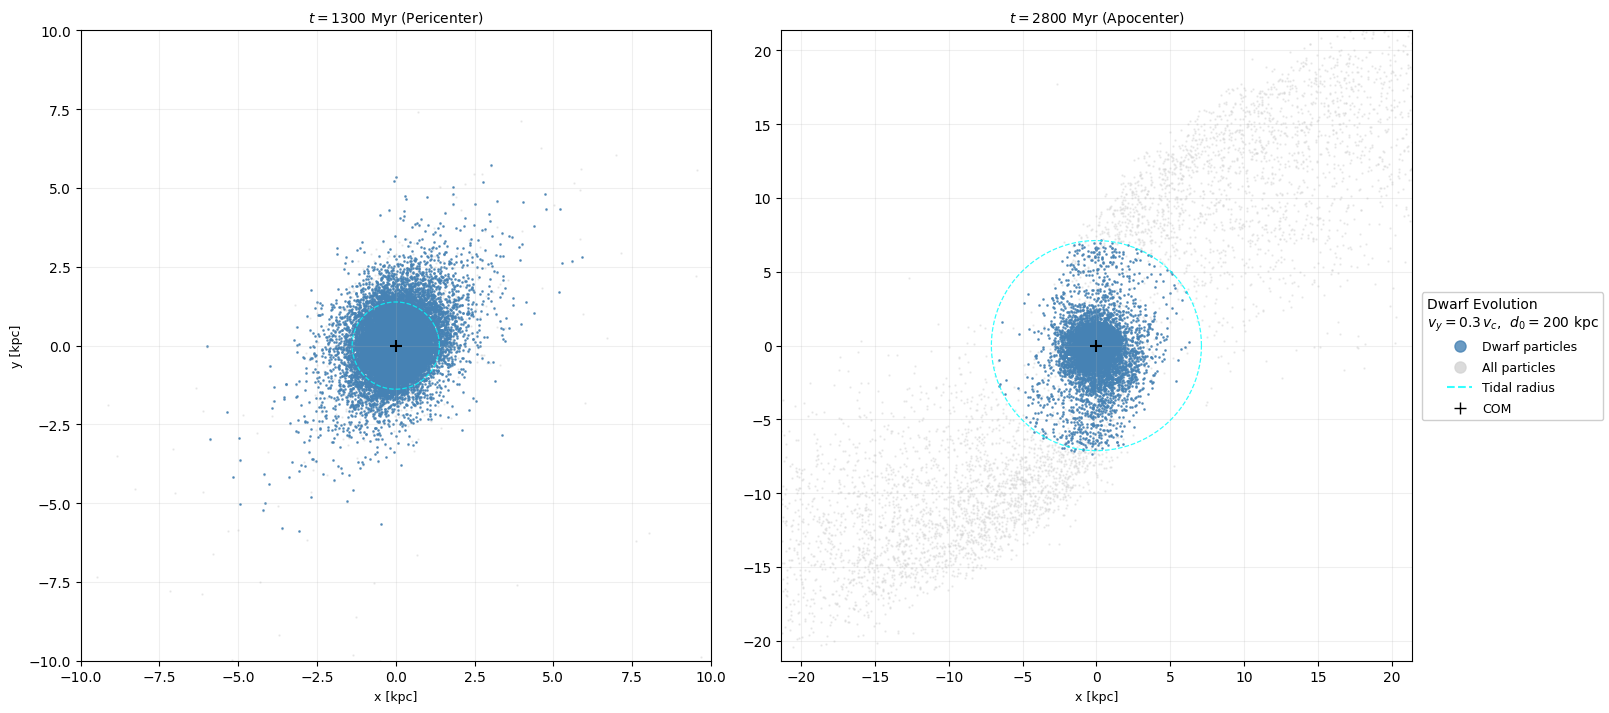

In [ ]:

t_min, r_min, tmax, rmax, e = get_perigalacticon(t, rs)
peri_indices = [np.argmin(np.abs(t - t_min[0]))]
apo_indices  = [np.argmin(np.abs(t - tmax[1]))]

# Map index → label BEFORE sorting
label_map = {0: "IC"}
for idx in apo_indices:
    label_map[idx] = "Apocenter"
for idx in peri_indices:
    label_map[idx] = "Pericenter"

ts = sorted(apo_indices + peri_indices)

fig, axes = plt.subplots(1, len(ts), figsize=(16,12),
                          sharex=False, sharey=False, constrained_layout=True)

all_pos_centered = []
pos_sat_centered = []

for i in range(len(all_pos)):
    if i < len(coms_sat) and coms_sat[i] is not None:
        com = np.array(coms_sat[i], dtype=float)
    else:
        com = np.zeros(3)

    all_pos_centered.append(np.array(all_pos[i], dtype=float) - com)

    if i < len(pos_sat) and len(pos_sat_movie[i]) > 0:
        pos_sat_centered.append(np.array(pos_sat_movie[i], dtype=float) - com)
    else:
        pos_sat_centered.append(np.empty((0, 3)))

print(pos_sat_centered)
for ax, i in zip(axes, ts):
    ptype = label_map.get(i, "")

    # Host particles
    ax.scatter(all_pos_centered[i][:, 0], all_pos_centered[i][:, 1],
               s=0.5, c='lightgrey', alpha=0.4, rasterized=True)

    # Satellite particles
    sat = pos_sat_centered[i]
    if len(sat) > 0:
        ax.scatter(sat[:, 0], sat[:, 1],
                   s=0.8, c='steelblue', alpha=0.8, rasterized=True)

    # COM marker
    if i < len(coms_sat) and coms_sat[i] is not None:
        ax.scatter(0, 0, s=80, marker='+', c='k', lw=1.5, zorder=10)

    # Tidal radius circle centred at origin
    if i < len(tidals) and tidals[i] is not None and np.isfinite(tidals[i]):
        theta = np.linspace(0, 2*np.pi, 100)
        r_t   = tidals[i]
        ax.plot(r_t*np.cos(theta), r_t*np.sin(theta),
                c='cyan', lw=0.9, ls='--', alpha=0.8)

    # Zoom centred on origin
    if i < len(tidals) and tidals[i] is not None and np.isfinite(tidals[i]):
        zoom = max(tidals[i] * 3, 10)
        ax.set_xlim(-zoom, zoom)
        ax.set_ylim(-zoom, zoom)

    # Title: time + peri/apo label, colored by type
    t_val = t[i] if i < len(t) else i * 100
    label_str = f" ({ptype})" if ptype else ""
    ax.set_title(f"$t = {t_val:.0f}$ Myr{label_str}",
                 fontsize=10)

    ax.set_xlabel("x [kpc]", fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("y [kpc]", fontsize=9)

legend_elements = [
    Line2D([0], [0], color='steelblue', alpha=0.8, marker = "o", ms = 8, lw=0,  label='Dwarf particles'),
    Line2D([0], [0], color='lightgrey', alpha=0.8, marker = "o", ms = 8, lw=0, label='All particles'),
    Line2D([0], [0], color='cyan',      alpha=0.8, lw=1.5,
           ls='--', label='Tidal radius'),
    Line2D([0], [0], marker='+', color='k', lw=0, ms=8,  label='COM'),
]
leg = fig.legend(
    handles        = legend_elements,
    loc            = 'outside right center',   # constrained_layout-aware placement
    framealpha     = 0.95,
    fontsize       = 9,
    title        = "Dwarf Evolution \n" + r"$v_y = 0.3\,v_c$,  $d_0 = 200$ kpc",
    title_fontsize = 10,
    labelspacing   = 0.6,
)


#plt.tight_layout(rect=[0, 0, 0.92, 0.98])   # leave space for legend + suptitle
plt.savefig("snapshots_2d.pdf", dpi=500, bbox_inches="tight",
            bbox_extra_artists=[leg])
plt.show()

2.5 * v_c running, 101 output files found, N_host=6000...
  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [2.00025478e+02 7.66560229e-02 2.68584562e-02], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=2, com_sat: [ 1.97108716e+02  6.51963331e+01 -1.83630237e-01], bound mass: 1.001e+07


/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=3, com_sat: [195.52254235  97.96084616  -0.41445869], bound mass: 1.001e+07
  [efe=False] iter  1: N=49995  M=1.001e+07 Msun
Mass ratio: 0.9999
i=4, com_sat: [190.95349185 147.50962508  -0.76580205], bound mass: 1.001e+07
  [efe=False] iter  1: N=49992  M=1.000e+07 Msun
Mass ratio: 0.99984
i=5, com_sat: [184.85205139 196.98055995  -1.13704628], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=6, com_sat: [177.14503106 245.7554031   -1.56956616], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=7, com_sat: [168.65343018 294.21087562  -1.90057155], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=8, com_sat: [159.32851273 341.13090977  -2.21163883], bound mass: 1.000e+07
  [efe=False] iter  1: N=49989  M=1.000e+07 Msun
Mass ratio: 0.99978
i=9, com_sat: [149.28473122 385.29995821  

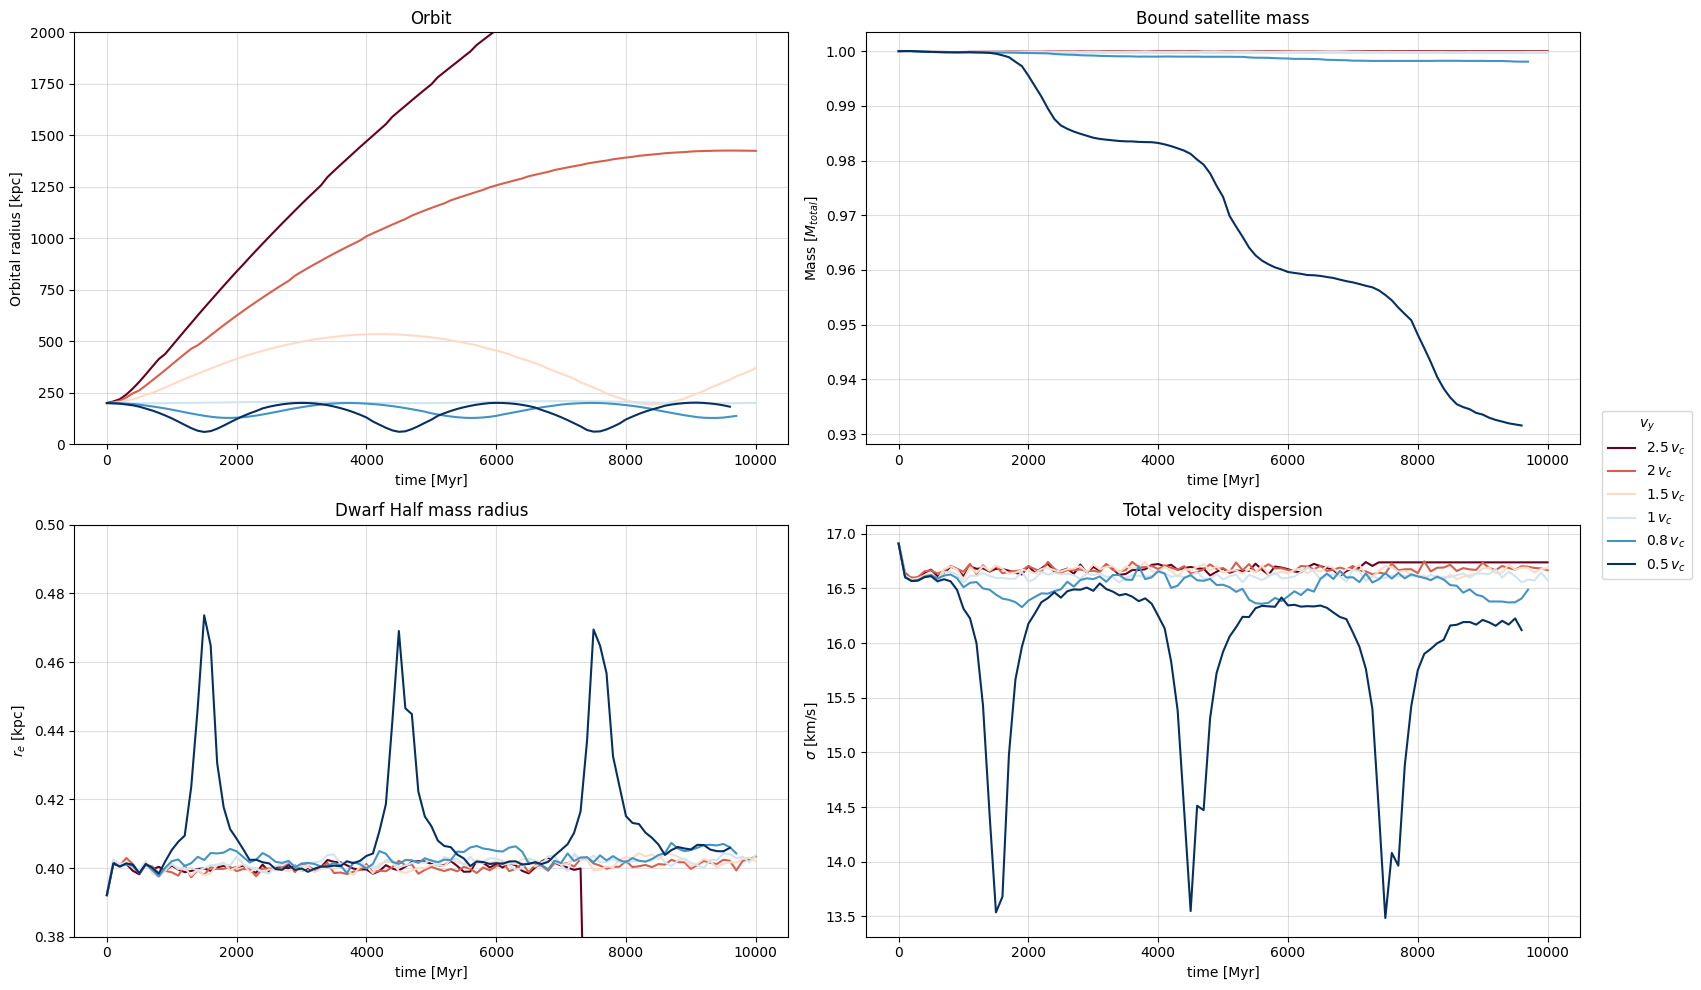

In [ ]:
arrs = ["2.5vc", "2vc", "1.5vc", "vc", "new_res_0.8", "0.5/new_h_res_15e3"]
vs = [2.5, 2, 1.5, 1, 0.8, 0.5]
n_hosts = [6000, 6000, 6000, 6000, 15000, 15000] 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
n      = len(arrs)
cmap   = plt.get_cmap('RdBu', n)
colors = [cmap(i) for i in range(len(arrs))]  

for i, (a, v, n_host, c) in enumerate(zip(arrs, vs, n_hosts, colors)):
    d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/{a}/"
    x0, vx, y0 = 200, 0, 0
    vy = v

    n_iter = get_max_file_number(d)
    print(f"{v} * v_c running, {n_iter} output files found, N_host={n_host}...")
    
    t, all_pos, all_vel, all_mass, pos_sat, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=n_host, grid_length=600, efe = False, movie=False)
    
    #masses_host, masses_sat,
        #rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, tidals, jacobs, anisotropy

    t_min, r_min, tmax, rmax, e = get_perigalacticon(t, rs)
    #if t_min is None or len(t_min) == 0:
        #print("No lines plotted")
    #else:
        #for t_v in t_min:
            #axes[0].axvline(t_v, color="lightgrey", ls="dashed")

    masses_arr = np.array(masses_sat, dtype=float)
    t_arr = np.array(t, dtype=float)

    axes[0].plot(t_arr, rs, label=rf"${v}\,v_c$", color=c)
    axes[0].set_ylabel("Orbital radius [kpc]")
    axes[0].set_xlabel("time [Myr]")
    axes[0].set_title("Orbit")
    axes[0].set_ylim(0,2000)
    axes[0].grid(True, alpha=0.4)

    axes[1].plot(t_arr, np.array(masses_sat)/masses_sat[0], label=rf"${v}\,v_c$", color=c)
    axes[1].set_xlabel("time [Myr]")
    axes[1].set_ylabel(r"Mass [$M_{total}$]")
    axes[1].set_title("Bound satellite mass")
    axes[1].grid(True, alpha=0.4)

    axes[2].plot(t_arr, hmr_sat, label=rf"${v}\,v_c$", color=c)
    axes[2].set_xlabel("time [Myr]")
    axes[2].set_ylabel(r"$r_e$ [kpc]")
    axes[2].set_title("Dwarf Half mass radius")
    axes[2].set_ylim(0.38, 0.5)
    axes[2].grid(True, alpha=0.4)

    axes[3].plot(t_arr, sigmas, label=rf"${v}\,v_c$", color=c)
    axes[3].set_xlabel("time [Myr]")
    axes[3].set_ylabel(r"$\sigma$ [km/s]")
    axes[3].set_title("Total velocity dispersion")
    axes[3].grid(True, alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, title=r"$v_y$", loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig("all.pdf", dpi=300, bbox_inches="tight", bbox_extra_artists=[leg])
plt.show()

In [ ]:
def plotting_pm(filename, dt, t_end, N_host, cutoff_host, grid_length,
                efe=False, movie=False):

    coms_host  = []
    coms_sat   = []
    coms_vel   = []
    masses_host = []
    all_pos    = []
    all_vel    = []
    all_mass   = []
    e_orb      = []
    l_orb      = []
    lz         = []
    t_array    = []

    # pre-build potential cache with a representative mass (avoids
    # recomputing the grid every snapshot due to tiny mass fluctuations)
    _potential_mass = None

    t = 0
    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)

        # ── load in original box-corner frame (before any centering) ──────────
        pos_raw  = np.array(s.dm["pos"],                     dtype=float)  # kpc
        mass_raw = np.array(s.dm["mass"],                    dtype=float)  # Msun
        vel_raw  = np.array(s.dm["vel"].in_units("km s^-1"), dtype=float)  # km/s

        # ── angular momentum in box-corner frame (must use raw pos/vel) ───────
        L_raw = np.sum(mass_raw[:, None] * np.cross(pos_raw, vel_raw), axis=0)
        x_com = np.average(pos_raw, weights=mass_raw, axis=0)
        v_com = np.average(vel_raw, weights=mass_raw, axis=0)
        M_tot = np.sum(mass_raw)
        L_com = M_tot * np.cross(x_com, v_com)
        L_int = L_raw - L_com
        l_orb.append(L_int)
        lz.append(L_int[2])

        # ── host COM in box-corner frame — BEFORE centering ───────────────────
        com_host = np.array(
            pn.analysis.halo.shrink_sphere_center(
                s.dm[1:], r=cutoff_host, shrink_factor=0.7, min_particles=100
            ), dtype=float
        ).flatten()[:3]
        coms_host.append(com_host)

        # ── now center so satellite position is relative to host COM ──────────
        pn.analysis.halo.center(s.dm[1:])

        pos_centered  = np.array(s.dm["pos"],                     dtype=float)
        vel_centered  = np.array(s.dm["vel"].in_units("km s^-1"), dtype=float)
        mass_centered = np.array(s.dm["mass"],                    dtype=float)

        all_pos.append(pos_centered)
        all_vel.append(vel_centered)
        all_mass.append(mass_centered)

        # ── host bound mass ───────────────────────────────────────────────────
        close_host  = mask_bound(s.dm, np.zeros(3), r_cut=cutoff_host)  # origin = host COM now
        mass_host   = mass_centered[1:][close_host[1:]]
        M_host      = float(np.sum(mass_host))
        masses_host.append(M_host)

        # ── satellite (particle 0) in host-centered frame ─────────────────────
        pos_pm  = pos_centered[0]    # kpc, relative to host COM   ✓
        vel_pm  = vel_centered[0]    # km/s, relative to host COM  ✓
        coms_sat.append(pos_pm.copy())
        coms_vel.append(vel_pm.copy())

        # ── orbital energy — use fixed representative mass for cache ──────────
        if _potential_mass is None:
            _potential_mass = M_host   # set once on first snapshot

        phi_sat = host_potential(
            pos_pm.reshape(1, 3), _potential_mass, n=2000
        )
        KE      = 0.5 * np.dot(vel_pm, vel_pm)     # ← scalar, was 3-vector bug
        E_orb   = KE + phi_sat[0]                  # (km/s)^2
        e_orb.append(E_orb)

        t_array.append(t)
        t += dt

    return (t_array, all_pos, all_vel, all_mass,
            coms_host, masses_host, coms_sat, coms_vel,
            e_orb, l_orb, lz)

In [ ]:
d = "/Users/olgahinke/Desktop/simus/test_pointmass/"
t_array, all_pos, all_vel, all_mass, coms_host, masses_host, coms_sat, coms_vel, e_orb, l_orb, lz = plotting_pm(d, 100, 101, N_host=1000000, cutoff_host = 60, grid_length=600, efe = False)

  snap 0001 | t=100.00 Gyr | R_sat=200.0 kpc | E_orb=-3.069e+05 (km/s)^2 | Lz/Lz0=N/A
  snap 0002 | t=200.00 Gyr | R_sat=199.9 kpc | E_orb=-3.077e+05 (km/s)^2 | Lz/Lz0=1.0000
  snap 0003 | t=300.00 Gyr | R_sat=199.7 kpc | E_orb=-3.084e+05 (km/s)^2 | Lz/Lz0=1.0000
  snap 0004 | t=400.00 Gyr | R_sat=199.3 kpc | E_orb=-3.078e+05 (km/s)^2 | Lz/Lz0=1.0000
  snap 0005 | t=500.00 Gyr | R_sat=198.8 kpc | E_orb=-3.085e+05 (km/s)^2 | Lz/Lz0=0.9999
  snap 0006 | t=600.00 Gyr | R_sat=198.1 kpc | E_orb=-3.084e+05 (km/s)^2 | Lz/Lz0=0.9987
  snap 0007 | t=700.00 Gyr | R_sat=197.7 kpc | E_orb=-3.071e+05 (km/s)^2 | Lz/Lz0=0.9984
  snap 0008 | t=800.00 Gyr | R_sat=196.7 kpc | E_orb=-3.113e+05 (km/s)^2 | Lz/Lz0=0.9975
  snap 0009 | t=900.00 Gyr | R_sat=196.1 kpc | E_orb=-3.042e+05 (km/s)^2 | Lz/Lz0=0.9967
  snap 0010 | t=1000.00 Gyr | R_sat=195.0 kpc | E_orb=-3.085e+05 (km/s)^2 | Lz/Lz0=0.9967
  snap 0011 | t=1100.00 Gyr | R_sat=193.5 kpc | E_orb=-3.080e+05 (km/s)^2 | Lz/Lz0=0.9967
  snap 0012 | t=1200.0

v_c(8 kpc) MOND     = 241.4 km/s
v_c(8 kpc) Newtonian= 196.5 km/s
Enclosed baryonic mass at 200 kpc = 9.15e+10 Msun (should be 9.15e10)


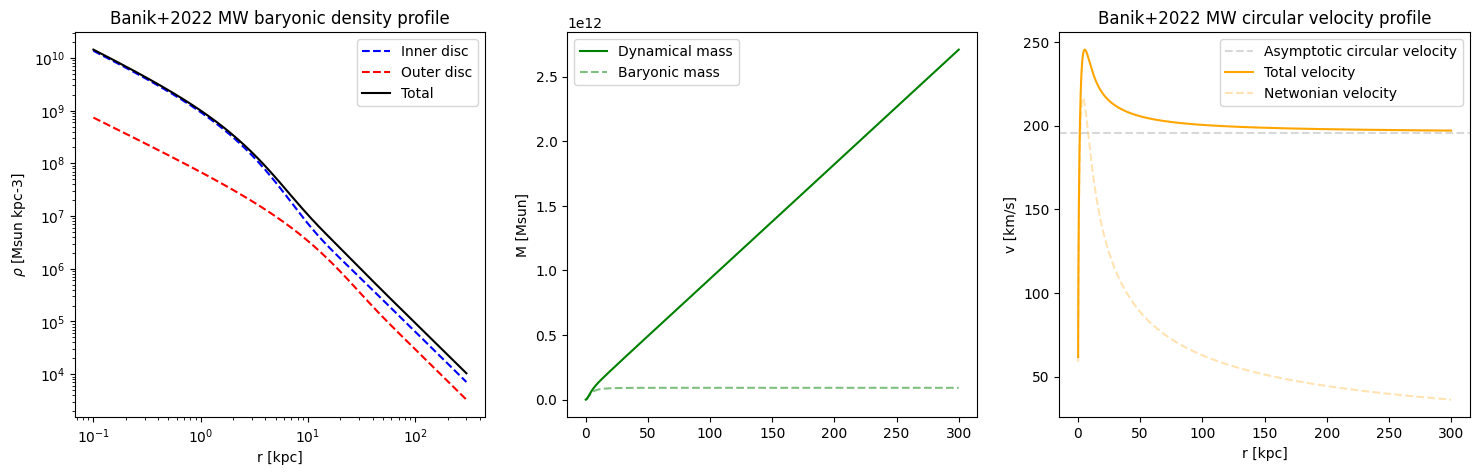

In [ ]:
G         = 4.30091e-3   
a0        = 3.703      
G_kpc     = G * 1e-3   
a0_kpc    = a0 * 1e3   

def nu_mond(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r, rd)
    return 0.5 + np.sqrt(0.25 + 1.0/y)

def f(r, rd):
    return 1 - np.exp(-r/rd)*(1 + r/rd)

def df_dr(r, rd):
    return r/(rd**2)* np.exp(-r/rd)

def alpha(M_tot, r):
    return G_kpc*M_tot/(a0_kpc * r**2)

def dnu_dy(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r,rd)
    return -1/(2*y**2*np.sqrt(1/4 + 1/y))

def dnu_dr(M_tot, r, rd):
    dndy = dnu_dy(M_tot, r, rd)
    a = alpha(M_tot, r)
    dfdr = df_dr(r, rd)
    return dndy * a * (dfdr - 2*f(r, rd)/r)

def dMc_dr(M_tot, r, rd):
    dfdr = df_dr(r, rd)
    return M_tot*(f(r, rd) * dnu_dr(M_tot, r, rd) + nu_mond(M_tot, r, rd) * dfdr)

def rho_ana(M_tot, r, rd):
    dM_dr = dMc_dr(M_tot, r, rd)
    return 1/(4*np.pi*r**2)* dM_dr

M_MW       = 9.15e10             # Msun — total baryonic mass
f_inner    = 0.8236              # fraction in inner component
f_outer    = 0.1764              # fraction in outer component
Rd_inner   = 1.29/0.6                # kpc AT Z=0!!!!
Rd_outer   = 4.20/0.6                # kpc AT Z=10!!!!

M_inner    = f_inner * M_MW      # 7.54e10 Msun
M_outer    = f_outer * M_MW      # 1.61e10 Msun

r_grid = np.geomspace(0.1, 300, 1000)

def nu(y):
    return 0.5 + np.sqrt(0.25 + 1.0 / np.maximum(y, 1e-30))

M_b_inner = M_inner * f(r_grid, Rd_inner)
M_b_outer = M_outer * f(r_grid, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r_grid**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
vc        = np.sqrt(G_kpc * M_c / r_grid)
vc_newt   = np.sqrt(G_kpc * M_b_total / r_grid)
print(f"v_c(8 kpc) MOND     = {np.interp(8, r_grid, vc):.1f} km/s")
print(f"v_c(8 kpc) Newtonian= {np.interp(8, r_grid, vc_newt):.1f} km/s")
print(f"Enclosed baryonic mass at 200 kpc = {np.interp(200, r_grid, M_b_total):.2e} Msun (should be 9.15e10)")
rho_ana_1 = rho_ana(M_inner, r_grid, Rd_inner)
rho_ana_2 = rho_ana(M_outer, r_grid, Rd_outer)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
v_inf_theo = (G_kpc * M_MW * a0_kpc)**0.25

axes[0].loglog(r_grid, rho_ana_1, label="Inner disc", color="blue", ls = "dashed")
axes[0].loglog(r_grid, rho_ana_2, label="Outer disc", color="red", ls ="dashed")
axes[0].loglog(r_grid, rho_ana_1 + rho_ana_2, label="Total", color="black")
axes[0].set_xlabel("r [kpc]")
axes[0].set_ylabel(r"$\rho$ [Msun kpc-3]")
axes[0].set_title("Banik+2022 MW baryonic density profile") 
axes[0].legend()
axes[1].plot(r_grid, M_c, label="Dynamical mass", color="green")
axes[1].plot(r_grid, M_b_total, label="Baryonic mass", color="green",alpha=0.5, ls = "dashed")
axes[1].set_ylabel("M [Msun]")
axes[1].legend()
axes[2].axhline(v_inf, ls = "dashed", c = "grey", alpha = 0.3, label="Asymptotic circular velocity")
axes[2].plot(r_grid, vc, label="Total velocity", color="orange")
axes[2].plot(r_grid, vc_newt, label="Netwonian velocity",  color="orange",alpha = 0.3, ls = "dashed")
axes[2].set_xlabel("r [kpc]")
axes[2].set_ylabel("v [km/s]")
axes[2].set_title("Banik+2022 MW circular velocity profile")
axes[2].legend()

In [ ]:
import sympy as sp

# define symbolic variable
x = sp.symbols('t')
a = sp.symbols('a')
eq = (1 - sp.exp(-(x/a))*(1 + (x/a))) / x
deriv = eq.diff(x)
print(f"Derivative of gN(t) = {deriv}")

Derivative of gN(t) = ((1 + t/a)*exp(-t/a)/a - exp(-t/a)/a)/t - (-(1 + t/a)*exp(-t/a) + 1)/t**2


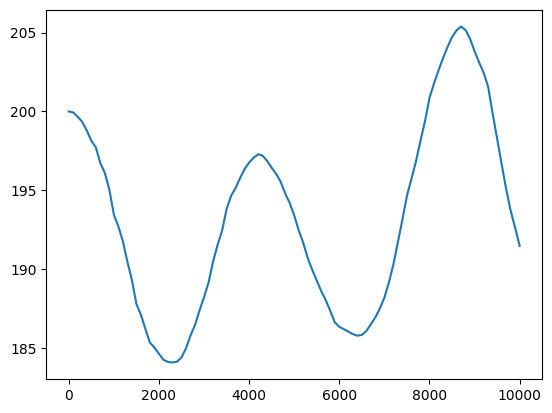

In [ ]:
plt.plot(t_array, np.linalg.norm(coms_sat, axis=1), label="Satellite COM")

Linear fit coefficients: [-1.05838353e+08  1.25146216e+14]
1.0619475816962654 % change in 10 Gyr over simulation


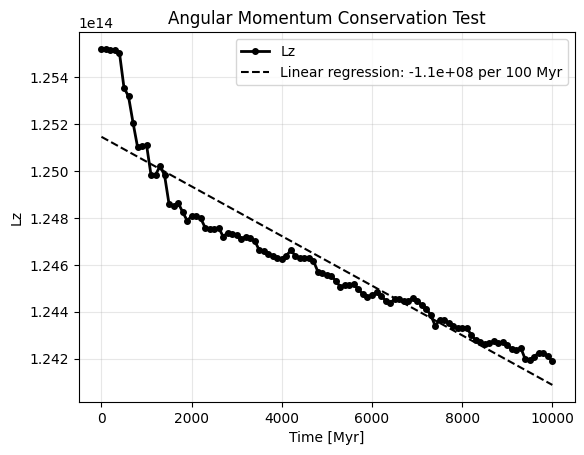

In [ ]:
#plt.plot(t_array, lz/lz[0], 'o', label='Lz/Lz0')
coef = np.polyfit(t_array, lz, 1)
print("Linear fit coefficients:", coef)
poly1d_fn = np.poly1d(coef) 
plt.plot(t_array, lz, marker = 'o', c = "black", ms = 4, lw = 2, label="Lz") #'--k'=black dashed line
plt.plot(t_array, poly1d_fn(t_array), '--k', label="Linear regression: {:.1e}".format(coef[0]) + " per 100 Myr") #'--k'=black dashed line, 'yo' = yellow circle marker
plt.xlabel("Time [Myr]")
plt.ylabel("Lz")
plt.title("Angular Momentum Conservation Test")
plt.legend()
plt.grid(True, alpha=0.3)
print( (1 - lz[-1]/lz[0]) * 100, "% change in 10 Gyr over simulation")

Found minima at times: [1467.36118878 4543.8919526  7740.31160439]
Values at minima: [85.26267456 88.65458379 84.54807018]
Found maxima at times: [ 180.30842437 3031.5239466  6150.99776645 9168.39456867]
Values at maxima: [204.32709557 210.36063071 200.66317232 212.64413874]


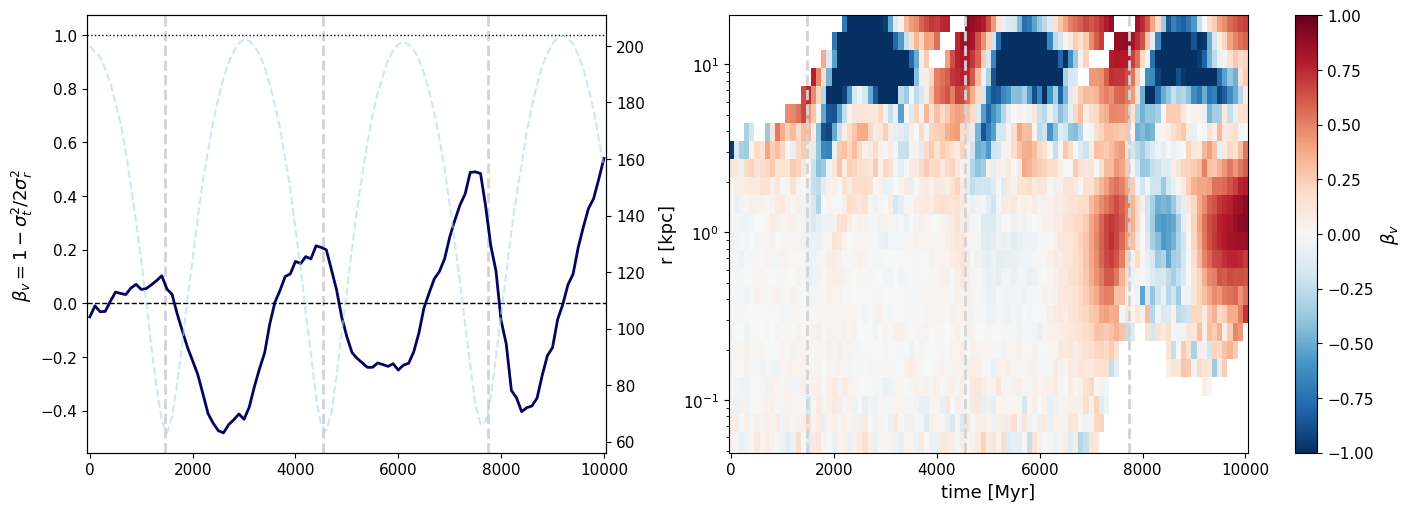

In [ ]:
anisotropy = anisotropy_r
t_arr = t_r

t_min, r_min, tmax, rmax, e = get_perigalacticon(t_r, rs_r)
beta_vel_global = np.array([a["global"] for a in anisotropy])

# 3. Full 2D array: beta as function of (time, radius) — good for a 2D heatmap
beta_2d = np.array([a["profile"] for a in anisotropy])  # shape (n_snapshots, n_bins)
r_centers  = anisotropy[0]["r_centers"]   
fig2, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, layout='constrained')
for t_v in t_min:
    axes[0].axvline(t_v, color="lightgrey", ls="dashed")
    axes[1].axvline(t_v, color="lightgrey", ls="dashed")

# Plot 1: global beta vs time (for the talk summary plot)
ax2r = axes[0].twinx()
axes[0].plot(t_arr, beta_vel_global[:len(t_arr)], color=c, lw=2, label=rf"${v}\,v_c$")
ax2r.plot(t_arr, rs_r, ls = "dashed", color="lightblue", lw=1.5, alpha=0.6)
axes[0].axhline(0, color='k', ls='--', lw=1)   # isotropic
axes[0].axhline(1, color='k', ls=':',  lw=1)   # purely radial
axes[0].set_ylabel(r"$\beta_v = 1 - \sigma_t^2 / 2\sigma_r^2$")

n         = min(len(t_arr), beta_2d.shape[0])
t_plot    = t_arr[:n]
beta_plot = beta_2d[:n, :]   # (100, 24)

im = axes[1].pcolormesh(t_plot, r_centers, beta_plot.T,   # t_plot not t_arr
                    cmap='RdBu_r', vmin=-1, vmax=1,)                  # r_centers not r_edges
fig2.colorbar(im, ax=axes[1], label=r"$\beta_v$")
axes[1].set_xlabel("time [Myr]")
axes[1].set_ylabel("r [kpc]")
#axes[1].set_ylim(0,20)
axes[1].set_yscale('log')
plt.savefig("beta_heatmap.pdf", dpi=300, bbox_inches="tight")
#plt.show()

In [ ]:
x0 = 100
vx = 0 
vy = "vc/2"
y0 = 0
d = "/Users/olgahinke/Desktop/simus/test_analytic_mw/test/"
t_r, all_pos_r, all_vel_r, all_mass_r, pos_sat_r, coms_sat_r, com_host_r, rs, sigmas_r, masses_host_r, masses_sat_r, rhos_host_r, rhos_sat_r, bins_host_r, bins_sat_r, hmr_sat_r, lag_sat_r, all_clusters_r, all_remnants_r, alphas_r, betas_r, r_centers_r, tot_sigmas_bin_r, rb_array_r, anisotropy_r, e_orb_r, l_orb_r, tidals_r, disrupt_r = plotting(d, 100, 5,300, x0, y0, vx, vy, N_host=0, grid_length=1000, efe = False)

/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
sigma_theory = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = rs[0],              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = False
)
sigma_theory_efe = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = rs[0],              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = True
)


Found minima at times: [1485.50834594 4457.9057392  7680.10724962]
Values at minima: [84.97370384 89.77056823 89.09068847]
Found maxima at times: [ 164.8488283  2993.67272949 6055.60927296 9129.46047485]
Values at maxima: [205.17844968 204.52633267 193.67589045 222.5405906 ]
Theory reliable range: 0.057 — 13.75 kpc


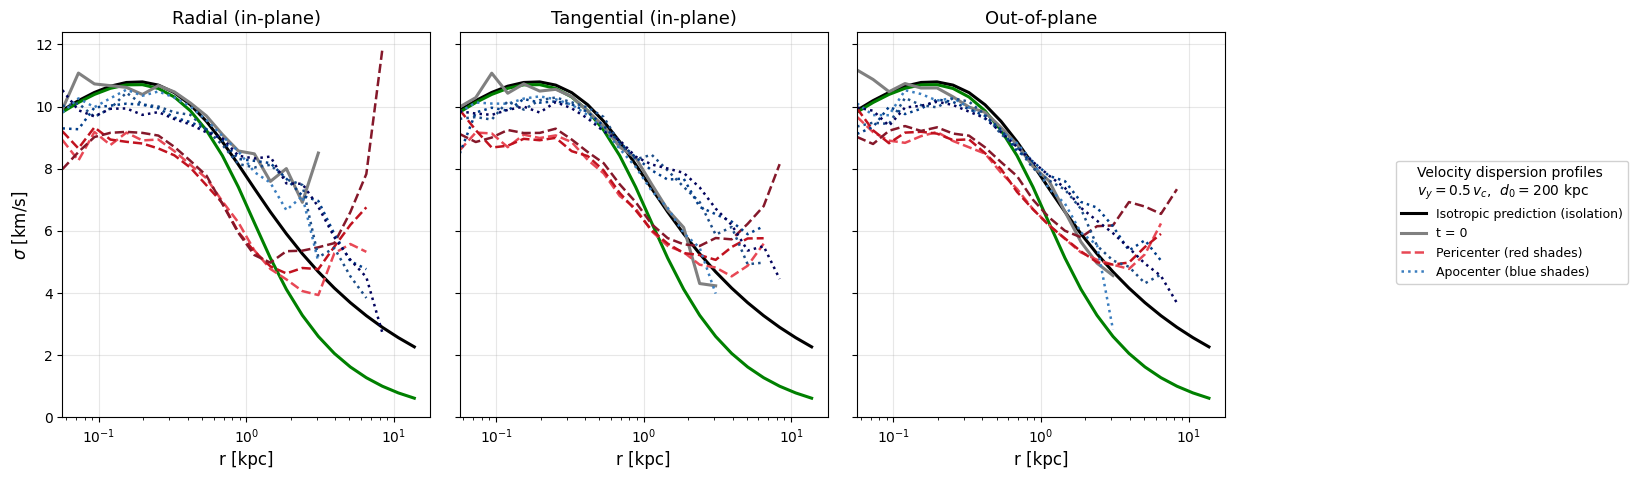

In [ ]:
sigma_th_safe = np.where(sigma_theory > 0.5, sigma_theory, np.nan)
from matplotlib.colors import Normalize, TwoSlopeNorm
import matplotlib.gridspec as gridspec

t_min, r_min, tmax, rmax, e = get_perigalacticon(t_r, rs)
peri_indices = [np.argmin(np.abs(t_r - t_v)) for t_v in t_min]
apo_indices  = [np.argmin(np.abs(t_r - t_v)) for t_v in tmax]
sigma_r  = np.array([a["r"]   for a in tot_sigmas_bin_r])
sigma_t  = np.array([a["t1"]  for a in tot_sigmas_bin_r])
sigma_z  = np.array([a["t2"]  for a in tot_sigmas_bin_r])
betas_2d = np.array([a["beta"] for a in tot_sigmas_bin_r])

sigma_theory_efe = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = np.mean(r_min),              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = True
)

n           = min(len(t_r), sigma_r.shape[0])
t_plot      = t_r[:n]
s_r_plot    = sigma_r[:n, :]
s_t_plot    = sigma_t[:n, :]
s_z_plot    = sigma_z[:n, :]
b_plot      = betas_2d[:n, :]
beta_global = np.nanmean(b_plot, axis=1)

ratio_r = s_r_plot / sigma_th_safe[None, :]
ratio_t = s_t_plot / sigma_th_safe[None, :]
ratio_z = s_z_plot / sigma_th_safe[None, :]

# Find where theory is reliable — drops below 20% of peak value
theory_peak   = np.nanmax(sigma_theory)
theory_valid  = sigma_theory > 0.2 * theory_peak
r_theory_min  = r_centers_r[np.argmax(theory_valid)]        # first valid r
r_theory_max  = r_centers_r[len(theory_valid) - 1 - 
                              np.argmax(theory_valid[::-1])] # last valid r
print(f"Theory reliable range: {r_theory_min:.3f} — {r_theory_max:.2f} kpc")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.subplots_adjust(wspace=0.08)

comp_data   = [s_r_plot, s_t_plot, s_z_plot]
comp_labels = [r"$\sigma_r$ [km/s]",
               r"$\sigma_\phi$ [km/s]",
               r"$\sigma_z$ [km/s]"]
comp_titles = ["Radial (in-plane)", "Tangential (in-plane)", "Out-of-plane"]

snap_dict = {"IC": 0}
for j, idx in enumerate(peri_indices):
    snap_dict[f"Peri {j+1}"] = idx
for j, idx in enumerate(apo_indices):
    snap_dict[f"Apo {j+1}"]  = idx

def snap_style(label, j_peri, j_apo):
    """Return color and linestyle for a given snapshot label."""
    if label == "IC":
        return "grey", "-", 2.2
    elif "Peri" in label:
        # Shades of red, darker for later pericenters
        reds = ["#E84855", "#C1121F", "#85182A", "#6A040F"]
        return reds[j_peri % len(reds)], "--", 1.8
    elif "Apo" in label:
        # Shades of blue, darker for later apocenters
        blues = ["#3A7DBF", "#1D4E89", "#023E8A", "#03045E"]
        return blues[j_apo % len(blues)], ":", 1.8
    return "grey", "-", 1.2

for ax, data, ylabel, title in zip(axes, comp_data, comp_labels, comp_titles):

    # Theory — only plot where it's reliable
    r_mask = theory_valid
    ax.plot(r_centers_r[r_mask], sigma_theory[r_mask], color='black', lw=2.2)
    ax.plot(r_centers_r[r_mask], sigma_theory_efe[r_mask], color='green', lw=2.2)
    j_peri, j_apo = 0, 0
    for label, idx in snap_dict.items():
        if idx >= len(data):
            continue
        profile = data[idx, :]
        valid   = np.isfinite(profile) & (profile > 0)

        c, ls, lw = snap_style(label, j_peri, j_apo)
        if "Peri" in label: j_peri += 1
        if "Apo"  in label: j_apo  += 1

        ax.plot(r_centers_r[valid], profile[valid],
                color=c, ls=ls, lw=lw)

    ax.set_xscale('log')
    ax.set_xlabel("r [kpc]", fontsize=12)
    #ax.set_ylabel(ylabel,    fontsize=12)
    ax.set_title(title,      fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(r_centers_r[0], r_centers_r[-1])
    ax.set_ylim(bottom=0)

axes[0].set_ylabel(r"$\sigma$ [km/s]", fontsize=12)

extra_handles = [
    Line2D([0], [0], color='black',   lw=2.2, ls='-',  label='Isotropic prediction (isolation)'),
    #Line2D([0], [0], color='green',   lw=2.2, ls='-',  label='Isotropic prediction with EFE'),
    Line2D([0], [0], color="grey", lw=2.2, ls='-',  label='t = 0'),
    Line2D([0], [0], color='#E84855', lw=1.8, ls='--', label='Pericenter (red shades)'),
    Line2D([0], [0], color='#3A7DBF', lw=1.8, ls=':',  label='Apocenter (blue shades)')
]
handles, labels_leg = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles        = extra_handles + handles[1:],   # skip duplicate theory entry
    loc            = 'center left',
    bbox_to_anchor = (1.01, 0.5),
    fontsize       = 9,
    framealpha     = 0.9,
    title        = "Velocity dispersion profiles \n" + r"$v_y = 0.5\,v_c$,  $d_0 = 200$ kpc",
    title_fontsize = 10,
    labelspacing   = 0.5,
)

plt.savefig("sigma_profiles.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])
plt.show()

In [ ]:
sigma_theory_efe = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = 60,              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = True
)
sigma_theory = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = 200,              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = False
)


In [ ]:
sigma_theory_200 = get_sigma(
    r       = r_centers_r*1e3,        # kpc, radial bin centers from your dispersion profile
    M       = masses_sat_r[0],      # initial satellite mass
    a_p     = 0.0,                # isotropic Jeans — adjust if you have anisotropy
    n       = 1,           # your Sersic index
    r_e     = 300,         # initial half-mass radius
    profile = "sersic",
    R       = 200,              # initial orbital radius for EFE context
    M_host  = masses_host_r[0],
    mond    = True,
    efe     = True
)

In [ ]:
x0 = 100
vx = 0 
vy = "vc/2"
y0 = 0
d = "/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/new_res_counter/"
t_c, all_pos_c, all_vel_c, all_mass_c, pos_sat_c, coms_sat_c, com_host_c, rs_c, sigmas_c, masses_host_c, masses_sat_c, rhos_host_c, rhos_sat_c, bins_host_c, bins_sat_c, hmr_sat_c, lag_sat_c, all_clusters_c, all_remnants_c, alphas_c, betas_c, r_centers_c, tot_sigmas_bin_c, rb_array_c, anisotropy_c, e_orb_c, l_orb_c, tidals_c, disrupt_c = plotting(d, 100, 97,300, x0, y0, vx, vy, N_host=15000, grid_length=600, efe = False)

OSError: File PosixPath('/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/new_res_counter/output_00001'): format not understood or does not exist

<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w3/j46bj_hn2wsbrfr2354jsn780000gv/T/ipykernel_1596/87948817.py:64: SyntaxWarning: invalid escape sequence '\s'
  ax_dM.set_ylabel("$\sigma$ [km/s]")


Found minima at times: [1485.50834594 4457.9057392  7680.10724962]
Values at minima: [84.97370384 89.77056823 89.09068847]
Found maxima at times: [ 164.8488283  2993.67272949 6055.60927296 9129.46047485]
Values at maxima: [205.17844968 204.52633267 193.67589045 222.5405906 ]
Found minima at times: [1485.50834594 4457.9057392  7680.10724962]
Values at minima: [84.97370384 89.77056823 89.09068847]
Found maxima at times: [ 164.8488283  2993.67272949 6055.60927296 9129.46047485]
Values at maxima: [205.17844968 204.52633267 193.67589045 222.5405906 ]


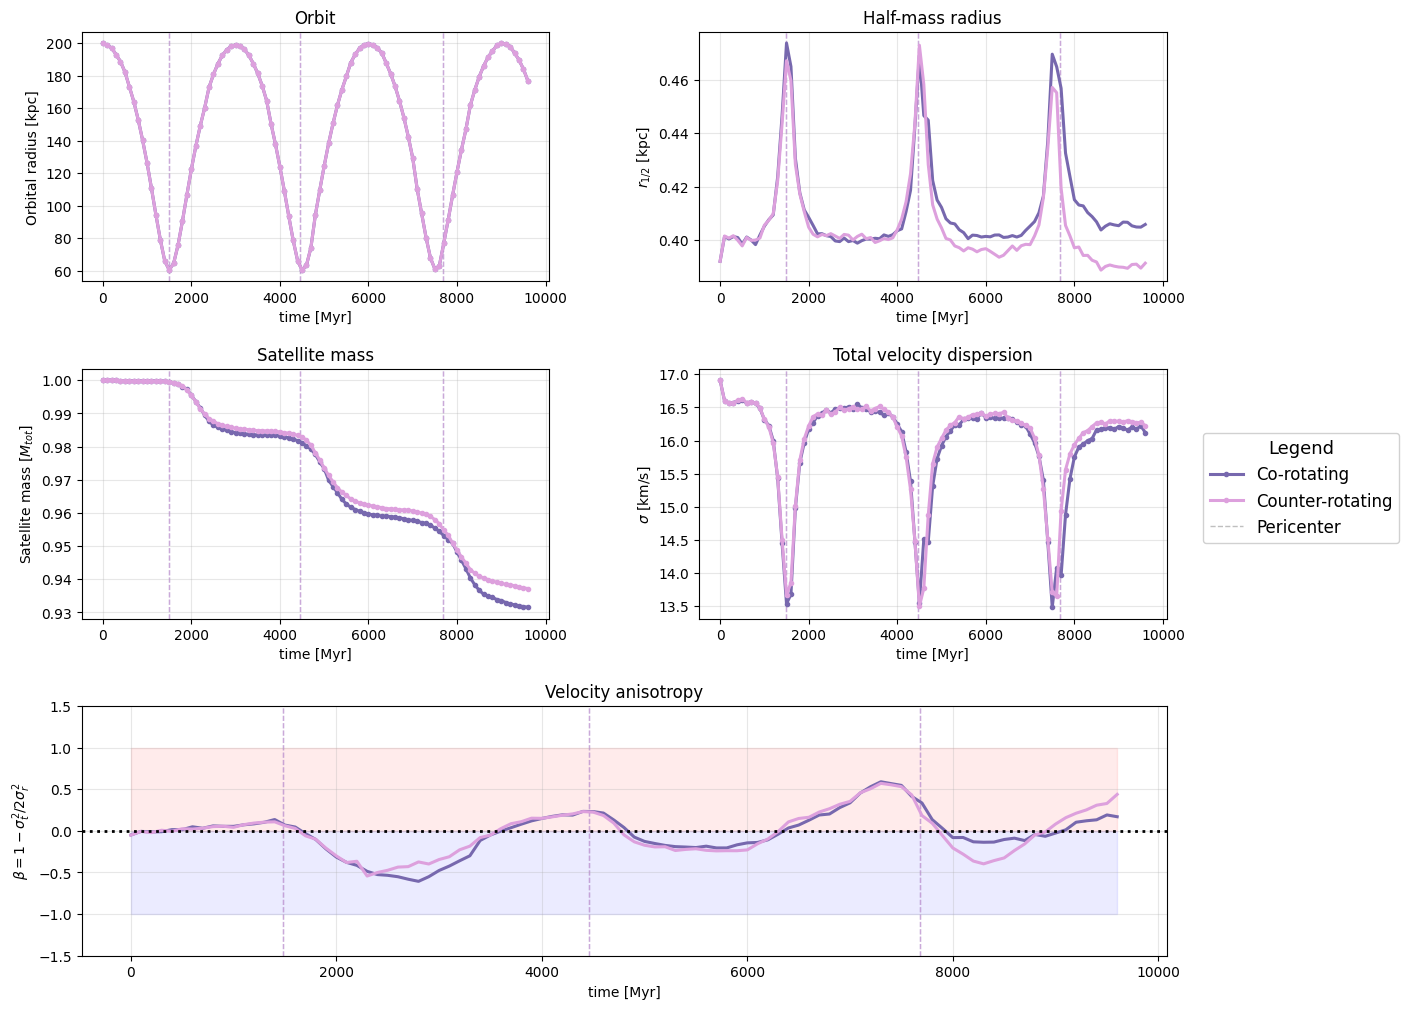

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Nice colors — warm for co-rotating, cool for counter-rotating
C_CO    = '#7768AE'
C_COUNT = "plum"  

beta_mask_r  = np.array(betas_r)  < 1
alpha_mask_r = np.array(alphas_r) < 1
beta_mask_c  = np.array(betas_c)  < 1
alpha_mask_c = np.array(alphas_c) < 1

LW  = 2.2
MS  = 3
MRK = 'o'
t_min_r, _, _, _, _ = get_perigalacticon(t_r, rs)
t_min_c, _, _, _, _ = get_perigalacticon(t_c, rs_c)

dMr = np.gradient(masses_sat_r, t_r)
dMc = np.gradient(masses_sat_c, t_c)
beta_r = np.array([a["global"] for a in anisotropy_r])
beta_c = np.array([a["global"] for a in anisotropy_c])

def add_pericenter(ax, vertical=True):
    if t_min_r is not None:
        for t_v in t_min_r:
            ax.axvline(t_v, color=C_CO, alpha = 0.5, ls='--', lw=1.0, zorder=0)
        for t_v in t_min_c:
            ax.axvline(t_v, color=C_COUNT, alpha = 0.5, ls='--', lw=1.0, zorder=0)


fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.32)

ax_orb  = fig.add_subplot(gs[0, 0])
ax_hmr = fig.add_subplot(gs[0, 1], sharex=ax_orb)
ax_mass   = fig.add_subplot(gs[1, 0], sharex=ax_orb)
ax_dM = fig.add_subplot(gs[1, 1], sharex=ax_orb)
ax_beta = fig.add_subplot(gs[2, :])   # beta spans full width

# --- Orbit ---
ax_orb.plot(t_r, rs, color=C_CO,    lw=LW, ms=MS, marker=MRK, label="Co-rotating")
ax_orb.plot(t_c, rs_c, color=C_COUNT, lw=LW, ms=MS, marker=MRK, label="Counter-rotating")
add_pericenter(ax_orb)
ax_orb.set_ylabel("Orbital radius [kpc]")
ax_orb.set_xlabel("time [Myr]")
ax_orb.set_title("Orbit")
ax_orb.grid(True, alpha=0.3)

# --- Satellite mass ---
ax_mass.plot(t_r, np.array(masses_sat_r)/masses_sat_r[0], color=C_CO,    lw=LW, ms=MS, marker=MRK)
ax_mass.plot(t_c, np.array(masses_sat_c)/masses_sat_c[0], color=C_COUNT, lw=LW, ms=MS, marker=MRK)
add_pericenter(ax_mass)
ax_mass.set_ylabel(r"Satellite mass [$M_{tot}$]")
ax_mass.set_xlabel("time [Myr]")
ax_mass.set_title("Satellite mass")
ax_mass.grid(True, alpha=0.3)

# --- Mass loss rate ---
ax_dM.plot(t_r, sigmas_r, color=C_CO,    lw=LW, ms=MS, marker=MRK)
ax_dM.plot(t_c, sigmas_c, color=C_COUNT, lw=LW, ms=MS, marker=MRK)
add_pericenter(ax_dM)
ax_dM.set_ylabel("$\sigma$ [km/s]")
ax_dM.set_xlabel("time [Myr]")
ax_dM.set_title("Total velocity dispersion")
ax_dM.grid(True, alpha=0.3)

# --- Half-mass radius ---
ax_hmr.plot(t_r, hmr_sat_r, color=C_CO,    lw=LW)
ax_hmr.plot(t_c, hmr_sat_c, color=C_COUNT, lw=LW)
add_pericenter(ax_hmr)
ax_hmr.set_ylabel(r"$r_{1/2}$ [kpc]")
ax_hmr.set_xlabel("time [Myr]")
ax_hmr.set_title("Half-mass radius")
ax_hmr.grid(True, alpha=0.3)

# --- Velocity anisotropy (full width) ---
n_r = min(len(t_r), len(beta_r))
n_c = min(len(t_c), len(beta_c))

ax_beta.plot(t_r[:n_r], beta_r[:n_r], color=C_CO,    lw=LW, label="Co-rotating")
ax_beta.plot(t_c[:n_c], beta_c[:n_c], color=C_COUNT, lw=LW, label="Counter-rotating")
ax_beta.axhline(0, color='k', ls="dotted", lw=2.0, label='Isotropic')

ax_beta.fill_between(t_r[:n_r], 0,  1,
                      alpha=0.08, color="red",    zorder=0)
ax_beta.fill_between(t_r[:n_r], -1, 0,
                      alpha=0.08, color="blue", zorder=0)
add_pericenter(ax_beta)

ax_beta.set_ylim(-1.5, 1.5)
ax_beta.set_ylabel(r"$\beta = 1 - \sigma_t^2/2\sigma_r^2$")
ax_beta.set_xlabel("time [Myr]")
ax_beta.set_title("Velocity anisotropy")
ax_beta.grid(True, alpha=0.3)

# Shared legend entries — proxy artists covering all panels
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], color=C_CO,    lw=LW, ms=MS, marker=MRK,
           label="Co-rotating"),
    Line2D([0], [0], color=C_COUNT, lw=LW, ms=MS, marker=MRK,
           label="Counter-rotating"),
    Line2D([0], [0], color="grey",    lw=1.0, ls='--', alpha=0.5,
           label='Pericenter'),
]

leg = fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   # just outside the right edge, vertically centred
    framealpha=0.9,
    fontsize=12,
    title="Legend",
    title_fontsize=13
)

plt.savefig("co_counter.pdf", dpi=300, bbox_inches="tight",
            bbox_extra_artists=[leg])   # prevents legend being clipped
plt.show()

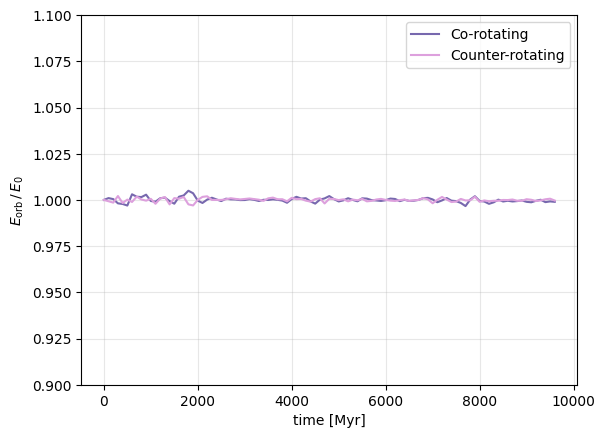

In [ ]:

plt.plot(t_r, np.array(e_orb_r)/e_orb_r[0], c = C_CO, label="Co-rotating")
plt.plot(t_c, np.array(e_orb_c)/e_orb_c[0], c = C_COUNT, label="Counter-rotating")
plt.ylim(0.9, 1.1)
plt.xlabel("time [Myr]")
plt.ylabel(r"$E_\mathrm{orb}\,/\,E_0$")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.savefig("co_count_energy.pdf", dpi=300)
plt.show()

/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [1.99955573e+02 5.20526552e-02 2.48703761e-02], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=2, com_sat: [198.15847166  13.45081904   0.24427696], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=3, com_sat: [195.80163297  20.87527671   0.46650639], bound mass: 1.001e+07
  [efe=False] iter  1: N=49995  M=1.001e+07 Msun
Mass ratio: 0.9999
i=4, com_sat: [190.27284092  31.76702781   0.83140781], bound mass: 1.001e+07
  [efe=False] iter  1: N=49992  M=1.000e+07 Msun
Mass ratio: 0.99984
i=5, com_sat: [184.94602005  38.68112498   1.09862684], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=6, com_sat: [175.85624217  47.98725239   1.45389453], bound mass: 1.000e+07
  [efe=False] iter  1: N=49989  M=1.000e+07 Msun
Mass ratio: 0.99978
i=7, com_sat: [163.7625

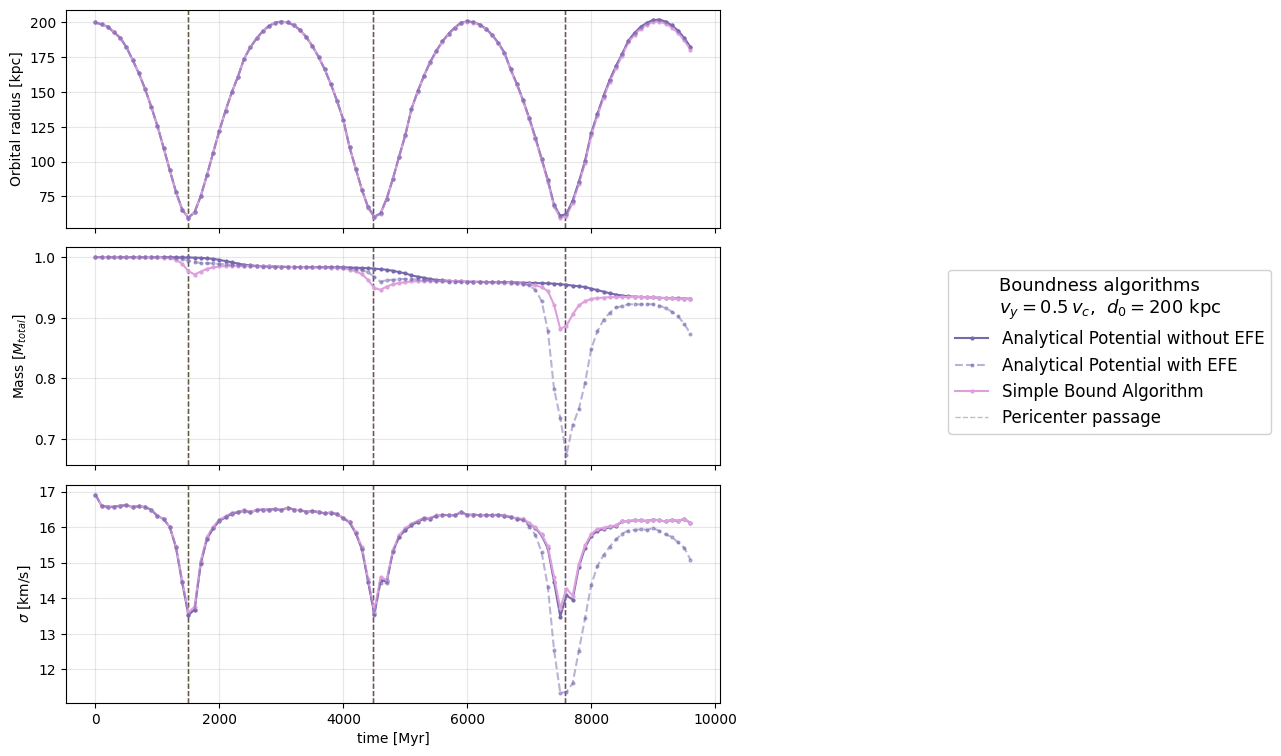

In [ ]:
d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/new_h_res_15e3/"
x0, vx, y0 = 200, 0, 0
vy = 200
n_iter = get_max_file_number(d)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.subplots_adjust(right=0.72, hspace=0.09)   # leave room for external legend

t, all_pos, all_vel, all_mass, pos_sat, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = False, movie=False)

t_3, all_pos_3, all_vel_3, all_mass_3, pos_sat_3, coms_sat_3, com_host_3, rs_3, sigmas_3, masses_host_3, masses_sat_3, rhos_host_3, rhos_sat_3, bins_host_3, bins_sat_3, hmr_sat_3, lag_sat_3, all_clusters_3, all_remnants_3, alphas_3, betas_3, r_centers_3, tot_sigmas_bin_3, rb_array_3, anisotropy_3, e_orb_3, l_orb_3, tidals_3, disrupt_3  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = True, movie=False)

t_2, all_pos_2, all_vel_2, all_mass_2, rs_2, sigmas_2, masses_host_2, masses_sat_2, rhos_host_2, rhos_sat_2, bins_host_2, bins_sat_2, hmr_sat_2, lag_sat_2, all_remnants_2, alphas_2, betas_2, r_centers_2, tot_sigmas_bin_2, rb_array_2, tidals_2,jacobs_2,anisotropy_2  = plotting_simple(
        d, 100,n_iter, 300,x0,y0,vx,vy, N_host=15000, grid_length=600, movie=False)

t_min, r_min, t_max, r_max, e = get_perigalacticon(t, rs, factor = 100)
t_min_2, r_min_2, t_max_2, r_max_2, e_2 = get_perigalacticon(t_2, rs_2, factor = 100)
t_min_3, r_min_3, t_max_3, r_max_3, e_3 = get_perigalacticon(t_3, rs_3, factor = 100)
for t_v in t_min:
        axes[0].axvline(t_v, color="b", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[1].axvline(t_v, color="b", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[2].axvline(t_v, color="b", alpha = 0.5, ls='--', lw=1.0, zorder=0)
for t_v in t_min_2:
        axes[0].axvline(t_v, color="r", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[1].axvline(t_v, color="r", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[2].axvline(t_v, color="r", alpha = 0.5, ls='--', lw=1.0, zorder=0)
for t_v in t_min_3:
        axes[0].axvline(t_v, color="g", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[1].axvline(t_v, color="g", alpha = 0.5, ls='--', lw=1.0, zorder=0)
        axes[2].axvline(t_v, color="g", alpha = 0.5, ls='--', lw=1.0, zorder=0)

axes[0].plot(t, rs, marker = "o", ms = 2, color="#7768AE")
axes[0].plot(t_2, rs_2, marker = "o", ms = 2, color="plum")
axes[0].plot(t_3, rs_3, marker = "o", ms = 2, color="#7768AE", ls = "--", alpha = 0.5)
axes[0].set_ylabel("Orbital radius [kpc]")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t, np.array(masses_sat)/np.array(masses_sat[0]), marker = "o",ms = 2, color="#7768AE")
axes[1].plot(t_2, np.array(masses_sat_2)/np.array(masses_sat_2[0]), marker = "o", ms = 2, color="plum")
axes[1].plot(t_3, np.array(masses_sat_3)/np.array(masses_sat_3[0]), marker = "o", ms = 2, color="#7768AE", ls = "--", alpha = 0.5)
axes[1].set_ylabel(r"Mass [$M_{total}$]")
axes[1].grid(True, alpha=0.3)
axes[2].plot(t, sigmas, marker = "o", ms = 2, color="#7768AE")
axes[2].plot(t_2, sigmas_2, marker = "o", ms = 2, color="plum")
axes[2].plot(t_3, sigmas_3, marker = "o", ms = 2, color="#7768AE", ls = "--", alpha = 0.5)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylabel(r"$\sigma$ [km/s]")
axes[2].set_xlabel("time [Myr]")
legend_elements = [
    Line2D([0], [0], label=f"Analytical Potential without EFE", marker="o", ms=2, color="#7768AE"),
    Line2D([0], [0], label=f"Analytical Potential with EFE", marker="o", ms=2, color="#7768AE", ls = "--", alpha = 0.5),
    Line2D([0], [0], label=f"Simple Bound Algorithm", marker="o", ms=2, color="plum"),
    Line2D([0], [0], label=f"Pericenter passage", ls = "--", lw=1, color="grey", alpha = 0.5),
]

leg = fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   # just outside the right edge, vertically centred
        title        = "Boundness algorithms \n" + r"$v_y = 0.5\,v_c$,  $d_0 = 200$ kpc",
    framealpha=0.9,
    fontsize=12,
    title_fontsize=13
)
plt.savefig("co_simple_vs_complex.pdf", dpi=300, bbox_inches="tight")
plt.show()

50000
  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [2.00030485e+02 4.31584026e-02 8.05649415e-03], bound mass: 1.001e+07
50000
  [efe=False] iter  1: N=49994  M=1.000e+07 Msun
Mass ratio: 0.99988
i=2, com_sat: [ 1.97475361e+02  1.15928351e+01 -1.81288577e-01], bound mass: 1.000e+07
50000
  [efe=False] iter  1: N=49992  M=1.000e+07 Msun
Mass ratio: 0.99984
i=3, com_sat: [195.08142584  20.50199203  -0.37013714], bound mass: 1.000e+07
50000
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=4, com_sat: [189.31983363  30.8346525   -0.74844302], bound mass: 1.000e+07
50000
  [efe=False] iter  1: N=49988  M=1.000e+07 Msun
Mass ratio: 0.99976
i=5, com_sat: [182.33439151  40.70986286  -1.01214353], bound mass: 1.000e+07
50000
  [efe=False] iter  1: N=49987  M=1.000e+07 Msun
Mass ratio: 0.9997400000000002
i=6, com_sat: [172.89893627  49.50482653  -1.30288548], bound mass: 1.000e+07
50000
  [efe=False] iter  1: N=49985  M=1.000e+07 Msun
Ma

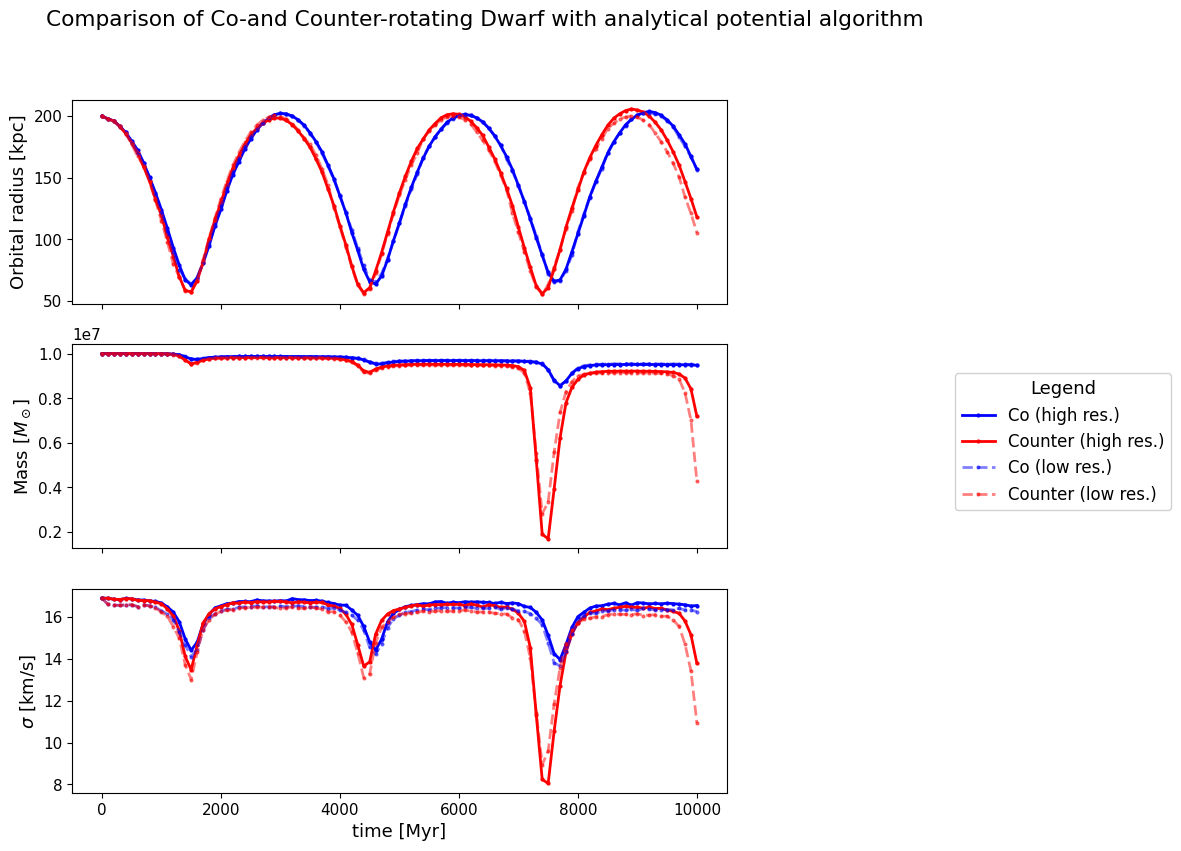

In [ ]:
runs = ["high_res_0.5/co","high_res_0.5/counter", "new_0.5", "0.5_counter"]
labels = ["Co (high res.)", "Counter (high res.)", "Co (low res.)", "Counter (low res.)"]
line_colors = ["b", "r", "b", "r"]  # Renamed from colors
line_styles = ["-", "-", "--", "--"]  # Renamed from lss
alphas_list = [1, 1, 0.5, 0.5]  # Renamed from alphas (avoid collision)
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.subplots_adjust(right=0.72, hspace=0.2)   # leave room for external legend

for n, (i, l, c, ls, a) in enumerate(zip(runs, labels, line_colors, line_styles, alphas_list)):
    d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/{i}/"
    x0, vx, y0 = 200, 0, 0
    vy = v
    n_iter = get_max_file_number(d)
    t, all_pos, all_vel, all_mass, pos_sat, coms_sat, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals  = plotting(
        d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=6000, grid_length=600, efe = False, movie=False)
    t_min, r_min, t_max, r_max, e = get_perigalacticon(t, rs)
    axes[0].plot(t, rs, marker = "o", ms = 2, label = f"{l}", color=c, linestyle=ls, alpha=a)
    axes[0].set_ylabel("Orbital radius [kpc]")
    axes[1].plot(t, masses_sat, marker = "o",ms = 2, color=c, linestyle=ls, alpha=a)
    axes[1].set_ylabel(r"Mass [$M_\odot$]")
    axes[2].plot(t, sigmas, marker = "o", ms = 2, color=c, linestyle=ls, alpha=a)
    axes[2].set_ylabel(r"$\sigma$ [km/s]")
    axes[2].set_xlabel("time [Myr]")

legend_elements = [
    Line2D([0], [0], label=f"{labels[0]}", marker="o", ms=2, color=line_colors[0], linestyle=line_styles[0], alpha=alphas_list[0]),
    Line2D([0], [0], label=f"{labels[1]}", marker="o", ms=2, color=line_colors[1], linestyle=line_styles[1], alpha=alphas_list[1]),
    Line2D([0], [0], label=f"{labels[2]}", marker="o", ms=2, color=line_colors[2], linestyle=line_styles[2], alpha=alphas_list[2]),
    Line2D([0], [0], label=f"{labels[3]}", marker="o", ms=2, color=line_colors[3], linestyle=line_styles[3], alpha=alphas_list[3]),
]


leg = fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   # just outside the right edge, vertically centred
    framealpha=0.9,
    fontsize=12,
    title="Legend",
    title_fontsize=13
)
fig.suptitle("Comparison of Co-and Counter-rotating Dwarf with analytical potential algorithm")
plt.savefig("co_counter_complex.pdf", dpi=300, bbox_inches="tight")
plt.show()

/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [1.99955573e+02 5.20526552e-02 2.48703761e-02], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=2, com_sat: [198.15847166  13.45081904   0.24427696], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=3, com_sat: [195.80163297  20.87527671   0.46650639], bound mass: 1.001e+07
  [efe=False] iter  1: N=49995  M=1.001e+07 Msun
Mass ratio: 0.9999
i=4, com_sat: [190.27284092  31.76702781   0.83140781], bound mass: 1.001e+07
  [efe=False] iter  1: N=49992  M=1.000e+07 Msun
Mass ratio: 0.99984
i=5, com_sat: [184.94602005  38.68112498   1.09862684], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=6, com_sat: [175.85624217  47.98725239   1.45389453], bound mass: 1.000e+07
  [efe=False] iter  1: N=49989  M=1.000e+07 Msun
Mass ratio: 0.99978
i=7, com_sat: [163.7625

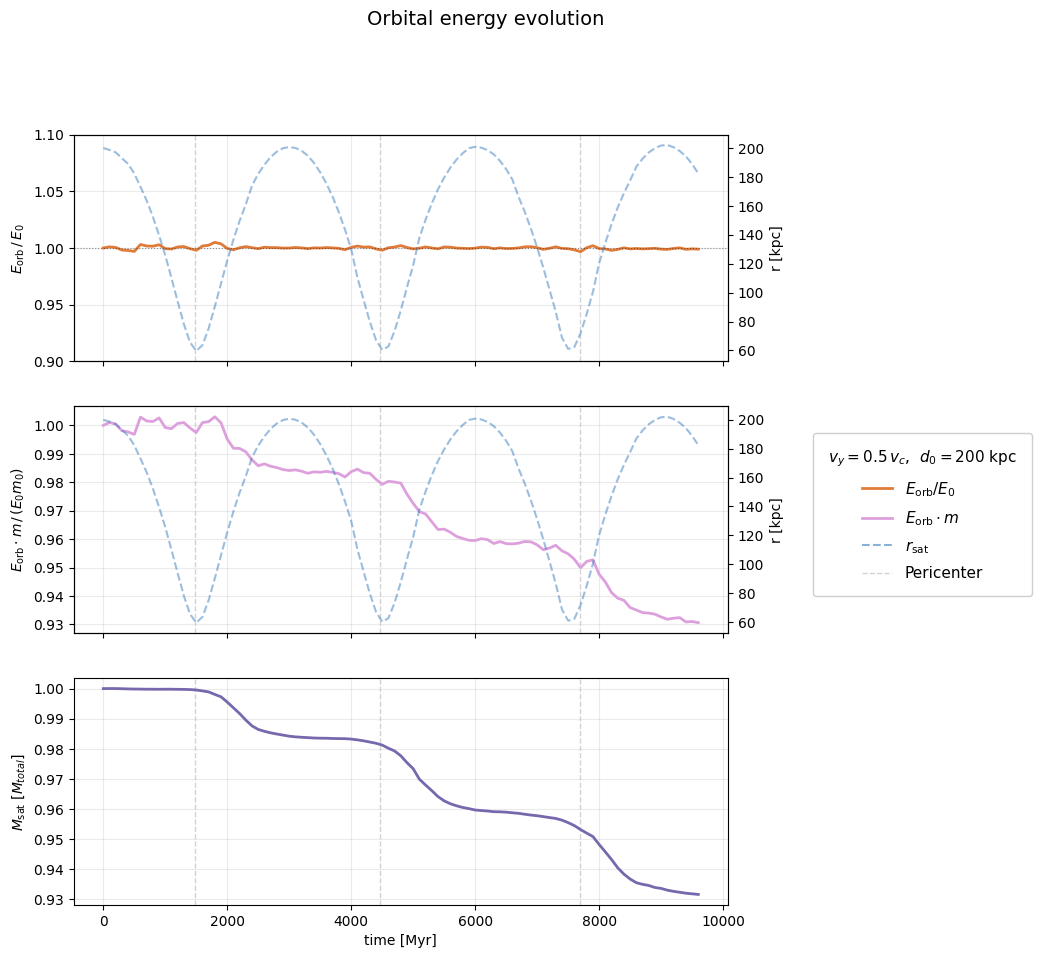

In [ ]:
d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/new_h_res_15e3/"
x0, vx, y0 = 200, 0, 0
vy = "0.5vc"
n_iter = get_max_file_number(d)

t, all_pos, all_vel, all_mass, pos_sat, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt = plotting(d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = False,movie=False)
t_min, r_min, t_max, r_max, e = get_perigalacticon(t, rs)

C_E   = "#E07B39"   # orange  — energy
C_EM  = "plum"
C_R   = "#3A7DBF"   # blue    — orbital radius

t_arr  = np.array(t,          dtype=float)
E_arr  = np.array(e_orb,      dtype=float)
M_arr  = np.array(masses_sat, dtype=float)
r_arr  = np.array(rs,         dtype=float)
E_m    = E_arr * M_arr

# Normalise
E_norm  = E_arr / E_arr[0]
Em_norm = E_m   / E_m[0]

# ── Figure: 3 stacked panels, shared x ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
fig.subplots_adjust(hspace=0.2, right=0.72)

# ── Panel 1: Specific orbital energy + orbital radius ───────────────────────
ax1  = axes[0]
ax1r = ax1.twinx()

ax1.plot(t_arr,   E_norm,   color=C_E, lw=2.0, label=r'$E_\mathrm{orb}/E_0$')
ax1r.plot(t_arr, r_arr, ls = "dashed", color=C_R,  lw=1.5, alpha=0.5)
ax1.set_ylabel(r"$E_\mathrm{orb}\,/\,E_0$")
ax1r.set_ylabel("r [kpc]")
ax1r.tick_params(axis='y')
ax1.set_ylim(0.9, 1.1)
ax1.axhline(1, color='k', ls=':', lw=0.8, alpha=0.4)

# ── Panel 2: Total orbital energy × mass + orbital radius ───────────────────
ax2  = axes[1]
ax2r = ax2.twinx()

ax2.plot(t_arr,   Em_norm,              color=C_EM, lw=2.0,
         label=r'$E_\mathrm{orb} \cdot m\,/\,(E_0 m_0)$')
ax2r.plot(t_arr, r_arr, ls = "dashed", color=C_R, lw=1.5, alpha=0.5)

ax2.set_ylabel(r"$E_\mathrm{orb}\cdot m\,/\,(E_0 m_0)$")
ax2r.set_ylabel("r [kpc]")
ax2r.tick_params(axis='y')

# ── Panel 3: Satellite mass ──────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(t_arr, M_arr/M_arr[0], color='#7768AE', lw=2.0, label=r'$M_\mathrm{sat}$')
ax3.set_ylabel(r"$M_\mathrm{sat}$ [$M_{total}$]")
ax3.set_xlabel("time [Myr]")

# Pericenter lines on all panels
for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.25)
    if t_min is not None:
        for t_v in t_min:
            ax.axvline(t_v, color='lightgrey', ls='--', lw=1.0, zorder=0)

# ── Shared legend outside ────────────────────────────────────────────────────
from matplotlib.lines  import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D([0], [0], color=C_E,   lw=2, label=r'$E_\mathrm{orb}/E_0$'),
    Line2D([0], [0], color=C_EM,  lw=2, label=r'$E_\mathrm{orb}\cdot m$ '),
    Line2D([0], [0], color=C_R,   ls = "dashed", lw=1.5, alpha=0.6, label=r'$r_\mathrm{sat}$'),
    Line2D([0], [0], color='lightgrey', ls='--', lw=1, label='Pericenter'),
]

leg = fig.legend(
    handles        = legend_handles,
    loc            = 'center left',
    bbox_to_anchor = (0.79, 0.5),
    framealpha     = 0.95,
    fontsize       = 11,
    title          = r"$v_y=0.5\,v_c$,  $d_0=200$ kpc",
    title_fontsize = 11,
    labelspacing   = 0.7,
    borderpad      = 1.0,
)

fig.suptitle("Orbital energy evolution", fontsize=14, y=1.005)

plt.savefig("orbital_energy_evolution.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])
plt.show()


/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49997  M=1.001e+07 Msun
Mass ratio: 0.99994
i=1, com_sat: [1.99955573e+02 5.20526552e-02 2.48703761e-02], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=2, com_sat: [198.15847166  13.45081904   0.24427696], bound mass: 1.001e+07
  [efe=False] iter  1: N=49998  M=1.001e+07 Msun
Mass ratio: 0.9999600000000001
i=3, com_sat: [195.80163297  20.87527671   0.46650639], bound mass: 1.001e+07
  [efe=False] iter  1: N=49995  M=1.001e+07 Msun
Mass ratio: 0.9999
i=4, com_sat: [190.27284092  31.76702781   0.83140781], bound mass: 1.001e+07
  [efe=False] iter  1: N=49992  M=1.000e+07 Msun
Mass ratio: 0.99984
i=5, com_sat: [184.94602005  38.68112498   1.09862684], bound mass: 1.000e+07
  [efe=False] iter  1: N=49990  M=1.000e+07 Msun
Mass ratio: 0.9998
i=6, com_sat: [175.85624217  47.98725239   1.45389453], bound mass: 1.000e+07
  [efe=False] iter  1: N=49989  M=1.000e+07 Msun
Mass ratio: 0.99978
i=7, com_sat: [163.7625

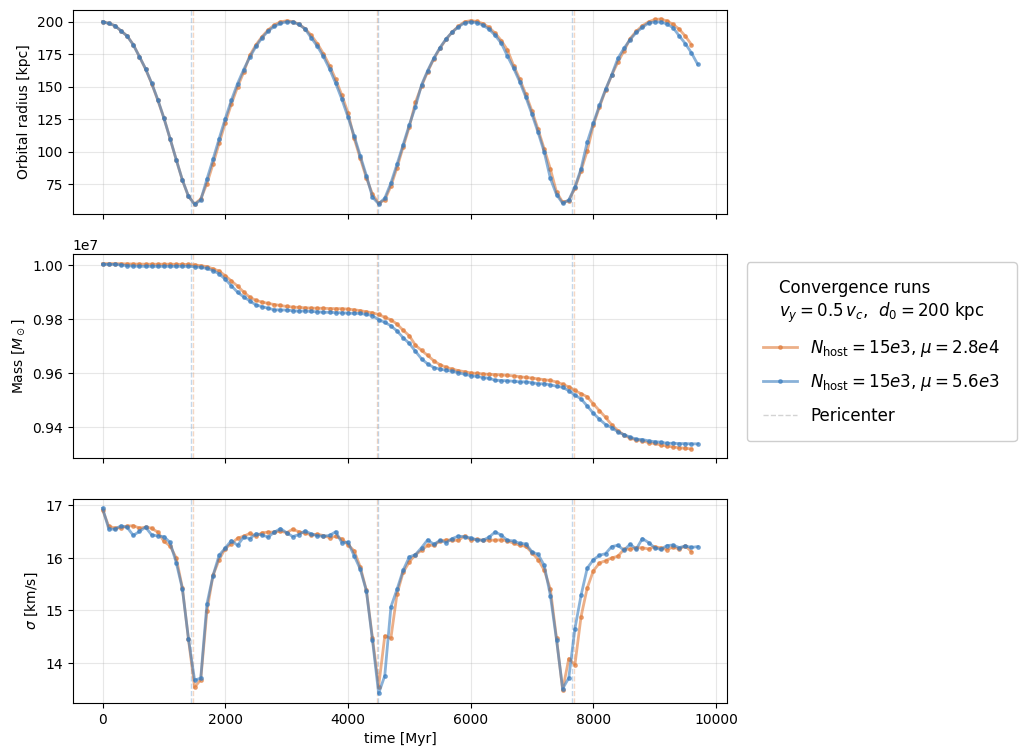

In [ ]:
runs        = ["new_h_res_15e3", "new_res_15e4_1e4"]
labels      = [#r"$N_\mathrm{host} = 6e3$,  $\mu = 7e4$",
               r"$N_\mathrm{host} = 15e3$, $\mu = 2.8e4$",
               r"$N_\mathrm{host} = 15e3$, $\mu = 5.6e3$"]
hosts       = [15000, 15000]
C           = ["#E07B39", "#3A7DBF", "mediumorchid"]
MS, MRK    = 2.5, 'o'

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.subplots_adjust(right=0.72, hspace=0.2)   # leave room for external legend

stored = {}   # store results for pericenter lines

for n, (run, label, c) in enumerate(zip(runs, labels, C)):
    d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_200/0.5/{run}/"
    n_iter = get_max_file_number(d)

    t, all_pos, all_vel, all_mass, pos_sat, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt = plotting(
        d, 100, n_iter, 300, 200, 0, 0, 0.5,
        N_host=hosts[n], grid_length=600, efe = False, movie=False)

    t_min, r_min, t_max, r_max, e = get_perigalacticon(t, rs)
    stored[n] = dict(t=t, rs=rs, masses_sat=masses_sat,
                     sigmas=sigmas, t_min=t_min, c=c)

    t_arr = np.array(t, dtype=float)

    axes[0].plot(t_arr, rs,         color=c, lw=2.0, alpha=0.6, ms=MS, marker=MRK, label=label)
    axes[1].plot(t_arr, masses_sat, color=c, lw=2.0, alpha=0.6, ms=MS, marker=MRK)
    axes[2].plot(t_arr, sigmas,     color=c, lw=2.0, alpha=0.6, ms=MS, marker=MRK)

# Pericenter markers — only for run 0 (reference) to keep it clean
t_min_1 = stored[0]["t_min"]
t_min_2 = stored[1]["t_min"]
if t_min_1 is not None:
    for t_v in t_min_1:
        for ax in axes:
            ax.axvline(t_v, color=C[0], alpha=0.3, ls="--", lw=1.0, zorder=0)
    for t_v in t_min_2:
        for ax in axes:
            ax.axvline(t_v, color=C[1], alpha = 0.3, ls="--", lw=1.0, zorder=0)

# Axis labels
axes[0].set_ylabel("Orbital radius [kpc]")
axes[1].set_ylabel(r"Mass [$M_\odot$]")
axes[2].set_ylabel(r"$\sigma$ [km/s]")
axes[2].set_xlabel("time [Myr]")
for ax in axes:
    ax.grid(True, alpha=0.3)

# Shared external legend
peri_line = Line2D([0], [0], color='lightgrey', ls='--', lw=1.0,
                   label='Pericenter')

handles = [
    Line2D([0], [0], color=C[0], lw=2.0, ms=MS, marker=MRK, alpha = 0.6, label=labels[0]),
    Line2D([0], [0], color=C[1], lw=2.0, ms=MS, marker=MRK, alpha = 0.6, label=labels[1]),
    #Line2D([0], [0], color=C[2], lw=2.0, ms=MS, marker=MRK, alpha = 0.6, label=labels[2]),
    peri_line,
]

leg = fig.legend(
    handles      = handles,
    loc          = 'center left',
    bbox_to_anchor = (0.73, 0.5),
    framealpha   = 0.95,
    fontsize     = 12,
    title        = "Convergence runs\n" + r"$v_y = 0.5\,v_c$,  $d_0 = 200$ kpc",
    title_fontsize = 12,
    borderpad    = 1.0,
    labelspacing = 0.8,
)

plt.savefig("convergence_check_n_host.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])
plt.show()

In [ ]:
N_host_runs = [6000, 15000, 25000]
m_sat         = 1e7/50000
M_host       = 8.4e10
for N in N_host_runs:
    m_h = M_host / N
    mu  = m_h / m_sat
    print(f"N_host={N:>7,}: m_host={m_h:.2e}, mass ratio to dwarf particle={mu:.0f}")

N_host=  6,000: m_host=1.40e+07, mass ratio to dwarf particle=70000
N_host= 15,000: m_host=5.60e+06, mass ratio to dwarf particle=28000
N_host= 25,000: m_host=3.36e+06, mass ratio to dwarf particle=16800


In [ ]:
N_host_runs = [6000, 15000, 25000]
m_sat         = 1e7/10000
M_host       = 8.4e10
for N in N_host_runs:
    m_h = M_host / N
    mu  = m_h / m_sat
    print(f"N_host={N:>7,}: m_host={m_h:.2e}, mass ratio to dwarf particle={mu:.0f}")

N_host=  6,000: m_host=1.40e+07, mass ratio to dwarf particle=14000
N_host= 15,000: m_host=5.60e+06, mass ratio to dwarf particle=5600
N_host= 25,000: m_host=3.36e+06, mass ratio to dwarf particle=3360


In [ ]:
d = f"/Users/olgahinke/Desktop/simus/dice_mw/d_100/0.8_vc/"
x0, vx, y0 = 100, 0, 0
vy = "0.8vc"
n_iter = get_max_file_number(d)
t, all_pos, all_vel, all_mass, pos_sat, coms_sat, com_host, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, all_clusters, all_remnants, alphas, betas, r_centers, tot_sigmas_bin, rb_array, anisotropy, e_orb, l_orb, tidals, disrupt = plotting(d, 100, n_iter, 300, x0, y0, vx, vy,
        N_host=15000, grid_length=600, efe = False, movie=True)

/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/dwarf_por/.venv/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


  [efe=False] iter  1: N=49988  M=1.000e+07 Msun
Mass ratio: 0.99976
i=1, com_sat: [9.99556223e+01 5.20096334e-02 2.48884091e-02], bound mass: 1.000e+07
  [efe=False] iter  1: N=49969  M=1.000e+07 Msun
Mass ratio: 0.9993799999999999
i=2, com_sat: [96.19175855 21.35427098  0.24706495], bound mass: 1.000e+07
  [efe=False] iter  1: N=49878  M=9.982e+06 Msun
Mass ratio: 0.99756
i=3, com_sat: [91.01257177 32.6473276   0.43913453], bound mass: 9.982e+06
  [efe=False] iter  1: N=49703  M=9.947e+06 Msun
Mass ratio: 0.99406
i=4, com_sat: [79.31602018 47.78240985  0.77321031], bound mass: 9.947e+06
  [efe=False] iter  1: N=49599  M=9.926e+06 Msun
Mass ratio: 0.9919800000000001
i=5, com_sat: [69.14917604 56.08810497  1.03245231], bound mass: 9.926e+06
  [efe=False] iter  1: N=49541  M=9.914e+06 Msun
Mass ratio: 0.99082
i=6, com_sat: [51.41197978 65.26443513  1.38153323], bound mass: 9.914e+06
  [efe=False] iter  1: N=49477  M=9.902e+06 Msun
Mass ratio: 0.98954
i=7, com_sat: [29.86424708 69.519766

In [ ]:
# Assume: disrupted = boolean array of length n_snapshots, True = disrupted
# t_arr = time array of same length

def shade_disrupted(ax, t_arr, disrupted, color='lightgrey', alpha=0.3,
                    label='Disrupted', already_labeled=False):
    """
    Shade background where disrupted=True using contiguous blocks.
    Returns whether the label was added (to avoid duplicate legend entries).
    """
    from itertools import groupby
    from operator  import itemgetter

    disrupted = np.array(disrupted, dtype=bool)
    in_dis    = np.where(disrupted)[0]
    if len(in_dis) == 0:
        return already_labeled

    labeled = already_labeled
    for k, g in groupby(enumerate(in_dis), lambda x: x[0] - x[1]):
        group   = list(map(itemgetter(1), g))
        t_start = t_arr[group[0]]
        t_end   = t_arr[group[-1]]
        ax.axvspan(t_start, t_end,
                   color=color, alpha=alpha, zorder=0,
                   label='_nolegend_' if labeled else label)
        labeled = True

    return labeled

# Plot in segments: solid when intact, dashed when disrupted
def plot_segments(ax, t, data, disrupted, color, label):
    """Plot line with solid/dashed switching at disruption boundaries."""
    from itertools import groupby
    first   = True
    for is_dis, g in groupby(enumerate(disrupted), key=lambda x: x[1]):
        group = [x[0] for x in g]
        # Include one extra point at boundaries for continuity
        idx   = group
        if group[0] > 0:
            idx = [group[0] - 1] + idx
        if group[-1] < len(t) - 1:
            idx = idx + [group[-1] + 1]

        ls = '--' if is_dis else '-'
        ax.plot(t[idx], data[idx], color=color, ls=ls, lw=2,
                label=label if first else '_nolegend_')
        first = False

Found minima at times: [ 917.80500283 2755.21846104 4602.79810139 6438.40441405 8257.99738324]
Values at minima: [63.90924458 63.83804825 63.56747792 62.52449221 63.60005535]
Found maxima at times: [  77.00174699 1805.27229254 3665.20715699 5507.24289082 7346.25916627
 9186.96952928]
Values at maxima: [ 99.98435428 101.6712708  101.43577222 101.32099032 101.30471273
 101.05036142]


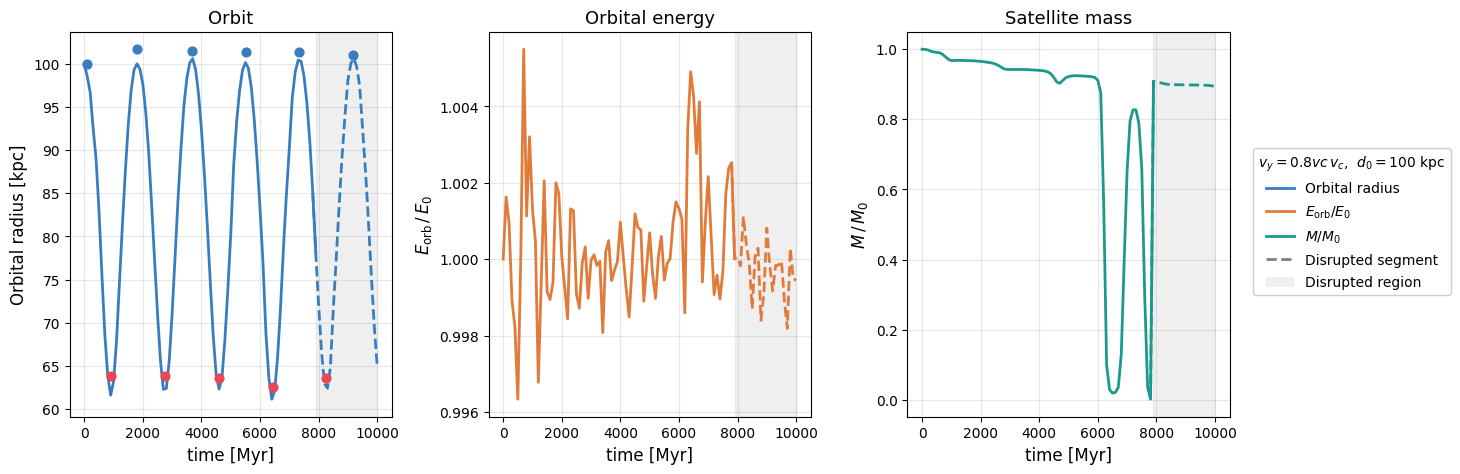

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines   import Line2D


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=0.3, right=0.85)
t_min, r_min, t_max, r_max, e = get_perigalacticon(t, rs, factor = 1)

n       = min(len(t), len(disrupt))
t_arr   = np.array(t[:n],        dtype=float)
rs_arr  = np.array(rs[:n],       dtype=float)
e_arr   = np.array(e_orb[:n],    dtype=float)
m_arr   = np.array(masses_sat[:n], dtype=float)
dis_arr = np.array(disrupt[:n],  dtype=bool)

# Shade disrupted on all panels
for ax in axes:
    shade_disrupted(ax, t_arr, dis_arr,
                    color='lightgrey', alpha=0.35, label='_nolegend_')

# Plot segments
plot_segments(axes[0], t_arr, rs_arr, dis_arr,
              color='#3A7DBF', label='Orbital radius')
plot_segments(axes[1], t_arr, e_arr / e_arr[0], dis_arr,
              color='#E07B39', label=r'$E_\mathrm{orb}/E_0$')
plot_segments(axes[2], t_arr, m_arr / m_arr[0], dis_arr,
              color='#1B998B', label=r'$M/M_0$')

# Labels
axes[0].set_ylabel("Orbital radius [kpc]", fontsize=12)
axes[1].set_ylabel(r"$E_\mathrm{orb}\,/\,E_0$", fontsize=12)
axes[2].set_ylabel(r"$M\,/\,M_0$", fontsize=12)
for ax in axes:
    ax.set_xlabel("time [Myr]", fontsize=12)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Orbit",          fontsize=13)
axes[1].set_title("Orbital energy", fontsize=13)
axes[2].set_title("Satellite mass", fontsize=13)

# Second y-axis on orbit panel showing pericenter/apocenter distances
if t_min is not None and r_min is not None:
    axes[0].scatter(t_min, r_min, color='#E84855', s=40, zorder=5,
                 label='Pericenter')
    axes[0].scatter(t_max,  r_max, color='#3A7DBF', s=40, zorder=5,
                 label='Apocenter')

# Shared legend
legend_handles = [
    Line2D([0], [0], color='#3A7DBF', lw=2, ls='-',
           label='Orbital radius'),
    Line2D([0], [0], color='#E07B39', lw=2, ls='-',
           label=r'$E_\mathrm{orb}/E_0$'),
    Line2D([0], [0], color='#1B998B', lw=2, ls='-',
           label=r'$M/M_0$'),
    Line2D([0], [0], color='grey',    lw=2, ls='--',
           label='Disrupted segment'),
    Patch(facecolor='lightgrey', alpha=0.35,
          label='Disrupted region'),
]

leg = fig.legend(
    handles        = legend_handles,
    loc            = 'center left',
    bbox_to_anchor = (0.86, 0.5),
    fontsize       = 10,
    framealpha     = 0.95,
    title          = rf"$v_y = {vy}\,v_c$,  $d_0 = {x0}$ kpc",
    title_fontsize = 10,
    labelspacing   = 0.6,
)

plt.savefig("disrupted_run.pdf", dpi=300,
            bbox_inches="tight", bbox_extra_artists=[leg])
plt.show()

In [ ]:
def rho_disk_spherical(r_kpc, Sigma0, Rd, zd):
    """
    Spherically-averaged Miyamoto-Nagai / exponential disk density.
    For a purely spherical host approximation, use the enclosed mass
    approach directly rather than trying to sphericalize a disk.
    The enclosed mass of a Miyamoto-Nagai disk within radius r is:
        M(<r) ≈ 2π Sigma0 Rd^2 [1 - exp(-r/Rd)(1 + r/Rd)]   (thin disk limit)
    """
    return 2 * np.pi * Sigma0 * Rd**2 * np.exp(-r_kpc/Rd) / (4*np.pi*r_kpc**2)

def M_enc_mcmillan(R_kpc):
    """
    Enclosed baryonic mass of MW within radius R,
    M_tot = 9.15e10 Msun (Banik 2020, Table 2)
    Components:
      thin disk   : 0.1764, M_tot, scale 1.29 kpc, aspect ratio 0.0461
      thick disk  : 0.8236 M_tot, scale 4.2 kpc, aspect ratio 0.15
    """
    R_kpc = np.asarray(R_kpc, float)

    # --- disks: enclosed mass in spherical shell (thin-disk limit)
    def M_disk_enc(R, Sigma0, Rd):
        """Spherically-enclosed mass of exponential disk (face-on integral, no z)."""
        x = R / Rd
        return 2*np.pi * Sigma0 * Rd**2 * (1 - np.exp(-x)*(1 + x))

    M_thin  = M_disk_enc(R_kpc, Sigma0=8.96e8, Rd=2.5)
    M_thick = M_disk_enc(R_kpc, Sigma0=1.83e8, Rd=3.02)

    return M_thin + M_thick


def rho_ana_mw(r_kpc, dr_rel=1e-3):
    """
    Spherical baryonic density of the MW from the enclosed mass profile,
    recovered via dM/dr = 4 pi r^2 rho.
    This is what you feed into the MOND Poisson solver as rho_ana.
    """
    r_kpc = np.asarray(r_kpc, float)
    dr    = r_kpc * dr_rel
    M_hi  = M_enc_mcmillan(r_kpc + dr)
    M_lo  = M_enc_mcmillan(r_kpc - dr)
    dMdr  = (M_hi - M_lo) / (2*dr)
    return dMdr / (4*np.pi * r_kpc**2)

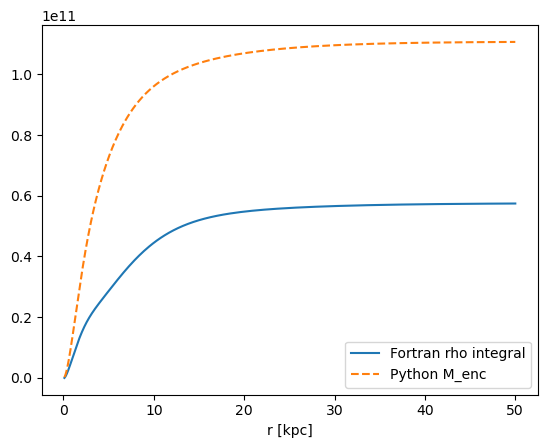

In [ ]:
r = np.geomspace(0.1, 50, 300)   # kpc

rho_b = 9.93e10 / (1 + r/0.075)**1.8 * np.exp(-(r/2.1)**2)
rho_d = (8.96e8/(2*2.5**2))*np.exp(-r/2.5) + \
        (1.83e8/(2*3.02**2))*np.exp(-r/3.02) + \
        (5.31e7/(2*7.0**2))*np.exp(-r/7.0)

rho_tot = rho_b + rho_d   # Msun/kpc^3

from scipy.integrate import cumulative_trapezoid
M_enc_fortran = 4*np.pi * cumulative_trapezoid(rho_tot * r**2, r, initial=0)
M_enc_python  = M_enc_mcmillan(r)

plt.plot(r, M_enc_fortran, label='Fortran rho integral')
plt.plot(r, M_enc_python,  label='Python M_enc', ls='--')
plt.xlabel('r [kpc]'); plt.legend()
# These should agree to within a few percent — if they don't, there's a unit error

Found minima at times: [1404.62817311 4408.29346222 7757.4494641 ]
Values at minima: [86.592394   96.75569065 90.76339919]
Found minima at times: [ 137.66535418 2926.64689286 6101.18844652 9231.41918787]
Values at minima: [203.58397878 191.69526842 204.006725   210.38373227]


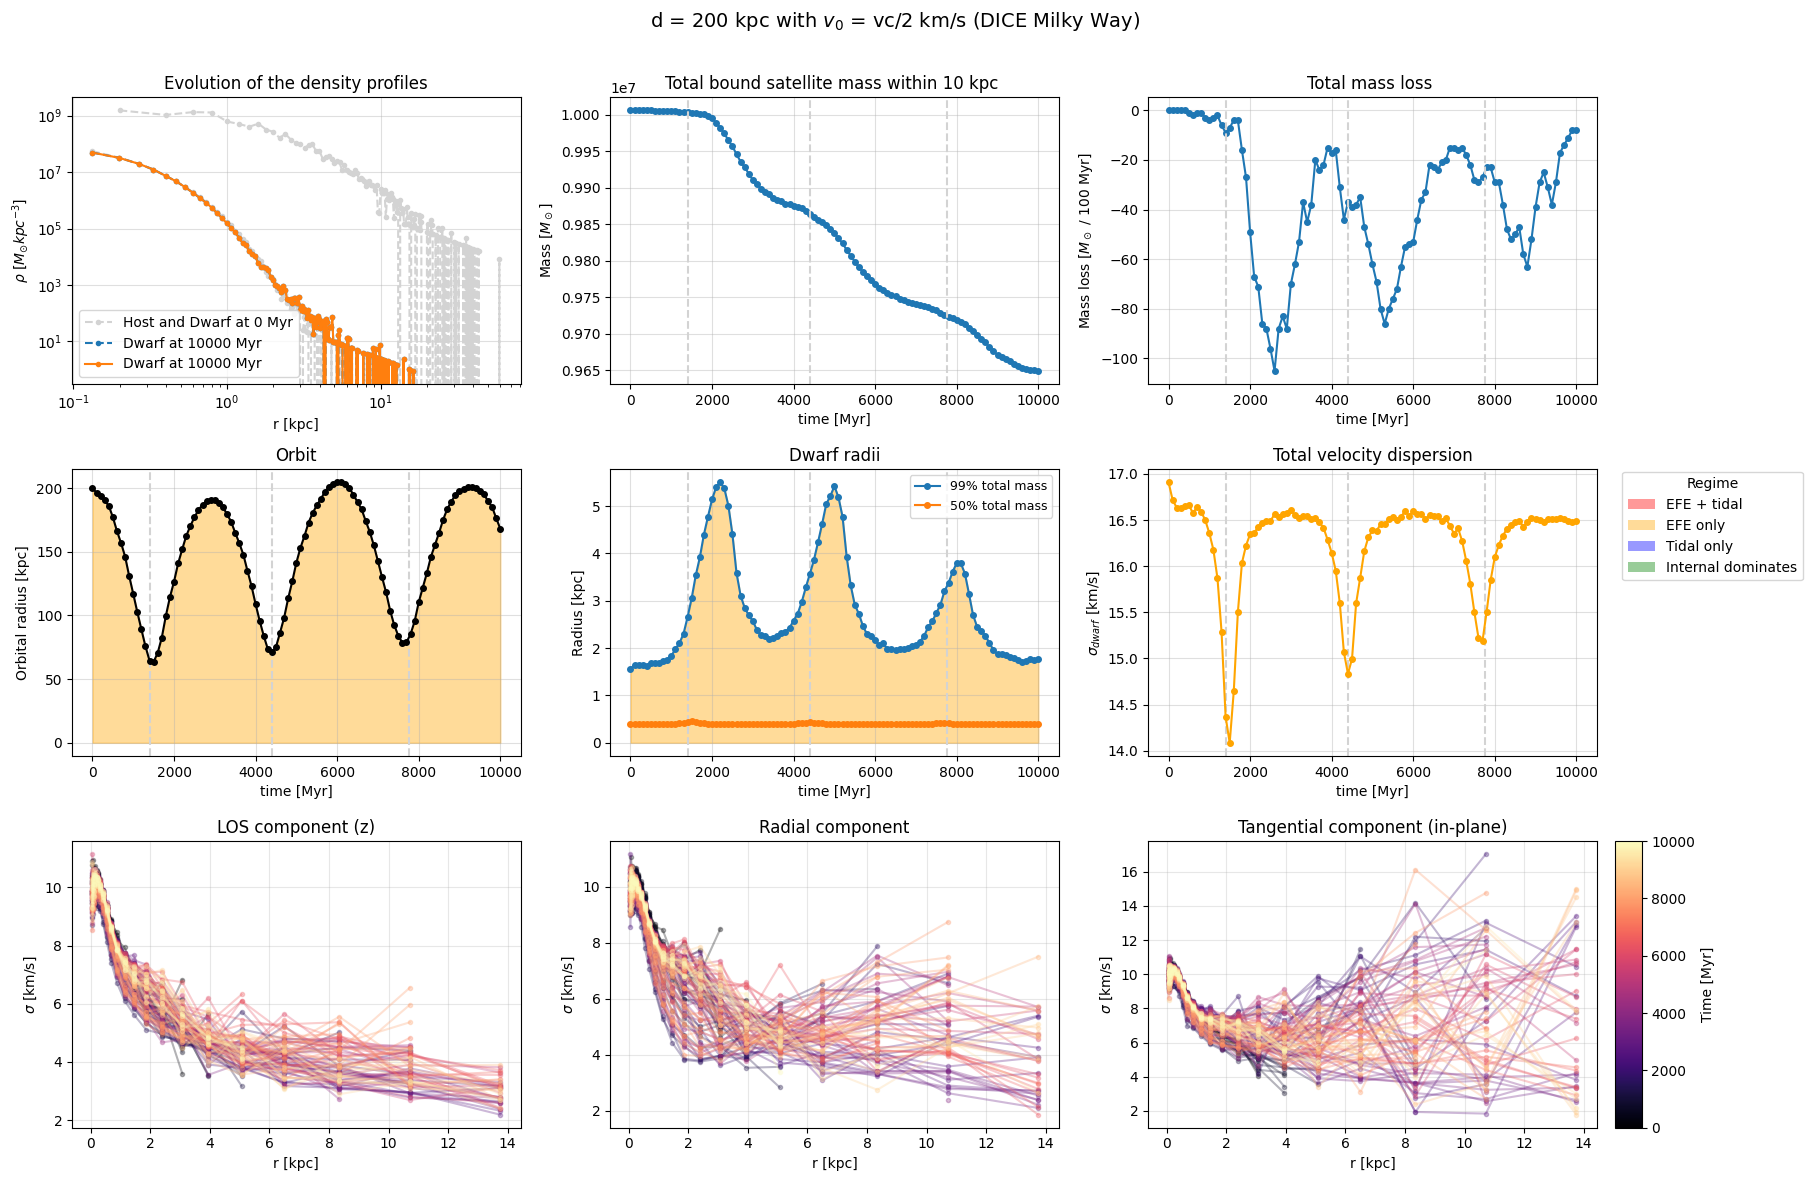

In [ ]:
t_min, r_min, tmax, rmax, e = get_perigalacticon(t_d, rs_d)
beta_mask  = np.array(betas_d)  < 1
alpha_mask = np.array(alphas_d) < 1
masses_arr = np.array(masses_sat_d, dtype=float)
t_arr      = np.array(t_d, dtype=float)
dM         = np.gradient(masses_arr, t_arr)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

axes[0,0].loglog(bins_host_d[0], rhos_host_d[0], ms=3, marker='o',c = "lightgrey", ls = "dashed", label=f"Host and Dwarf at {t_d[0]} Myr")
axes[0,0].loglog(bins_sat_d[0], rhos_sat_d[0],  ms=3, marker='o', c = "lightgrey", ls = "dashed")
axes[0,0].loglog(bins_sat_d[-1], rhos_sat_d[-1],   ms=3, marker='o', ls = "dashed", label=f"Dwarf at {t_d[-1]} Myr")
axes[0,0].set_ylabel("$\\rho$ [$M_{\\odot} kpc^{-3}$]")
axes[0,0].loglog(bins_sat_d[-1], rhos_sat_d[-1], ms=3, marker='o',label=f"Dwarf at {t_d[-1]} Myr")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.4)
axes[0,0].set_xlabel("r [kpc]")
axes[0,0].set_title(f"Evolution of the density profiles")

axes[0,1].plot(t_arr, masses_arr, ms=4, marker='o')
axes[0,1].set_xlabel("time [Myr]")
axes[0,1].set_ylabel(r"Mass [$M_\odot$]")
axes[0,1].grid(True, alpha=0.4)
axes[0,1].set_title(f"Total bound satellite mass within 10 kpc ")

axes[0,2].plot(t_arr, dM, ms=4, marker='o')
axes[0,2].set_ylabel(r"Mass loss [$M_\odot$ / 100 Myr]")
axes[0,2].set_xlabel("time [Myr]")
axes[0,2].grid(True, alpha=0.4)
axes[0,2].set_title(f"Total mass loss ")

for t_v in t_min:
    axes[0,1].axvline(t_v, color="lightgrey", ls="dashed")
    axes[0,2].axvline(t_v, color="lightgrey", ls="dashed")
    axes[1,1].axvline(t_v, color = "lightgrey", ls = "dashed")
    axes[1,2].axvline(t_v, color = "lightgrey", ls = "dashed")
    axes[1,0].axvline(t_v, color = "lightgrey", ls = "dashed")
    
axes[1,2].plot(t_d, sigmas_d, c="orange",   ms=4, marker='o')
axes[1,2].set_ylabel("$\\sigma_{dwarf}$ [km/s]")
axes[1,2].set_xlabel("time [Myr]")
axes[1,2].set_title(f"Total velocity dispersion")
axes[1,2].grid(True, alpha=0.4)

axes[1,0].plot(t_d, rs_d, c="k", marker = "o",  ms=4)
axes[1,0].set_ylabel("Orbital radius [kpc]")
axes[1,0].set_xlabel("time [Myr]")
axes[1,0].set_title(f"Orbit")
axes[1,0].fill_between(t_d, 0, rs_d, where=~beta_mask & alpha_mask, color="blue",   alpha=0.4, label="Tidal only")
axes[1,0].fill_between(t_d, 0, rs_d, where=~beta_mask & ~alpha_mask, color="green",   alpha=0.4, label="Internal dominates")
axes[1,0].fill_between(t_d, 0, rs_d, where=beta_mask & alpha_mask,  color="red",    alpha=0.4, label="EFE + tidal")
axes[1,0].fill_between(t_d, 0, rs_d, where=beta_mask &~alpha_mask, color="orange", alpha=0.4, label="EFE only")
axes[1,0].grid(True, alpha=0.4)
axes[1,0].legend()

axes[1,1].plot(t_d, lag_sat_d, marker = "o",  ms=4)
axes[1,1].plot(t_d, hmr_sat_d, marker = "o",  ms=4)
axes[1,1].set_ylabel("Radius [kpc]")
axes[1,1].set_xlabel("time [Myr]")
axes[1,1].set_title(f"Dwarf radii")
axes[1,1].grid(True, alpha=0.4)
axes[1,1].fill_between(t_d, 0, lag_sat_d, where=beta_mask & alpha_mask,  color="red",    alpha=0.4, label="EFE + tidal")
axes[1,1].fill_between(t_d, 0, lag_sat_d, where=beta_mask & ~alpha_mask, color="orange", alpha=0.4, label="EFE only")
axes[1,1].fill_between(t_d, 0, lag_sat_d, where=~beta_mask & alpha_mask, color="blue",   alpha=0.4, label="Tidal only")
axes[1,1].fill_between(t_d, 0, lag_sat_d, where=~beta_mask & ~alpha_mask, color="green",   alpha=0.4, label="Internal dominates")
axes[1,1].legend(handles=[
    plt.Line2D([0], [0], marker='o', ms=4, label='99% total mass',
               color=axes[1,1].lines[3].get_color()),
    plt.Line2D([0], [0], marker='o', ms=4, label='50% total mass',
               color=axes[1,1].lines[4].get_color()),
], loc='upper right', fontsize=9)

# Remove legends from individual axes
axes[1,0].get_legend().remove()

# Create shared legend for row 2 (fill_between)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red',    alpha=0.4, label='EFE + tidal'),
    Patch(facecolor='orange', alpha=0.4, label='EFE only'),
    Patch(facecolor='blue',   alpha=0.4, label='Tidal only'),
    Patch(facecolor='green',  alpha=0.4, label='Internal dominates'),
]

# Place legend to the right of row 2
# Get position of axes[1,2] to anchor legend next to it
fig.legend(handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(0.9, 0.55),  # right of middle row
           fontsize=10,
           title='Regime',
           framealpha=0.8)


norm     = mcolors.Normalize(vmin=t_arr.min(), vmax=t_arr.max())
cmap     = cm.magma
n_times  = len(all_sigmas_bin_d)

for i in range(n_times):
    if all_sigmas_bin_d[i] is None:
        continue
    color = cmap(norm(t_arr[i]))
    axes[2,0].plot(r_centers_d, all_sigmas_bin_d[i]["los"],
                 alpha=0.3, ms=3, marker='o', color=color)
    axes[2,1].plot(r_centers_d, all_sigmas_bin_d[i]["r"],
                 alpha=0.3, ms=3, marker='o', color=color)
    axes[2,2].plot(r_centers_d, all_sigmas_bin_d[i]["t1"], alpha=0.3, ms=3, marker='o', color=color)
    #axes[2,2].plot(r_centers, all_sigmas_bin[i]["t2"], alpha=0.3, ms=3, marker='o', color=color)

# Titles and labels
titles = ["LOS component (z)", "Radial component", "Tangential component (in-plane)"]
for ax, title in zip(axes[2,:], titles):
    ax.set_ylabel(r"$\sigma$ [km/s]")
    ax.set_xlabel("r [kpc]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"d = {x0} kpc with $v_0$ = {vy} km/s (DICE Milky Way)", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.90, 0.97])  # leave right margin for legend+colorbar
# Get positions AFTER tight_layout
pos_left  = axes[2, 0].get_position()
pos_right = axes[2, 2].get_position()

bottom = pos_left.y0        # exact bottom of row 3
height = pos_left.height    # exact height of row 3
left   = pos_right.x1 + 0.01  # just to the right of last plot

cbar_ax = fig.add_axes([left, bottom, 0.015, height])
sm      = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar    = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Time [Myr]")

plt.show()

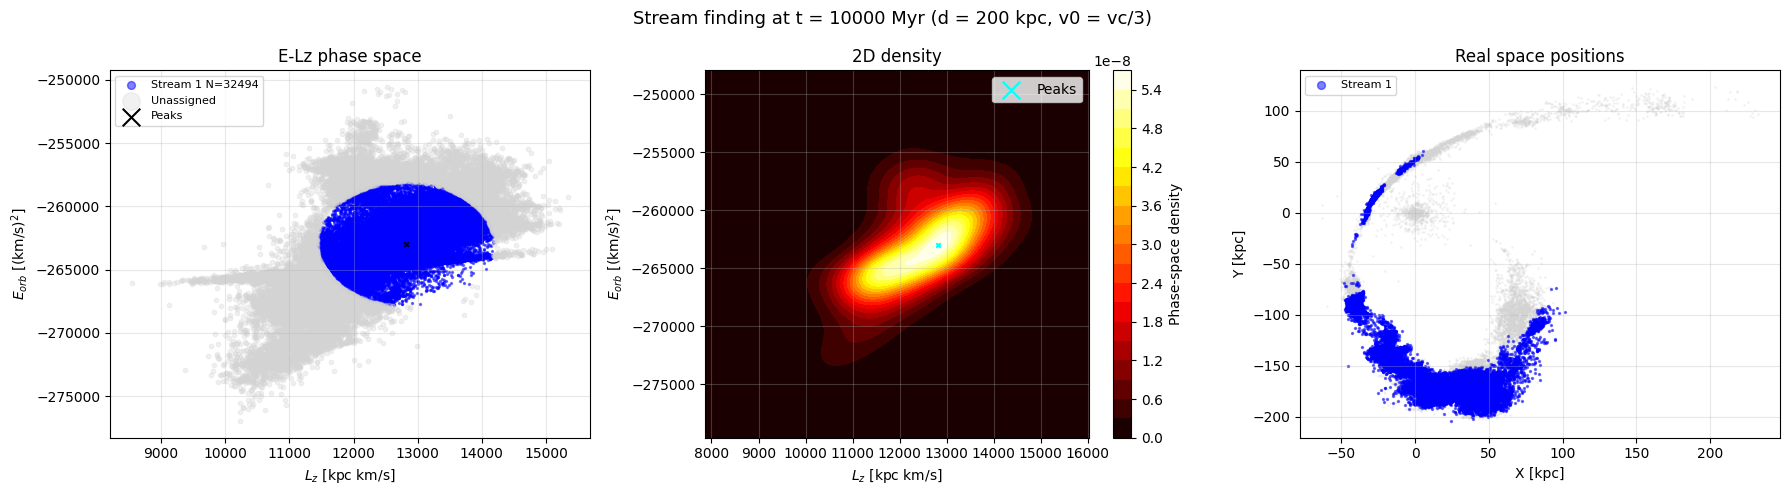

In [ ]:
i = -1

N_host = 1000 
mask_ids = np.isin(np.arange(len(all_pos_r[i])), np.arange(N_host, len(all_pos_r[i])))

sat_indices = np.where(mask_ids)[0]

pos_i    = all_pos_r[i]
vel_i    = all_vel_r[i]
mass_i   = all_mass_r[i]

L, L_mag, Lz, E_orb = get_angular_momentum(
    pos_i[mask_ids],
    vel_i[mask_ids],
    mass_i[mask_ids],
    host_potential(pos_i[mask_ids], masses_host_r[i])
)


peak_lz_values, peak_e_values, peak_densities, masks, Lz_grid, E_grid, density_smooth = find_streams(Lz, E_orb,min_height=0.03,min_distance=15)

colors = ['blue', 'red', 'green', 'orange', 'purple']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
unassigned = np.ones(len(Lz), dtype=bool)

for k, mask in enumerate(masks):
    axes[0].scatter(Lz[mask], E_orb[mask],
                    s=2, c=colors[k % len(colors)],
                    alpha=0.5, label=f'Stream {k+1} N={mask.sum()}')
    unassigned &= ~mask

axes[0].scatter(Lz[unassigned], E_orb[unassigned],
                s=10, c='lightgray', alpha=0.3, label='Unassigned')
axes[0].scatter(peak_lz_values, peak_e_values,
                s=10, marker='x', c='black', zorder=5, label='Peaks')
axes[0].set_xlabel(r"$L_z$ [kpc km/s]")
axes[0].set_ylabel(r"$E_{orb}$ [(km/s)$^2$]")
axes[0].set_title("E-Lz phase space")
axes[0].legend(markerscale=4, fontsize=8)
axes[0].grid(True, alpha=0.3)


im = axes[1].contourf(Lz_grid, E_grid, density_smooth, levels=20, cmap='hot')
axes[1].scatter(peak_lz_values, peak_e_values,
                s=10, marker='x', c='cyan', zorder=5, label='Peaks')
plt.colorbar(im, ax=axes[1], label='Phase-space density')
axes[1].set_xlabel(r"$L_z$ [kpc km/s]")
axes[1].set_ylabel(r"$E_{orb}$ [(km/s)$^2$]")
axes[1].set_title("2D density")
axes[1].legend(markerscale=4)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(pos_i[:, 0], pos_i[:, 1], s=1, c='lightgray', alpha=0.2)
for k, mask in enumerate(masks):
    global_idx = sat_indices[mask]   # now correctly maps back to full array
    axes[2].scatter(pos_i[global_idx, 0], pos_i[global_idx, 1],
                    s=2, c=colors[k % len(colors)], alpha=0.5,
                    label=f'Stream {k+1}')
axes[2].set_xlabel("X [kpc]")
axes[2].set_ylabel("Y [kpc]")
axes[2].set_title("Real space positions")
axes[2].legend(markerscale=4, fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Stream finding at t = {t_r[i]:.0f} Myr (d = 200 kpc, v0 = vc/3) ", fontsize=13)
plt.tight_layout()
plt.savefig("streamfinding.pdf", dpi=300)
plt.show()

adjust parameters!!!

In [ ]:
def get_phi_box(output):
    x = output[:,0] #grid-cell centers
    y = output[:,1]
    z = output[:,2]
    r_grid = np.sqrt(x**2 + y**2 + z**2)
    edge_idx = np.argmax(r_grid) #potential at maximal distance from center
    return output[:,4][edge_idx], output[:,9][edge_idx]

In [ ]:
def get_all(file, i):
    os.chdir(file)
    output = Pympor.chargement_grav(i, 1)  # Pot. loading 
    
    if output is None or len(output) == 0:
        print(f"WARNING: returned empty grid data")
        return None
    
    parts, time = Pympor.chargement_part(i)
    parts = parts[parts[:,6] > 0] 
    x_p = parts[:,0]
    y_p = parts[:,1]
    z_p = parts[:,2]
    
    x = output[:,0]
    y = output[:,1]
    z = output[:,2]
    
    phi_mond   = output[:,4]
    phi_newton = output[:,9]
    
    accx = output[:,5]
    accy = output[:,6]
    accz = output[:,7]
    
    # Zero each potential at the box edge separately
    phi_mond_edge   = get_phi_box(output)[0]  
    phi_newton_edge = get_phi_box(output)[1]  
    
    phi_mond_corrected   = phi_mond   - phi_mond_edge
    phi_newton_corrected = phi_newton - phi_newton_edge
    print(phi_mond_corrected.min()/ 1e6, phi_mond_corrected.max()/ 1e6)
    print(phi_newton_corrected.min()/ 1e6, phi_newton_corrected.max()/ 1e6)
    
    # Total potential (both corrected to be 0 at box edge)
    phi_total = phi_mond_corrected + phi_newton_corrected
    print(phi_total.min()/ 1e6, phi_total.max()/ 1e6)

    grid_points = np.column_stack([x, y, z])
    tree = cKDTree(grid_points)
    
    particle_points = np.column_stack([x_p, y_p, z_p])
    dist, idx = tree.query(particle_points, k=1)
    phi_particles = phi_total[idx]
    
    ax_p = accx[idx]
    ay_p = accy[idx]
    az_p = accz[idx]
    
    sat_pos = parts[1000:, :3]
    m_sat = parts[1000:, 6].flatten()
    v_sat = parts[1000:, 3:6]
    sat_com_pos = np.average(sat_pos, weights=m_sat, axis=0)
    
    v0 = np.average(v_sat, weights=m_sat, axis=0)
    v = v_sat - v0
    v2 = np.sum(v**2, axis=1)
    KE = 0.5 * v2  # (km/s)²
    
    PE = phi_particles[1000:] / 1e6  # already corrected, convert to (km/s)²
    E_total = KE + PE
    bound = E_total < 0
    
    print(f"phi_mond_edge: {phi_mond_edge/1e6:.4f} (km/s)²")
    print(f"phi_newton_edge: {phi_newton_edge/1e6:.4f} (km/s)²")
    print(f"Bound particles: {bound.sum()} / {len(bound)}")
    print(f"KE range (km/s)²: {KE.min():.2f} {KE.max():.2f}")
    print(f"PE range (km/s)²: {PE.min():.2f} {PE.max():.2f}")
    
    return sat_com_pos, x_p, y_p, z_p, ax_p, ay_p, az_p, bound

In [ ]:
from scipy.integrate import cumulative_trapezoid
from scipy.spatial import cKDTree

def get_bound_acceleration(sat_pos, v_sat, m_sat, grid_pos, accx, accy, accz, tol=0.01, max_iter=20):
    """
    Determine bound satellite particles using the acceleration field from Pympor.
    
    sat_pos: (N,3) satellite particle positions (kpc)
    v_sat:   (N,3) satellite particle velocities (km/s)
    m_sat:   (N,)  satellite particle masses
    grid_pos: (M,3) AMR grid cell centres (kpc)
    accx,accy,accz: (M,) acceleration components at grid cells (m/s²)
    r_tidal: outer radius (kpc) where escape energy -> 0
    """
    mask = np.ones(len(sat_pos), dtype=bool)
    kpc_to_m = 3.086e19
    
    for iteration in range(max_iter):
        n_prev = mask.sum()
        
        com_pos = np.average(sat_pos[mask], weights=m_sat[mask], axis=0)
        r = np.sqrt(com_pos[0]**2 + com_pos[1]**2+ com_pos[2]**2)
        com_vel = np.average(v_sat[mask], weights=m_sat[mask], axis=0)

        # KE relative to satellite bulk motion
        v_rel = v_sat - com_vel
        v2 = np.sum(v_rel**2, axis=1)
        KE = 0.5 * v2  # (km/s)²
        
        r_from_com = np.linalg.norm(sat_pos - com_pos, axis=1)

        r_tidal, _ = tidal_radius_mond(R_kpc=r, M_sat=np.sum(m_sat), M_host=8.4e10)

        # Radial direction from CoM to each grid cell
        gx = grid_pos[:,0] - com_pos[0]
        gy = grid_pos[:,1] - com_pos[1]
        gz = grid_pos[:,2] - com_pos[2]
        r_grid = np.sqrt(gx**2 + gy**2 + gz**2)
        r_grid[r_grid == 0] = 1e-10
        rhx, rhy, rhz = gx/r_grid, gy/r_grid, gz/r_grid
        
        # Inward radial acceleration (positive = pulling toward CoM)
        g_radial = -(accx*rhx + accy*rhy + accz*rhz)
        
        # Bin radially and average
        bins = np.linspace(0, r_tidal, 60)
        bin_centers = 0.5*(bins[:-1] + bins[1:])
        g_profile = np.full(len(bin_centers), np.nan)
        for k in range(len(bin_centers)):
            m = (r_grid >= bins[k]) & (r_grid < bins[k+1])
            if m.sum() > 0:
                g_profile[k] = g_radial[m].mean()
        
        valid = ~np.isnan(g_profile)
        if valid.sum() < 2:
            break  # not enough grid coverage
        
        integ = cumulative_trapezoid(g_profile[valid], bin_centers[valid], initial=0)
        escape_remaining = integ[-1] - integ  # work left to reach r_tidal, in m/s² * kpc
        
        escape_energy = np.interp(r_from_com, bin_centers[valid], escape_remaining) * kpc_to_m / 1e6  # (km/s)²
        
        mask = KE < escape_energy
        n_new = mask.sum()
        
        if abs(n_new - n_prev) / max(n_prev, 1) < tol:
            break
    return mask, com_pos, com_vel

file = "/Users/olgahinke/Desktop/simus/dice_mw/d_200/new_0.3"
os.chdir(file)

com = []
t = []
ts = 0
for i in range(69):   
# --- Usage with your Pympor output ---
    output = Pympor.chargement_grav(i, 1)  # MOND case
    x, y, z = output[:,0], output[:,1], output[:,2]
    accx, accy, accz = output[:,5], output[:,6], output[:,7]
    grid_pos = np.column_stack([x, y, z])

    parts, time = Pympor.chargement_part(i)
    parts = parts[parts[:,6] > 0]

    sat_pos = parts[6000:, 0:3]
    v_sat   = parts[6000:, 3:6]
    m_sat   = parts[6000:, 6]

    bound_mask, com_pos, com_vel = get_bound_acceleration(sat_pos, v_sat, m_sat, grid_pos, accx, accy, accz)
    r = np.sqrt(com_pos[0]**2 + com_pos[1]**2+ com_pos[2]**2)
    com.append(r)

    print(f"Bound: {bound_mask.sum()} / {len(bound_mask)}")
    print(f"CoM: {com_pos}, v0: {com_vel}")
    t.append(ts)
    ts += 100
    del output
    import gc
    gc.collect()

plt.plot(ts, r)

: 

In [ ]:
com, x,y, z, ax, ay, az, bound = get_all("/Users/olgahinke/Desktop/simus/high_res/d_200_vc_0.3", 2)

Raw data shape loaded: (50000000, 13)
Unique ilevels found (col 8): [ 0.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.]
Count of ilevels > 0: 2811572
Count of ilevels <= 0: 47188428
Filtered data shape: (2811572, 13)
File : output_00002
part file read
-167.64228358699344 0.00121154800593853
-70.09861665074172 6.967032079293858e-06
-237.74090023773516 0.0012185150380178238
phi_mond_edge: 136.3255 (km/s)²
phi_newton_edge: -0.1052 (km/s)²
Bound particles: 7997 / 50000
KE range (km/s)²: 0.06 981.82
PE range (km/s)²: -41.67 -40.11


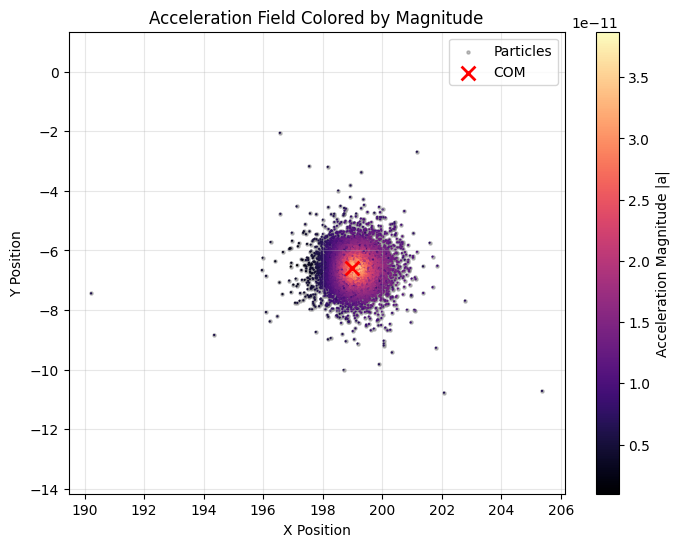

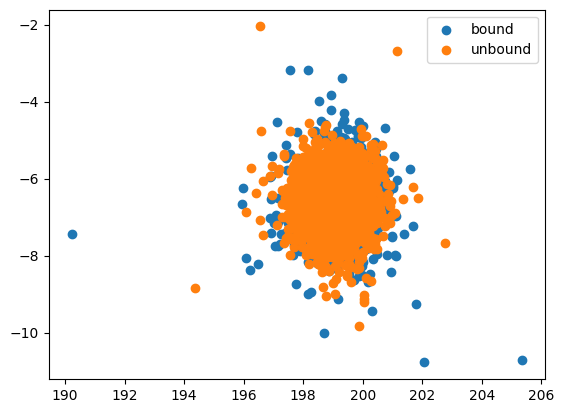

In [ ]:
x = x[1000:]
y = y[1000:]
z = z[1000:]
ax = ax[1000:]
ay = ay[1000:]
az = az[1000:]

total = np.sqrt(ax**2 + ay**2 + az**2)

# Create the figure
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=5, alpha=0.5, c='gray', label='Particles') 
q = plt.quiver(x, y, ax, ay, total, cmap='magma', scale=50, width=0.005)

plt.scatter(com[0], com[1], marker="x", s=100, c="red", linewidths=2, label="COM")

cbar = plt.colorbar(q, label='Acceleration Magnitude |a|')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Acceleration Field Colored by Magnitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal') # Keep aspect ratio square
plt.show()
plt.scatter(x[bound], y[bound], label="bound")
plt.scatter(x[~bound], y[~bound], label="unbound")
plt.legend()

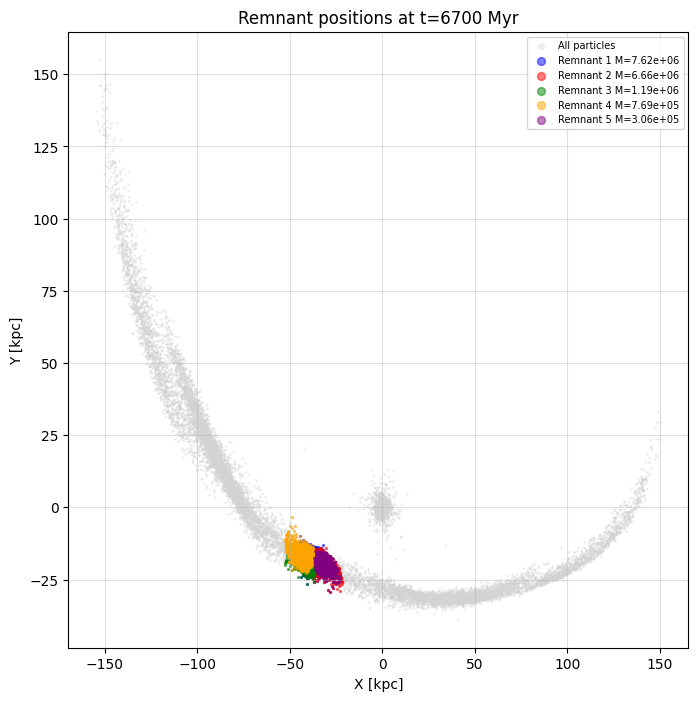

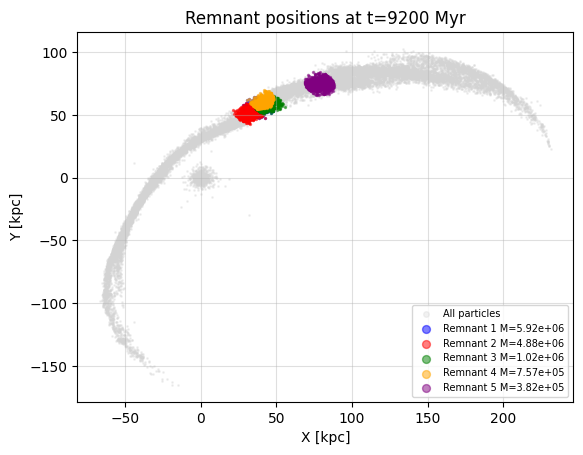

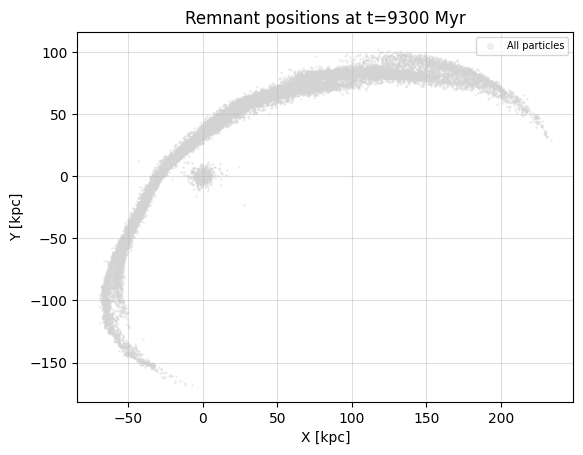

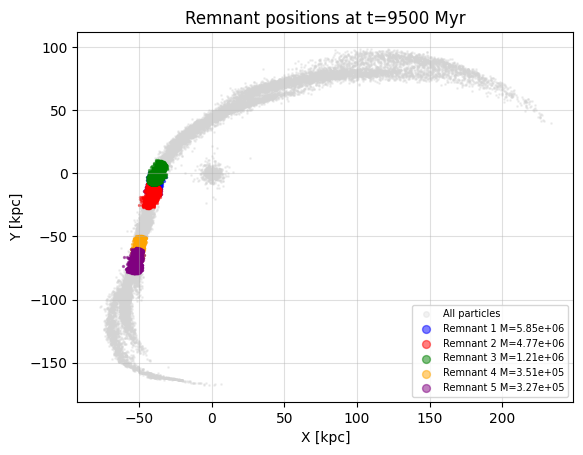

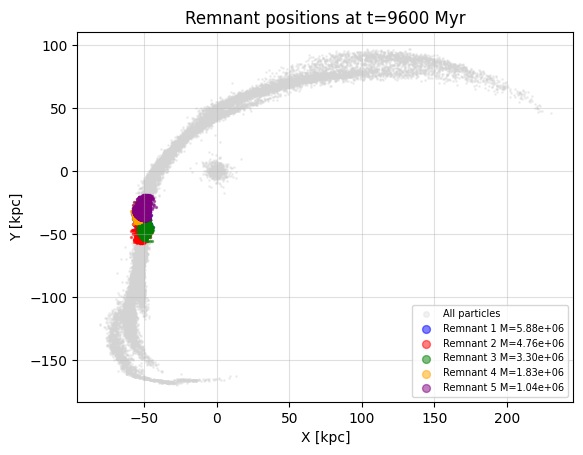

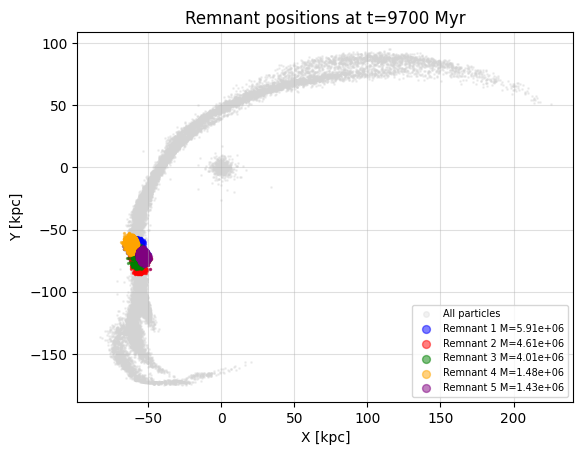

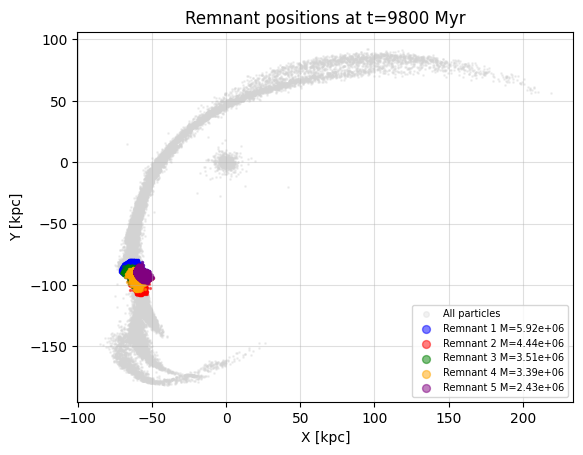

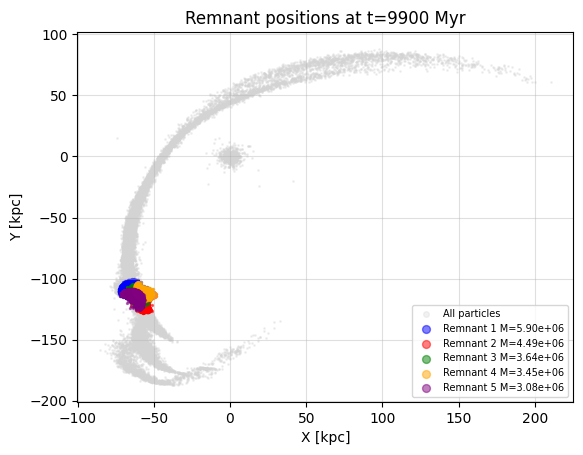

<Figure size 640x480 with 0 Axes>

In [ ]:
colors = ['blue', 'red', 'green', 'orange', 'purple']

plt.figure(figsize=(8, 8))

for i, remnant in enumerate(all_remnants):
    if remnant is None:
        continue
    plt.scatter(all_pos[i-1][:, 0], all_pos[i-1][:, 1], s=1, alpha=0.3, c='lightgray', label='All particles')
    for j, rem in enumerate(remnant):
        rem_pos = all_pos[i-1][rem["mask"]]
        plt.scatter(rem_pos[:, 0], rem_pos[:, 1], s=2, alpha=0.5, c=colors[j % len(colors)], label=f'Remnant {j+1} M={rem["mass"]:.2e}')
        #plt.scatter(rem["com_pos"][0], rem["com_pos"][1], s=100, marker='*',c=colors[j % len(colors)], zorder=5)

    plt.xlabel("X [kpc]")
    plt.ylabel("Y [kpc]")
    plt.title(f"Remnant positions at t={t[i-2]:.0f} Myr")
    plt.legend(markerscale=4, fontsize=7)
    plt.grid(True, alpha=0.4)
    plt.show()
plt.savefig("remnants.pdf", dpi=300)


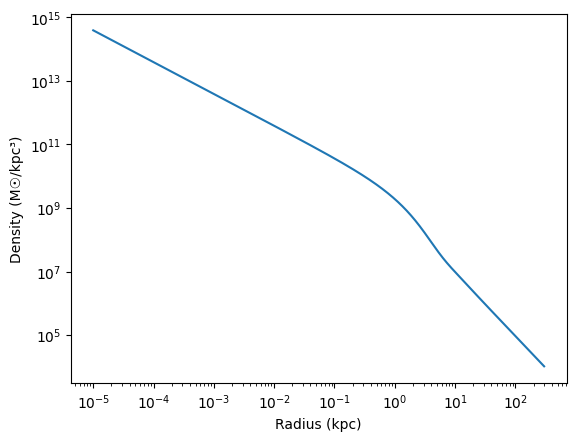

In [ ]:
d = "/Users/olgahinke/Desktop/simus/test_analytic_mw/one_part/mond_density_table.dat"
data = np.loadtxt(d)
r = data[:, 0]
rho  = data[:, 1]
plt.loglog(r, rho, label="Analytic MW density")
plt.xlabel("Radius (kpc)")
plt.ylabel("Density (M☉/kpc³)")
plt.show()

In [ ]:
def plotting_point(file, dt, tend, boxsize=500):
    coms_sat = []
    vels_sat = []
    e_orb = []
    rs = []
    times = []
    t = 0
    for i in range(1,tend - 1):
        f = f"{file}output_{i:05d}"
        s = pn.load(f)
        r = s.dm["pos"]
        r -= boxsize/2
        v = s.dm["vel"].in_units("km s^-1")
        m = s.dm["mass"]

        com = np.linalg.norm(r, axis = 1)
        com_sat = com
        r = r[0]
            
        rs.append(np.array(r))
        coms_sat.append(com_sat) 
        times.append(t)
        t +=dt

    return times, np.array(rs), np.array(coms_sat)

In [ ]:
d = "/Users/olgahinke/Desktop/simus/test_analytic_mw/one_part/"
t, r, com = plotting_point(d, 100, 59, boxsize = 1000)

Text(0.5, 1.0, 'Point mass satellite test')

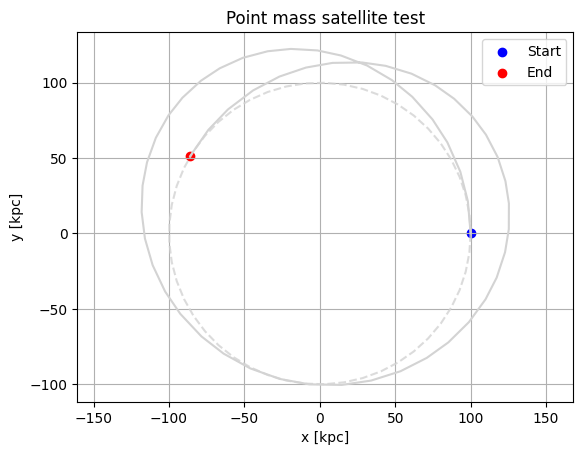

In [ ]:
r = np.array(r)
r0 = 200
phi = np.linspace(0, 2* np.pi)
x = 100 * np.cos(phi)
y = 100 * np.sin(phi)

plt.plot(r[:,0], r[:,1], c = "lightgrey")
plt.plot(x,y, c = "lightgrey", alpha = 0.8, ls = "dashed")
plt.scatter(r[0,0], r[0,1], c = "b", label="Start")
plt.scatter(r[-1,0], r[-1,1], c = "r", label="End")
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.title("Point mass satellite test")

Text(0, 0.5, 'r [kpc]')

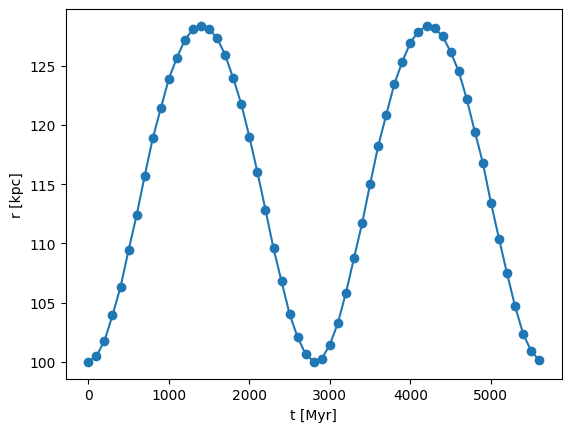

In [ ]:
plt.plot(t, com, marker = "o")
plt.xlabel("t [Myr]")
plt.ylabel("r [kpc]")